# EDA - PetFinder Adoption Prediction

Análisis exploratorio del dataset de entrenamiento de la competencia de Kaggle [PetFinder.my Adoption Prediction](https://www.kaggle.com/c/petfinder-adoption-prediction).

**Objetivo:** Comprender la estructura y distribución de los datos como punto de partida para el entrenamiento de un modelo predictivo de `AdoptionSpeed`, una variable objetivo ordinal con clases de 0 a 4, donde valores más bajos indican adopciones más rápidas.

**Estructura del análisis:**
1. Carga y limpieza inicial
2. Análisis univariado
3. Análisis bivariado (relación con el target)
4. Análisis multivariado

## 1. Carga y limpieza inicial

### Librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from wordcloud import WordCloud
from scipy import stats
from scipy.stats import chi2_contingency, kruskal
import warnings
import os

warnings.filterwarnings('ignore')

# ── Estilo global ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})
sns.set_palette('Set2')

SEED = 42
TARGET = 'AdoptionSpeed'
PALETTE = sns.color_palette('Set2', 5)

%matplotlib inline
pd.set_option('display.max_columns', 30)
pd.set_option('display.max_rows', 100)
plt.rcParams['figure.figsize'] = [12.0, 6.0]
sns.set_style('whitegrid')

### Carga de bases

In [2]:
# Path
input_path = '/kaggle/input/competitions/petfinder-adoption-prediction/'

# Leer tabla
train = pd.read_csv(os.path.join(input_path, 'train/train.csv'))

# Cargar diccionarios de etiquetas
breeds = pd.read_csv(os.path.join(input_path, 'breed_labels.csv'))
colors = pd.read_csv(os.path.join(input_path, 'color_labels.csv'))
states = pd.read_csv(os.path.join(input_path, 'state_labels.csv'))


### Diccionario de variables y mapeo de variables categóricas

| Variable | Descripción |
|---|---|
| `PetID` | ID único del perfil de la mascota |
| `AdoptionSpeed` | **Target**: velocidad de adopción (0=mismo día, 1=1ª semana, 2=1er mes, 3=2do-3er mes, 4=no adoptado en 100 días) |
| `Type` | Tipo de animal (1=Perro, 2=Gato) |
| `Name` | Nombre de la mascota |
| `Age` | Edad en meses al momento del listado |
| `Breed1` | Raza primaria |
| `Breed2` | Raza secundaria (si es mestizo) |
| `Gender` | Género (1=Macho, 2=Hembra, 3=Mixto) |
| `Color1/2/3` | Colores de la mascota |
| `MaturitySize` | Tamaño al madurar (1=Pequeño, 2=Mediano, 3=Grande, 4=Extra Grande, 0=No especificado) |
| `FurLength` | Largo del pelo (1=Corto, 2=Mediano, 3=Largo, 0=No especificado) |
| `Vaccinated` | Vacunado (1=Sí, 2=No, 3=No sabe) |
| `Dewormed` | Desparasitado (1=Sí, 2=No, 3=No sabe) |
| `Sterilized` | Esterilizado (1=Sí, 2=No, 3=No sabe) |
| `Health` | Condición de salud (1=Sano, 2=Lesión leve, 3=Lesión grave, 0=No especificado) |
| `Quantity` | Cantidad de mascotas en el perfil |
| `Fee` | Tarifa de adopción (0=gratis) |
| `State` | Estado en Malasia |
| `RescuerID` | ID único del rescatista |
| `VideoAmt` | Cantidad de videos subidos |
| `PhotoAmt` | Cantidad de fotos subidas |
| `Description` | Texto descriptivo del perfil |

In [3]:
df = train.copy()

# Mapeos según el diccionario de datos

df['GenderLabel']       = df['Gender'].map({1: 'Macho', 2: 'Hembra', 3: 'Mixto'})
df['MaturitySizeLabel'] = df['MaturitySize'].map({0: 'No especif.', 1: 'Pequeño', 2: 'Mediano', 3: 'Grande', 4: 'Extra Grande'})
df['FurLengthLabel']    = df['FurLength'].map({0: 'No especif.', 1: 'Corto', 2: 'Mediano', 3: 'Largo'})
df['VaccinatedLabel']   = df['Vaccinated'].map({1: 'Sí', 2: 'No', 3: 'No sabe'})
df['DewormedLabel']     = df['Dewormed'].map({1: 'Sí', 2: 'No', 3: 'No sabe'})
df['SterilizedLabel']   = df['Sterilized'].map({1: 'Sí', 2: 'No', 3: 'No sabe'})
df['HealthLabel']       = df['Health'].map({0: 'No especif.', 1: 'Sano', 2: 'Lesión leve', 3: 'Lesión grave'})
df['AdoptionSpeedLabel']= df['AdoptionSpeed'].map({0: 'Mismo día', 1: '1–7 días', 2: '8–30 días', 3: '31–90 días', 4: 'No adoptado'})

# Unión con labels de colores, razas y estados
color_map = colors.set_index('ColorID')['ColorName'].to_dict()
state_map = states.set_index('StateID')['StateName'].to_dict()
# Mapeo de variables con labels
df['StateName']  = df['State'].map(state_map)
df['Color1Label'] = df['Color1'].map(color_map)
df['Color2Label'] = df['Color2'].map(color_map)
df['Color3Label'] = df['Color3'].map(color_map)

df['Type'] = df['Type'].astype(int)
df['Breed1'] = df['Breed1'].astype(int)
df['Breed2'] = df['Breed2'].astype(int)

breeds['Type'] = breeds['Type'].astype(int)
breeds['BreedID'] = breeds['BreedID'].astype(int)

df = df.merge(
    breeds, 
    left_on=['Type', 'Breed1'], 
    right_on=['Type', 'BreedID'], 
    how='left'
)
df.rename(columns={'BreedName': 'Breed1Name'}, inplace=True)
df.drop(columns=['BreedID'], inplace=True)

df = df.merge(
    breeds, 
    left_on=['Type', 'Breed2'], 
    right_on=['Type', 'BreedID'], 
    how='left'
)
df.rename(columns={'BreedName': 'Breed2Name'}, inplace=True)
df.drop(columns=['BreedID'], inplace=True)

df['TypeLabel']         = df['Type'].map({1: 'Perro', 2: 'Gato'})
print('Dataset preparado.')
df.head(3)

Dataset preparado.


,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,FurLength,Vaccinated,Dewormed,Sterilized,Health,...,GenderLabel,MaturitySizeLabel,FurLengthLabel,VaccinatedLabel,DewormedLabel,SterilizedLabel,HealthLabel,AdoptionSpeedLabel,StateName,Color1Label,Color2Label,Color3Label,Breed1Name,Breed2Name,TypeLabel
0,2,Nibble,3,299,0,1,1,7,0,1,1,2,2,2,1,...,Macho,Pequeño,Corto,No,No,No,Sano,8–30 días,Selangor,Black,White,NaN,Tabby,NaN,Gato
1,2,No Name Yet,1,265,0,1,1,2,0,2,2,3,3,3,1,...,Macho,Mediano,Mediano,No sabe,No sabe,No sabe,Sano,Mismo día,Kuala Lumpur,Black,Brown,NaN,Domestic Medium Hair,NaN,Gato
2,1,Brisco,1,307,0,1,2,7,0,2,2,1,1,2,1,...,Macho,Mediano,Mediano,Sí,Sí,No,Sano,31–90 días,Selangor,Brown,White,NaN,Mixed Breed,NaN,Perro


---
## 2. Vista general del dataset

### Tipos de datos e info general

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14993 entries, 0 to 14992
Data columns (total 39 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Type                14993 non-null  int64  
 1   Name                13728 non-null  object 
 2   Age                 14993 non-null  int64  
 3   Breed1              14993 non-null  int64  
 4   Breed2              14993 non-null  int64  
 5   Gender              14993 non-null  int64  
 6   Color1              14993 non-null  int64  
 7   Color2              14993 non-null  int64  
 8   Color3              14993 non-null  int64  
 9   MaturitySize        14993 non-null  int64  
 10  FurLength           14993 non-null  int64  
 11  Vaccinated          14993 non-null  int64  
 12  Dewormed            14993 non-null  int64  
 13  Sterilized          14993 non-null  int64  
 14  Health              14993 non-null  int64  
 15  Quantity            14993 non-null  int64  
 16  Fee 

### Valores nulos

In [5]:
nulls = df.isnull().sum().sort_values(ascending=False)
nulls_pct = (nulls / len(train) * 100).round(2)
null_df = pd.DataFrame({'Nulos': nulls, 'Porcentaje (%)': nulls_pct})
null_df[null_df['Nulos'] > 0]

,Nulos,Porcentaje (%)
Breed2Name,10765,71.80
Color3Label,10604,70.73
Color2Label,4471,29.82
Name,1265,8.44
Breed1Name,17,0.11
Description,13,0.09


Se estandariza la variable Name para imputar Nulos en valores como "No Name", en valores que sólo cuentan con números, o en valores con menos de 2 caracteres.

In [6]:
# 1. Definimos el patrón de palabras prohibidas
invalid_keywords = ['adoption', 'urgent', 'none', 'unknown', 'name', 'nan', 'n/a', 'yet', 'help']
pattern_keywords = '|'.join(invalid_keywords)

# 2. Limpieza y estandarización
df['Name'] = df['Name'].astype(str).str.lower().str.strip()

# 3. Aplicamos la limpieza definitiva
df.loc[
    df['Name'].str.contains(pattern_keywords, na=False) | # Contiene palabras basura
    (df['Name'].str.len() <= 2) |                        # Solo 1 carácter (no es un nombre válido)
    df['Name'].str.match(r'^[^a-zA-Z0-9]+$') |           # Solo símbolos (ej: "???", "---")
    df['Name'].str.isnumeric() |                         # Solo números
    (df['Name'] == 'nan'),                               # El string 'nan'
    'Name'
] = np.nan

# Verificación de los que quedan para auditar
nombres_cortos = df[df['Name'].notna() & (df['Name'].str.len() < 4)]['Name'].unique()
print(f"Nombres cortos que sobrevivieron: {nombres_cortos}")
# Verificación
print(f"Nulos en la columna 'Name': {df['Name'].isna().sum()}")

Nombres cortos que sobrevivieron: ['max' 'tom' 'boy' 'zoe' 'cat' 'sam' 'mok' 'c7c' 'r11' 'tea' 'leo' 'kfc'
 'b33' 'ice' 'mia' 'iko' 'gia' 'ash' 'kid' 'rin' 'dom' 'ben' 'mio' 'c2c'
 'abe' 'lai' 'l17' 'may' 'c5c' 'liz' 'bee' 'dot' 'any' 'gin' 'got' 'ray'
 'chi' 'ali' 'min' 'ab1' 'abu' 'ace' 'zee' 'gon' 'abi' 'sel' 'cha' 'jet'
 'ted' 'blu' 'amy' 'niu' 'non' 'jay' 'bt8' 'wes' 'mou' 'aki' 'mei' 'poe'
 'uyu' 'jim' 'kin' 'lex' 's&p' 'mex' 'mac' 'rum' 'ami' 'eli' 'r12' 'tim'
 'nil' 'r10' 'gus' 'jr.' 'pup' 'eva' 'mec' 'dio' 'joy' 'rio' 'joe' 'mog'
 'ori' 'jil' 'ino' 'ab2' 'hua' 'tam' 'c3c' 'boo' 'opi' 'don' 'bt3' 'bt6'
 'f10' 'soy' 'mel' 'roy' 'gem' 'acu' 'ito' 'yen' 'bon' 'red' 'bt5' 'ana'
 'c6c' 'dog' 'moo' 'bt1' 'pot' 'rex' 'c14' 'sky' 'one' 'jam' 'reo' '1kg'
 'mii' 'den' 'fye' 'roo' 'lix' 'bin' 'lux' 'mah' 'boh' 'tia' 'bw3' 'f11'
 'ken' 'mix' 'nix' 'sim' 'ole' 'evy' 'qts' 'ibu' 'mas' 'ore' '!tq' 'pip'
 'lay' 'sox' 'a-g' 'rox' 'emo' 'mew' 'b22' 'c4c' 'bt4' 'ewa' 'pom' 'a88'
 'cap' 'c1c' 'ena

Se estandariza la variable Description para identificar mejor descripciones que no tienen valor: descripciones que incluyen frases genéricas como "Please adopt" o "For adoption", y que tienen un largo menor a 40 caracteres.

In [7]:
# Definimos frases genéricas
generic_phrases = [
    'adoption', 'to be adopted', 'looking for a home', 
    'please', 'available', 'urgent'
]

# Creamos un filtro
# 1. Pasamos a minúsculas para comparar
# 2. Buscamos si alguna frase está en la descripción
# 3. Agregamos una condición de longitud (opcional, para ver las más sospechosas)

mask_keyword = df['Description'].str.lower().str.contains('|'.join(generic_phrases), na=False)
mask_short = df['Description'].str.len() < 40

# Aplicamos la limpieza: si la descripción es corta y contiene la frase, va a NaN
df.loc[mask_keyword & mask_short, 'Description'] = np.nan

# También es buena idea limpiar las que quedaron solo con espacios o puntos
df['Description'] = df['Description'].str.strip()
df.loc[df['Description'].str.len() < 5, 'Description'] = np.nan

print(f"Nulos finales en Description: {df['Description'].isna().sum()}")

Nulos finales en Description: 493


### Duplicados

In [8]:
n_dup = df.duplicated().sum()
print(f'Filas duplicadas: {n_dup}')
print(f'PetIDs únicos:    {df["PetID"].nunique()}')

Filas duplicadas: 0
PetIDs únicos:    14993


Se encuentran 8 registros duplicados en todas las variables excepto PetID.
Se eliminan duplicados. 

In [9]:
cols_to_exclude = ['PetID']

n_dup_features = df.drop(columns=cols_to_exclude).duplicated().sum()

print(f'Filas con features idénticas (ignorando PetID): {n_dup_features}')

dups_df = df[df.drop(columns=cols_to_exclude).duplicated(keep=False)].sort_values(by='Description')

Filas con features idénticas (ignorando PetID): 43


In [10]:
# Defino las columnas a comparar
cols_to_compare = df.columns.difference(['PetID'])
# Ordeno dataset por ID, luego elimino duplicados
df = df.sort_values(by='PetID').drop_duplicates(subset=cols_to_compare, keep='first')

### Generación de variables

Luego de la limpieza, se generan algunas variables derivadas.

In [11]:
df['HasName'] = (df['Name'].notna() & (df['Name'].str.strip() != '')).astype(int)
df['HasDesc'] = (df['Description'].notna() & (df['Description'].str.strip() != '')).astype(int)
df['MixedColor'] = ((df['Color2'] != 0) & (df['Color2'].notna())).astype(int)
df['HasPhoto'] = (df['PhotoAmt'].fillna(0) > 0).astype(int)
df['HasVideo'] = (df['VideoAmt'].fillna(0) > 0).astype(int)
df['IsFree'] = (df['Fee'] == 0).astype(int)
df['MixedBreed'] = (
    ((df['Breed2Name'].notna()) & (df['Breed1'] != df['Breed2'])) | 
    (df['Breed1Name'] == 'Mixed Breed')
).astype(int)
df['IsGroup'] = (df['Quantity'] > 1).astype(int)

df['NameLength'] = df['Name'].str.len().fillna(0)
df['DescLength'] = df['Description'].str.len().fillna(0)
df['DescWordCount'] = df['Description'].fillna('').str.split().str.len()
df['RescuerFrequency'] = df.groupby('RescuerID')['PetID'].transform('count')

# Grupos de Age para análisis categórico
age_bins   = [-1, 2, 6, 12, 24, 60, 9999]
age_labels = ['0–2m', '3–6m', '7–12m', '13–24m', '25–60m', '60m+']
df['AgeGroup'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels)

# Grupos de PhotoAmt
df['PhotoGroup'] = pd.cut(df['PhotoAmt'].fillna(0),
                           bins=[-1, 0, 2, 5, 100],
                           labels=['0 fotos', '1–2 fotos', '3–5 fotos', '6+ fotos'])

# Grupos de Fee
df['FeeGroup'] = pd.cut(df['Fee'],
                         bins=[-1, 0, 50, 100, 200, df['Fee'].max()],
                         labels=['Gratis', '1–50', '51–100', '101–200', '200+'])

# Adopción rápida (flag binaria para análisis)
df['AdoptFast'] = df['AdoptionSpeed'].isin([0, 1]).astype(int)

print('Variables derivadas creadas:')
new_vars = ['HasName','HasDesc','MixedColor','HasPhoto','HasVideo','IsFree',
            'MixedBreed','IsGroup','NameLength','DescLength','DescWordCount',
            'RescuerFrequency','AgeGroup','PhotoGroup','FeeGroup','AdoptFast']
for v in new_vars:
    print(f'  {v}: {df[v].dtype}')


Variables derivadas creadas:
  HasName: int64
  HasDesc: int64
  MixedColor: int64
  HasPhoto: int64
  HasVideo: int64
  IsFree: int64
  MixedBreed: int64
  IsGroup: int64
  NameLength: float64
  DescLength: float64
  DescWordCount: int64
  RescuerFrequency: int64
  AgeGroup: category
  PhotoGroup: category
  FeeGroup: category
  AdoptFast: int64


También se traen algunas variables externas relacionadas con los Estados.
Se analizará el valor que puedan aportar variables como :
- Población (en miles). Publicado en https://open.dosm.gov.my/data-catalogue/population_state
- Pobreza absoluta (en %). Publicado en https://open.dosm.gov.my/dashboard/household-income-expenditure
- Ingreso Promedio Mensual (en RM). Publicado en https://open.dosm.gov.my/dashboard/household-income-expenditure

In [12]:
state_pop_map = {
    41336 : 9484,
41325 : 5793,
41367 : 5265,
41401 : 13985,
41415 : 8555,
41324 : 8686,
41332 : 7305,
41335 : 6066,
41330 : 6173,
41380 : 5996,
41327 : 9152,
41345 : 6498,
41342 : 6947,
41326 : 13296,
41361 : 7627
}

# Mapeo de Pobreza Absoluta por Estado (%)
poverty_map = {
    41336 : 0.025,
41325 : 0.084,
41367 : 0.115,
41401 : 0.01,
41415 : 0.02,
41324 : 0.03,
41332 : 0.04,
41335 : 0.059,
41330 : 0.069,
41380 : 0.036,
41327 : 0.019,
41345 : 0.177,
41342 : 0.084,
41326 : 0.009,
41361 : 0.048
}

# Mapeo de Ingreso Promedio Mensual (MYR)
income_map = {
    41336 : 4206,
41325 : 2228,
41367 : 1908,
41401 : 2074,
41415 : 101,  # Corregido: valor original 101 era probablemente un error de tipeo
41324 : 1053,
41332 : 1245,
41335 : 1678,
41330 : 2575,
41380 : 298,  # Corregido: valor original 298 era probablemente un error de tipeo
41327 : 1803,
41345 : 3760,
41342 : 2530,
41326 : 7407,
41361 : 1247
}

df['StatePop'] = df['State'].map(state_pop_map)
df['StatePovertyPct'] = df['State'].map(poverty_map)
df['StateIncomeAvg'] = df['State'].map(income_map)
print(df[['State', 'StatePop', 'StatePovertyPct', 'StateIncomeAvg']])

       State  StatePop  StatePovertyPct  StateIncomeAvg
3057   41326     13296            0.009            7407
4839   41327      9152            0.019            1803
14218  41401     13985            0.010            2074
7933   41326     13296            0.009            7407
3722   41401     13985            0.010            2074
...      ...       ...              ...             ...
1939   41326     13296            0.009            7407
2567   41330      6173            0.069            2575
4281   41401     13985            0.010            2074
13094  41326     13296            0.009            7407
9517   41332      7305            0.040            1245

[14950 rows x 4 columns]


---
## 3. Análisis Univariado

### 3.1 Variable target: AdoptionSpeed

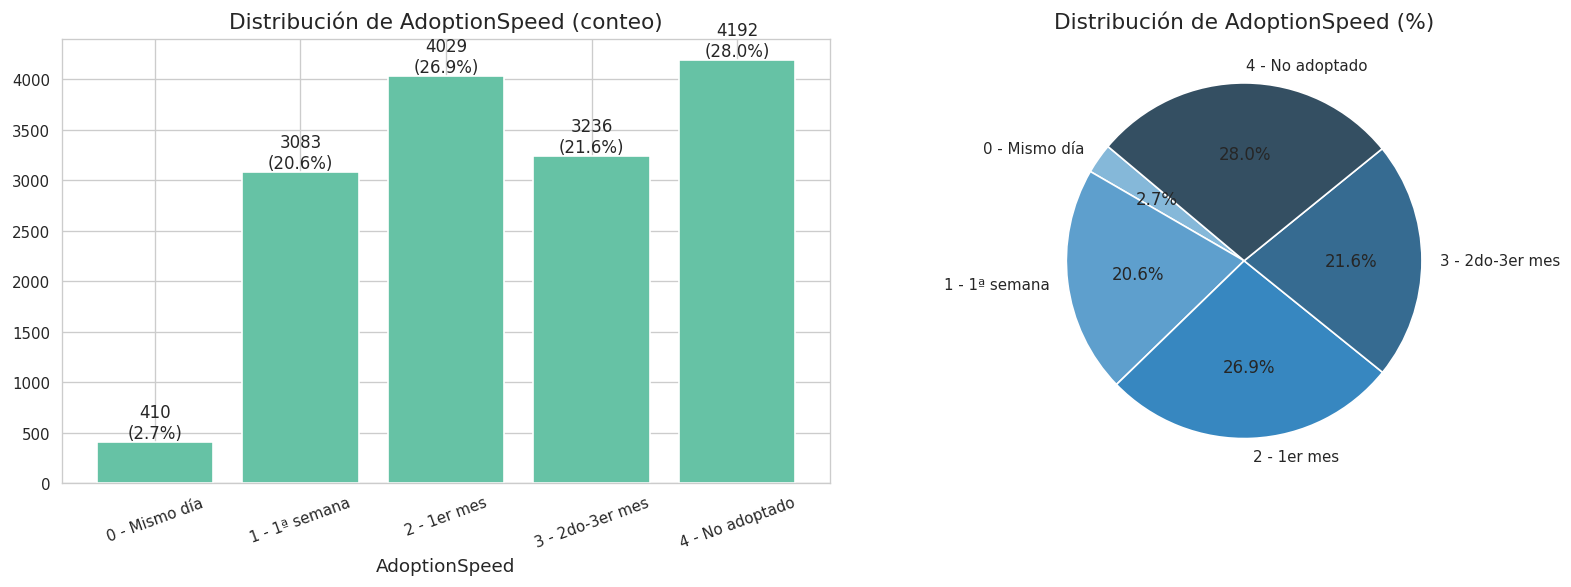

In [13]:
target_labels = {
    0: '0 - Mismo día',
    1: '1 - 1ª semana',
    2: '2 - 1er mes',
    3: '3 - 2do-3er mes',
    4: '4 - No adoptado'
}

counts = df['AdoptionSpeed'].value_counts().sort_index()
pcts   = counts / counts.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(
    [target_labels[i] for i in counts.index],
    counts.values
)

axes[0].set_title('Distribución de AdoptionSpeed (conteo)')
axes[0].set_xlabel('AdoptionSpeed')
axes[0].tick_params(axis='x', rotation=20)

for i, bar in enumerate(bars):
    height = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{counts.iloc[i]}\n({pcts.iloc[i]:.1f}%)',
        ha='center',
        va='bottom'
    )

axes[1].pie(
    pcts.values,
    labels=[target_labels[i] for i in pcts.index],
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('Blues_d', len(pcts))
)

axes[1].set_title('Distribución de AdoptionSpeed (%)')

plt.tight_layout()
plt.show()

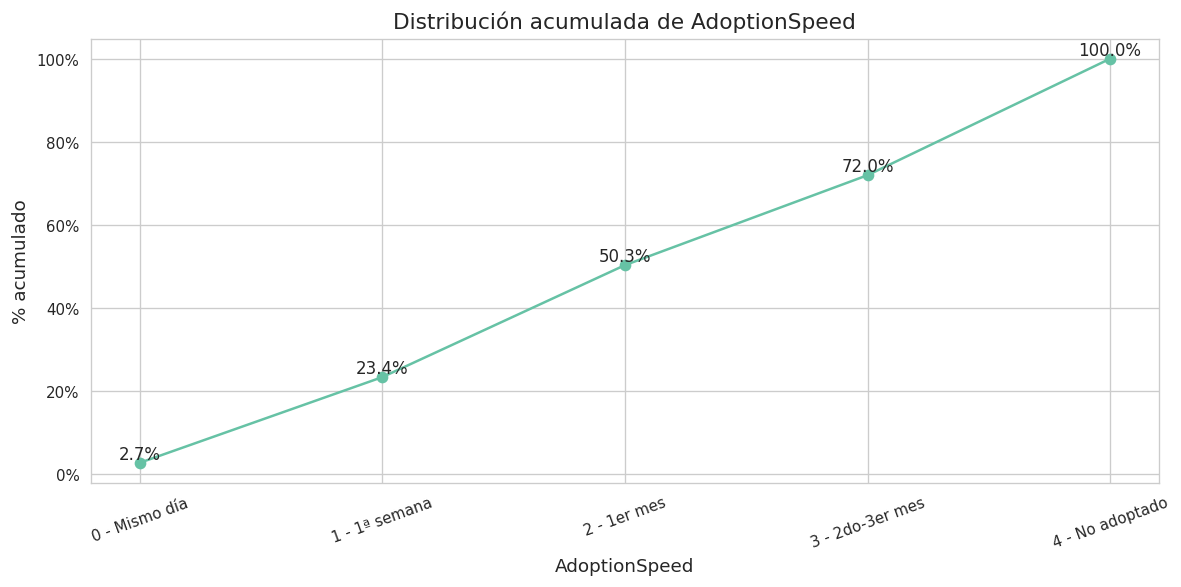

In [14]:
# Distribución acumulada
cum_pct = pcts.cumsum()

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    [target_labels[i] for i in cum_pct.index],
    cum_pct.values,
    marker="o"
)

ax.set_title("Distribución acumulada de AdoptionSpeed")
ax.set_xlabel("AdoptionSpeed")
ax.set_ylabel("% acumulado")

ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.tick_params(axis='x', rotation=20)

for i, value in enumerate(cum_pct.values):
    ax.text(
        i,
        value,
        f"{value:.1f}%",
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

La distribución de `AdoptionSpeed` muestra que las categorías más frecuentes son la 4 (28%) y la 2 (26.9%), mientras que la adopción inmediata (clase 0) es muy poco frecuente (2.7%).
El desbalance de clases determina que `accuracy` es una métrica inapropiada. La métrica adecuada es **Cohen's Kappa Cuadrático (QWK)** — penaliza errores grandes.
Sin embargo, el desbalance no es suficiente para requerir de técnicas como Oversampling/Undersampling, etc.

La distribución acumulada muestra que:
*   Aproximadamente el 50% de las mascotas se adopta dentro del primer mes (clases 0-2).
*   Cerca del 70% se adoptan dentro de los 3 meses (clases 0–3).
*   El 30% restante no se adopta en ese período (clase 4).
  

### 3.2 Tipo de animal

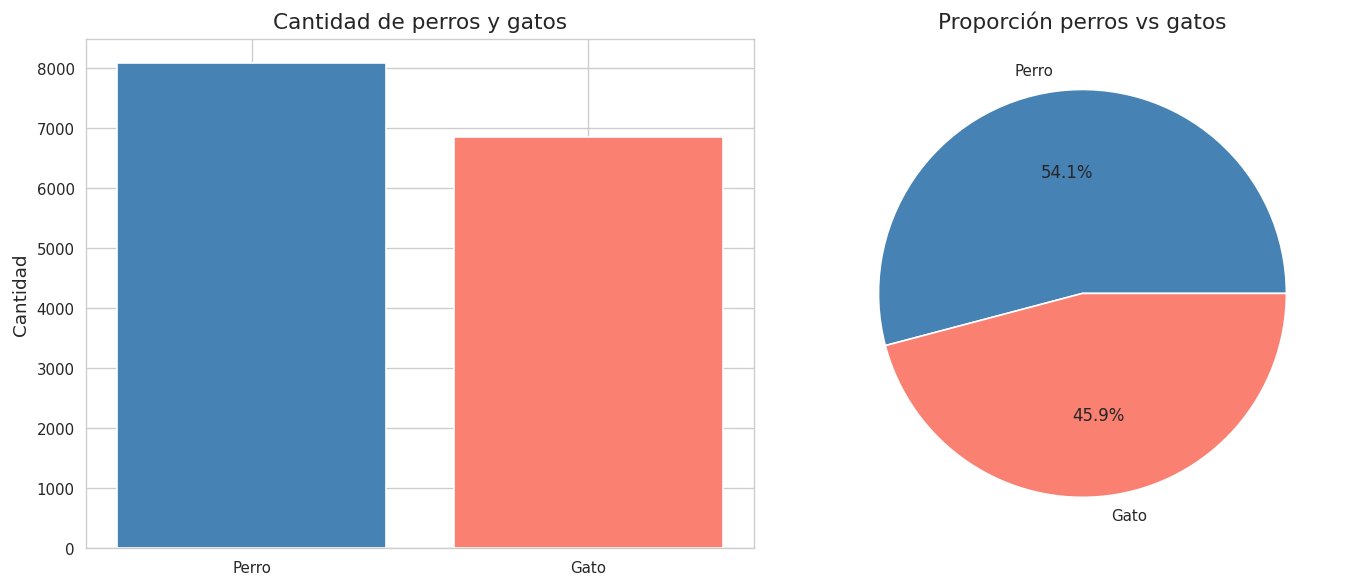

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
vc = df['TypeLabel'].value_counts()
axes[0].bar(vc.index, vc.values, color=['steelblue', 'salmon'])
axes[0].set_title('Cantidad de perros y gatos')
axes[0].set_ylabel('Cantidad')

axes[1].pie(vc.values, labels=vc.index, autopct='%1.1f%%', colors=['steelblue', 'salmon'])
axes[1].set_title('Proporción perros vs gatos')

plt.tight_layout()
plt.show()

El dataset cuenta con una mayor proporción de Perros.

### 3.3 Variables numéricas

In [16]:
NUM_COLS = ['Age', 'Quantity', 'Fee', 'VideoAmt', 'PhotoAmt' , 'DescLength', 'NameLength']

# ── Estadísticos descriptivos con skewness y kurtosis ─────────────────────────
desc = df[NUM_COLS].describe(percentiles=[.25, .5, .75, .95]).T
desc['skewness'] = df[NUM_COLS].skew().round(3)
desc['kurtosis'] = df[NUM_COLS].kurt().round(3)
desc.style.background_gradient(cmap='RdYlGn_r', subset=['skewness', 'kurtosis'])

,count,mean,std,min,25%,50%,75%,95%,max,skewness,kurtosis
Age,14950.000000,10.475518,18.175916,0.000000,2.000000,3.000000,12.000000,48.000000,255.000000,3.758000,20.716000
Quantity,14950.000000,1.576722,1.473459,1.000000,1.000000,1.000000,1.000000,4.000000,20.000000,4.600000,34.080000
Fee,14950.000000,21.321137,78.518942,0.000000,0.000000,0.000000,0.000000,150.000000,3000.000000,8.909000,191.197000
VideoAmt,14950.000000,0.056923,0.346669,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,9.445000,124.061000
PhotoAmt,14950.000000,3.894448,3.490241,0.000000,2.000000,3.000000,5.000000,10.000000,30.000000,2.859000,12.629000
DescLength,14950.000000,339.499666,373.988818,0.000000,117.000000,238.000000,432.000000,972.550000,6664.000000,3.991000,31.290000
NameLength,14950.000000,8.054582,7.149304,0.000000,4.000000,6.000000,10.000000,23.000000,47.000000,1.699000,3.185000


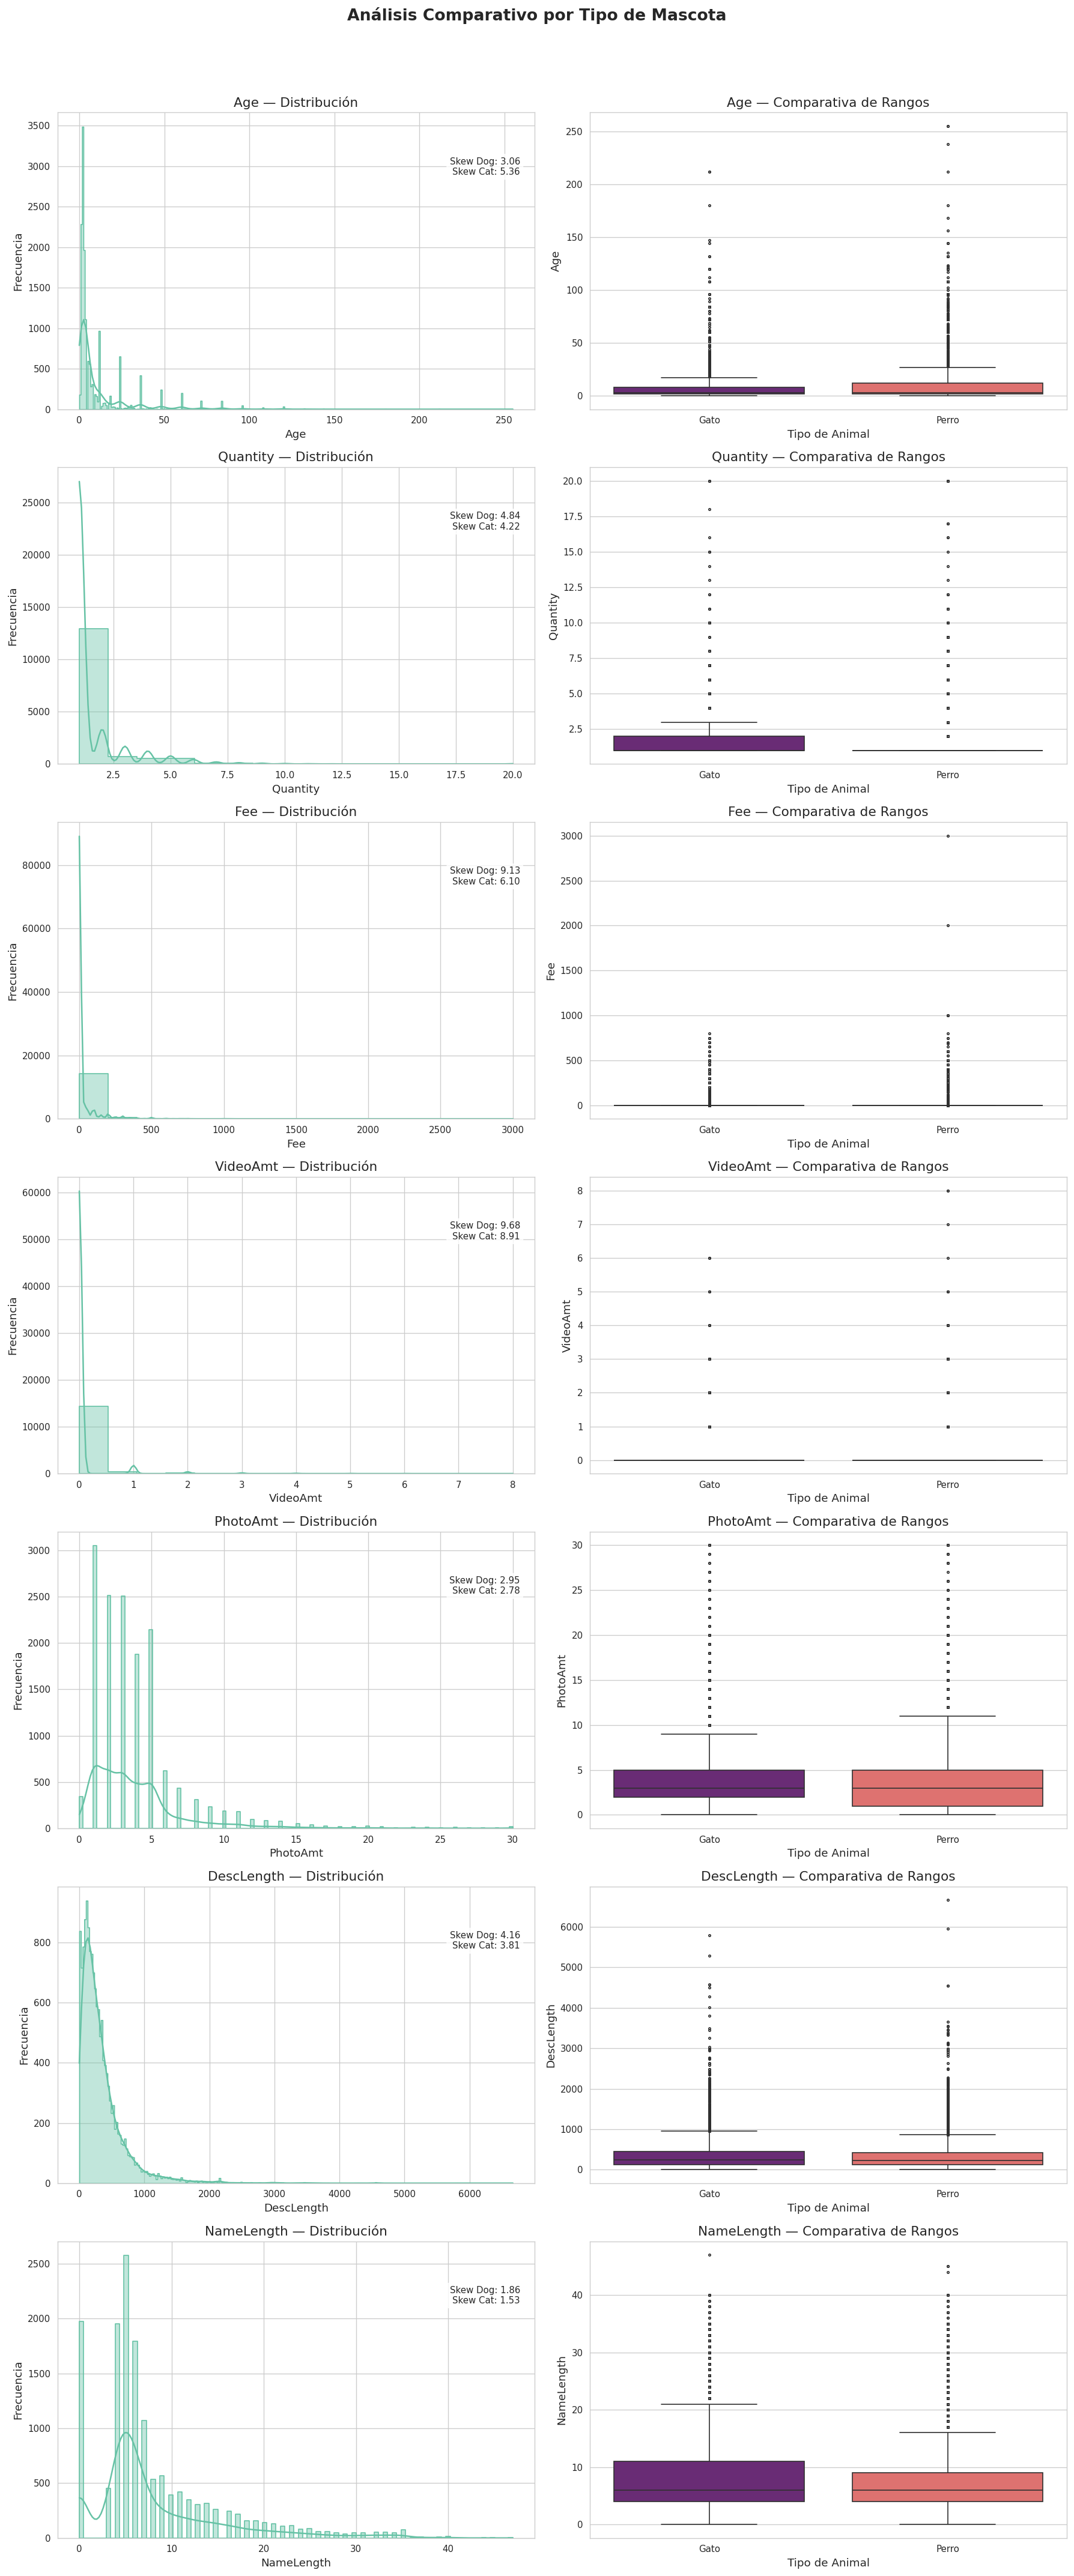

In [17]:
# 1. Mapeo para legibilidad

df_plot = df.copy()

# 2. Configuración del lienzo
fig, axes = plt.subplots(len(NUM_COLS), 2, figsize=(15, 5 * len(NUM_COLS)))

for i, col in enumerate(NUM_COLS):
    # Limpiamos nulos para esta columna específica
    data_subset = df_plot.dropna(subset=[col, 'TypeLabel'])
    
    # --- GRÁFICO 1: Histograma + KDE por Type ---
    # Usamos element="step" para que las distribuciones no se tapen totalmente
    sns.histplot(data=data_subset, x=col,  kde=True, 
                 element="step", palette="magma", ax=axes[i, 0], alpha=0.4)
    
    axes[i, 0].set_title(f'{col} — Distribución')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Frecuencia')

    # --- GRÁFICO 2: Boxplot por Type ---
    sns.boxplot(data=data_subset, x='TypeLabel', y=col, 
                palette="magma", ax=axes[i, 1], flierprops=dict(markersize=2))
    
    axes[i, 1].set_title(f'{col} — Comparativa de Rangos')
    axes[i, 1].set_xlabel('Tipo de Animal')
    axes[i, 1].set_ylabel(col)

    # Cálculo de Skewness por grupo para información adicional
    skew_dog = data_subset[data_subset['TypeLabel'] == 'Perro'][col].skew()
    skew_cat = data_subset[data_subset['TypeLabel'] == 'Gato'][col].skew()
    
    text_str = f'Skew Dog: {skew_dog:.2f}\nSkew Cat: {skew_cat:.2f}'
    axes[i, 0].text(0.97, 0.85, text_str, transform=axes[i, 0].transAxes,
                    ha='right', va='top', fontsize=9,
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Ajustes finales
plt.suptitle('Análisis Comparativo por Tipo de Mascota', fontsize=16, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

In [18]:
# ── Análisis de Fee: ¿cuántas mascotas son gratuitas? ─────────────────────────
fee_zero_pct = (df['Fee'] == 0).mean() * 100
print(f'Mascotas con Fee = 0 (gratuitas): {fee_zero_pct:.1f}%')

# ── PhotoAmt: distribución de cantidad de fotos ───────────────────────────────
print(f'\nMascotas sin fotos (PhotoAmt=0): {(df["PhotoAmt"]==0).mean()*100:.1f}%')
print(f'Mascotas sin videos (VideoAmt=0): {(df["VideoAmt"]==0).mean()*100:.1f}%')

# ── Age: outliers extremos ────────────────────────────────────────────────────
print(f'\nAge — valores extremos (>5 años = 60 meses):')
print(df[df['Age'] > 60]['Age'].describe())

Mascotas con Fee = 0 (gratuitas): 84.4%

Mascotas sin fotos (PhotoAmt=0): 2.3%
Mascotas sin videos (VideoAmt=0): 96.2%

Age — valores extremos (>5 años = 60 meses):
count    392.000000
mean      90.622449
std       26.666076
min       61.000000
25%       72.000000
50%       84.000000
75%       96.000000
max      255.000000
Name: Age, dtype: float64


- Las variables presentan fuerte asimetría y presencia de outliers, con concentración en valores bajos.
- La mayoría de las mascotas son jóvenes, lo que puede influir en la adopción.
- Las adopciones son principalmente gratuitas.

#### Análisis de outliers extremos

In [19]:
# Outliers por IQR para cada variable numérica
def outlier_iqr(series, label):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    out = series[(series < lo) | (series > hi)]
    print(f'{label:15s}: {len(out):4d} outliers ({len(out)/len(series)*100:.1f}%)  '
          f'| rango extremo: [{series.min():.0f}, {series.max():.0f}]  '
          f'| fence sup: {hi:.1f}')

NUM_BASE = ['Age', 'Quantity', 'Fee', 'VideoAmt', 'PhotoAmt', 'DescLength']
for c in NUM_BASE:
    outlier_iqr(df[c].dropna(), c)

# Casos extremos de Age con contexto
print(f'\nMascotas con Age > 100 meses ({len(df[df["Age"]>100])} casos):')
extreme_age = df[df['Age'] > 100][['Type','Age','AdoptionSpeed','Breed1Name','IsFree']].copy()
extreme_age['Type'] = extreme_age['Type'].map({1:'Perro',2:'Gato'})
print(extreme_age.sort_values('Age', ascending=False).head(15).to_string(index=False))


Age            : 1501 outliers (10.0%)  | rango extremo: [0, 255]  | fence sup: 27.0
Quantity       : 3423 outliers (22.9%)  | rango extremo: [1, 20]  | fence sup: 1.0
Fee            : 2330 outliers (15.6%)  | rango extremo: [0, 3000]  | fence sup: 0.0
VideoAmt       :  574 outliers (3.8%)  | rango extremo: [0, 8]  | fence sup: 0.0
PhotoAmt       :  922 outliers (6.2%)  | rango extremo: [0, 30]  | fence sup: 9.5
DescLength     :  880 outliers (5.9%)  | rango extremo: [0, 6664]  | fence sup: 904.5

Mascotas con Age > 100 meses (84 casos):
 Type  Age  AdoptionSpeed           Breed1Name  IsFree
Perro  255              4          Mixed Breed       1
Perro  255              4          Mixed Breed       1
Perro  238              4          Mixed Breed       1
Perro  212              4          Mixed Breed       1
 Gato  212              3  Domestic Short Hair       1
 Gato  212              3  Domestic Short Hair       1
 Gato  180              3 Domestic Medium Hair       1
Perro  180      

### 3.4 Variables categóricas

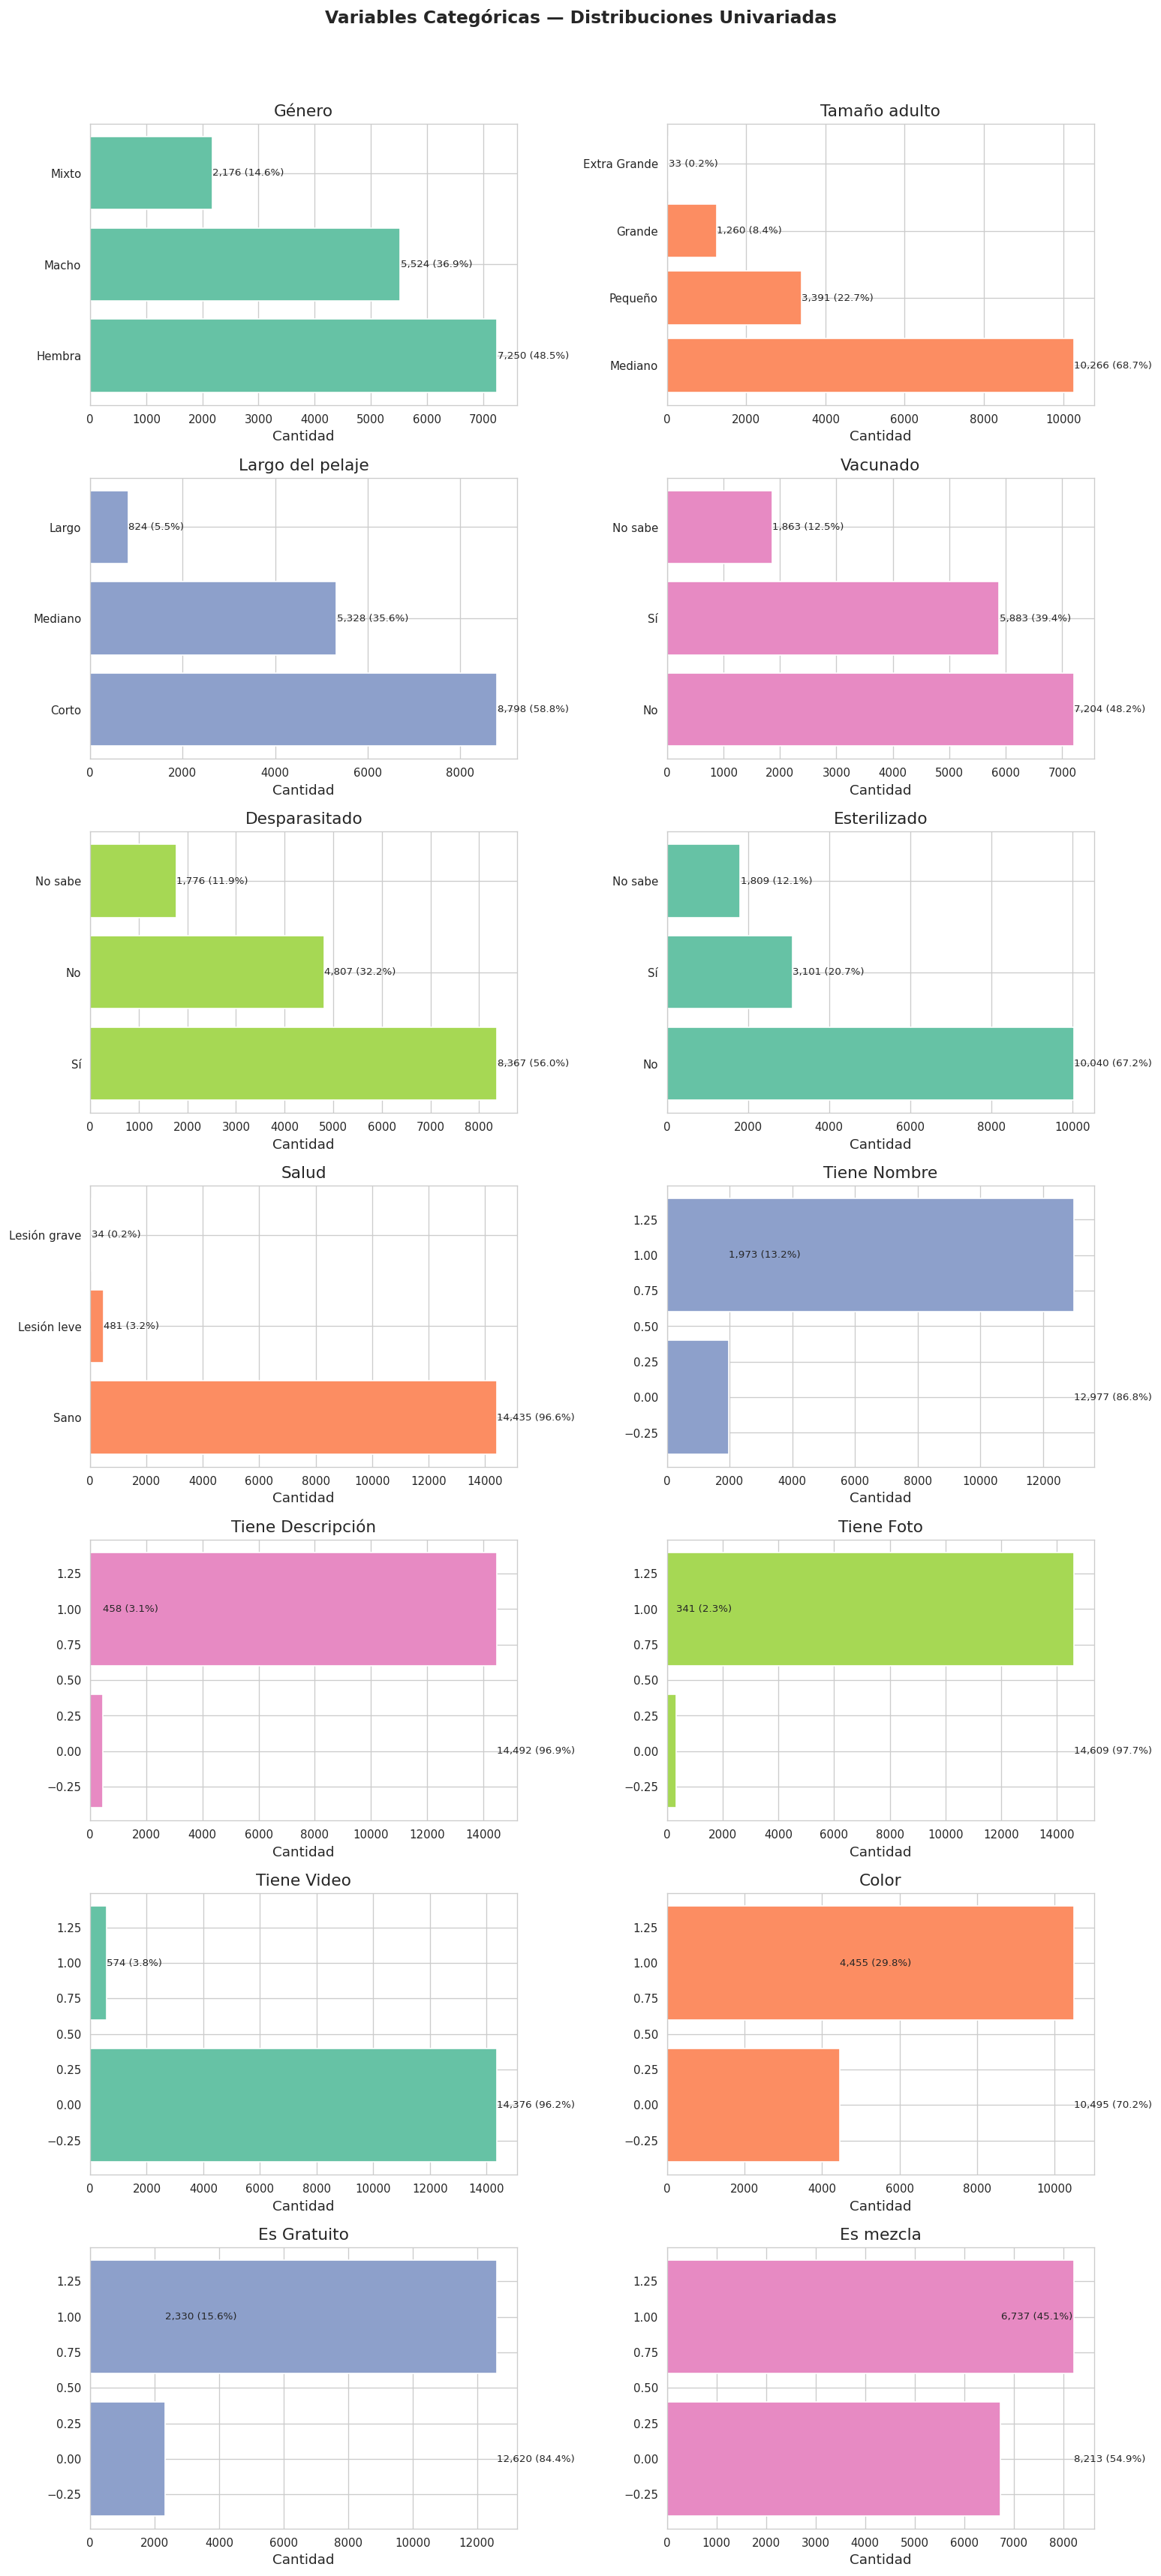

In [20]:
# ── Variables categóricas ordinales ───────────────────────────────────────────
CAT_COLS = {
    'GenderLabel': 'Género',
    'MaturitySizeLabel': 'Tamaño adulto',
    'FurLengthLabel': 'Largo del pelaje',
    'VaccinatedLabel': 'Vacunado',
    'DewormedLabel': 'Desparasitado',
    'SterilizedLabel': 'Esterilizado',
    'HealthLabel': 'Salud',
    'HasName': 'Tiene Nombre',
    'HasDesc': 'Tiene Descripción',
    'HasPhoto': 'Tiene Foto',
    'HasVideo': 'Tiene Video',
    'MixedColor': 'Color',
    'IsFree': 'Es Gratuito',
    'MixedBreed': 'Es mezcla'
    
    
}

import math

# 1. Calculate required rows (assuming 2 columns)
n_cols = 2
n_vars = len(CAT_COLS)
n_rows = math.ceil(n_vars / n_cols) # This will give you 7 rows for 14 variables

# 2. Create the figure with the new dynamic row count
fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, 4 * n_rows))
axes = axes.flatten()

# 3. Your existing loop (no changes needed here)
for i, (col, title) in enumerate(CAT_COLS.items()):
    counts = df[col].value_counts()
    axes[i].barh(counts.index, counts.values, color=PALETTE[i % 5], edgecolor='white')
    axes[i].set_title(title)
    axes[i].set_xlabel('Cantidad')
    for j, val in enumerate(counts.values):
        axes[i].text(val + 5, j, f'{val:,} ({val/len(df)*100:.1f}%)', 
                     va='center', fontsize=8)

# 4. Hide unused axes (if n_vars is odd)
for j in range(len(CAT_COLS), len(axes)):
    axes[j].axis('off')

plt.suptitle('Variables Categóricas — Distribuciones Univariadas', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

- Predominan las hembras frente a machos y mixtos.
- La mayoría de los animales son de tamaño mediano y pelo corto, siendo minoría los de tamaño extremo y pelo largo.
- En cuanto al estado sanitario, la mayor parte de los animales están sanos, aunque muchos no están vacunados, desparasitados o esterilizados.
- Destaca que muchos animales no están esterilizados, lo que puede influir en su adopción.
- Entre las variables derivadas, la gran mayoría tiene nombre y publicaciones con fotos, lo cual podría favorecer la adopción. Sólo un breve porcentaje tiene videos.
- Predominan los animales no mestizos, aunque hay una proporción relevante de mestizos.
- Muchos animales son de adopción gratuita, lo que podría afectar la rapidez de adopción.

### 3.5 Distribución geográfica (Estado)

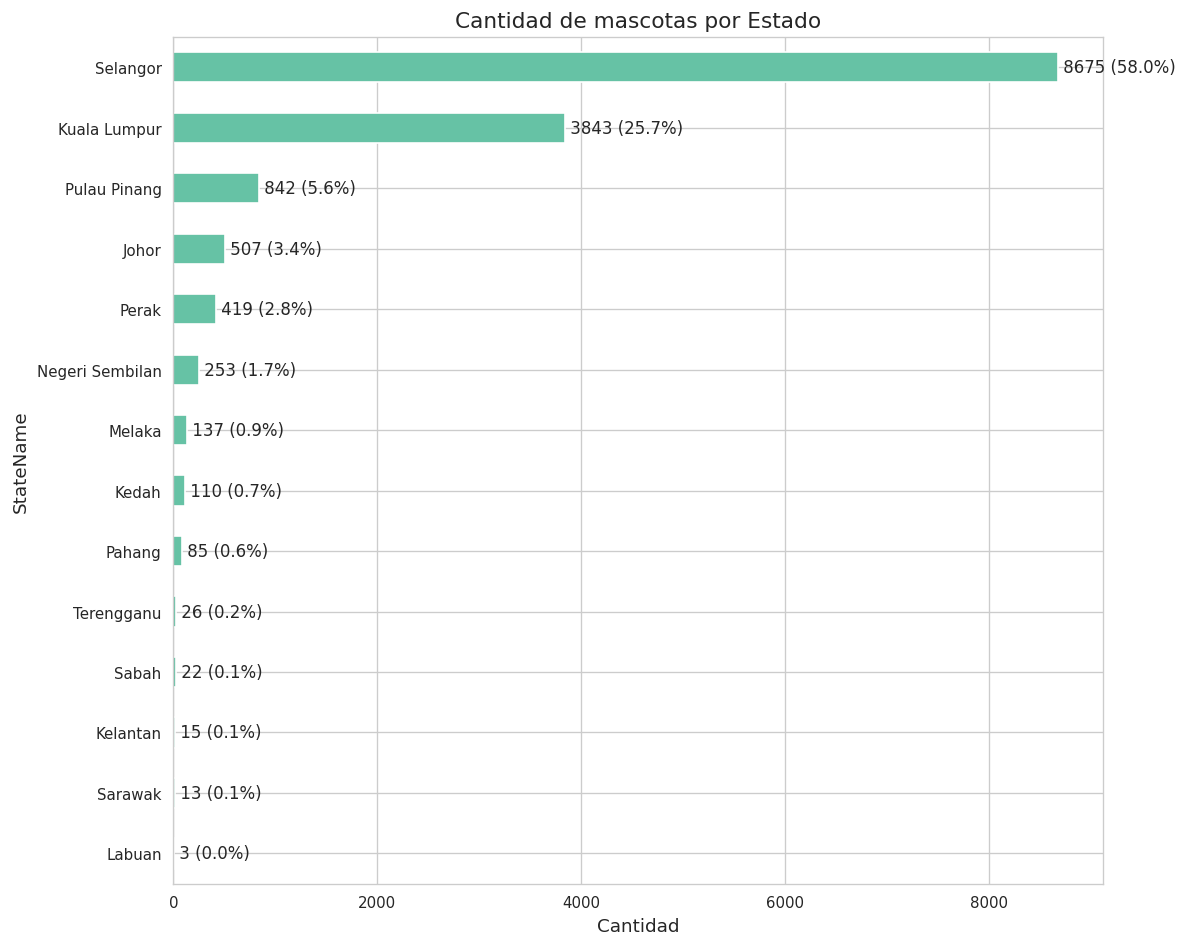

In [21]:
state_counts = df['StateName'].value_counts().sort_values(ascending=True)
state_pct = state_counts / state_counts.sum() * 100

plt.figure(figsize=(10, 8))
ax = state_counts.plot(kind='barh')

plt.title('Cantidad de mascotas por Estado')
plt.xlabel('Cantidad')

for i, v in enumerate(state_counts.values):
    ax.text(
        v,
        i,
        f' {v} ({state_pct.iloc[i]:.1f}%)',
        va='center'
    )

plt.tight_layout()
plt.show()

### 3.6 Nombres y descripciones

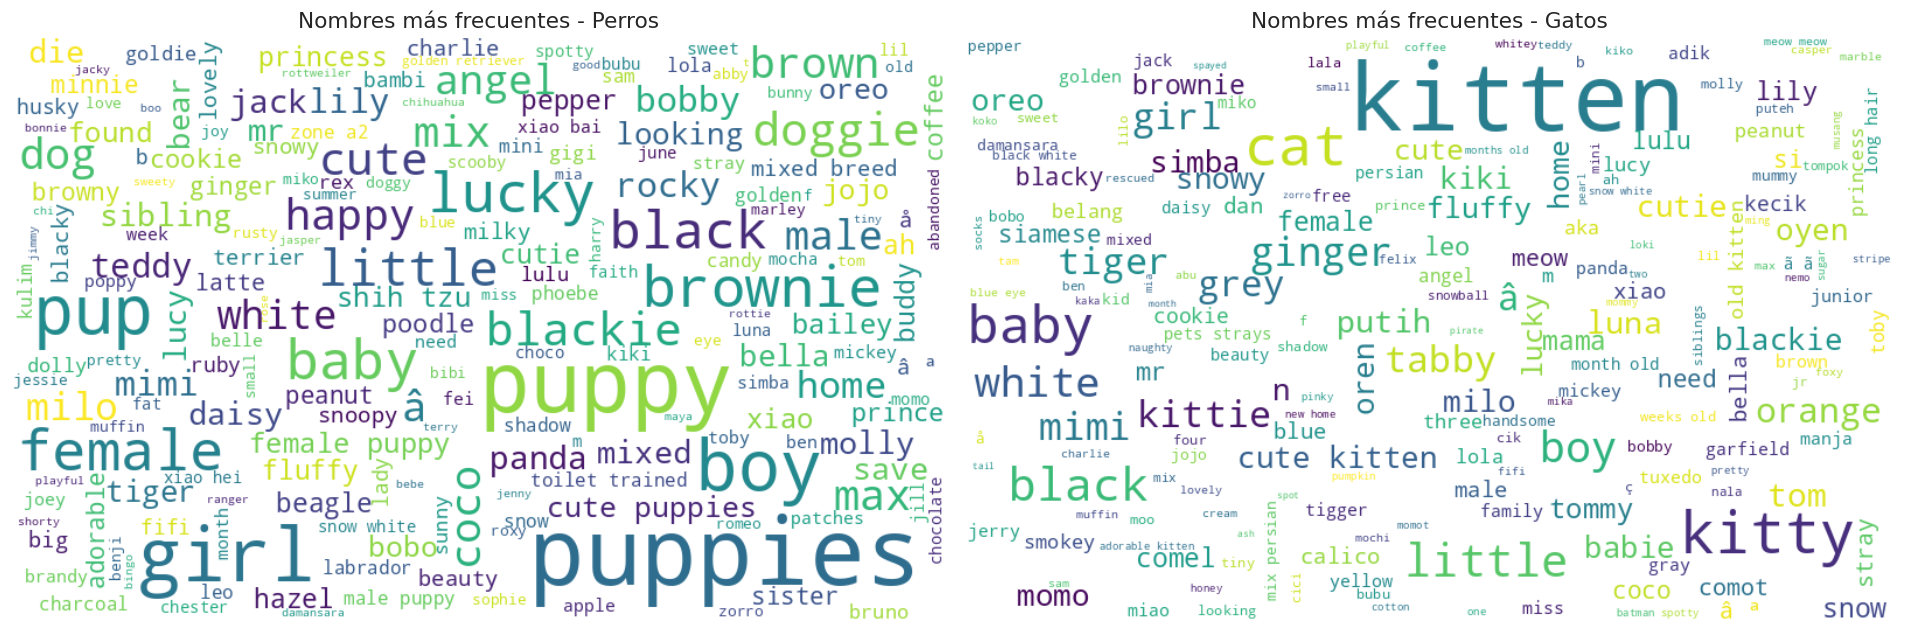

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, tipo in zip(axes, ['Perro', 'Gato']):
    text = ' '.join(df.loc[df['TypeLabel'] == tipo, 'Name'].dropna().values)
    if text.strip():
        wc = WordCloud(max_font_size=80, background_color='white',
                       width=800, height=500).generate(text)
        ax.imshow(wc, interpolation='bilinear')
        ax.set_title(f'Nombres más frecuentes - {tipo}s')
        ax.axis('off')

plt.tight_layout()
plt.show()

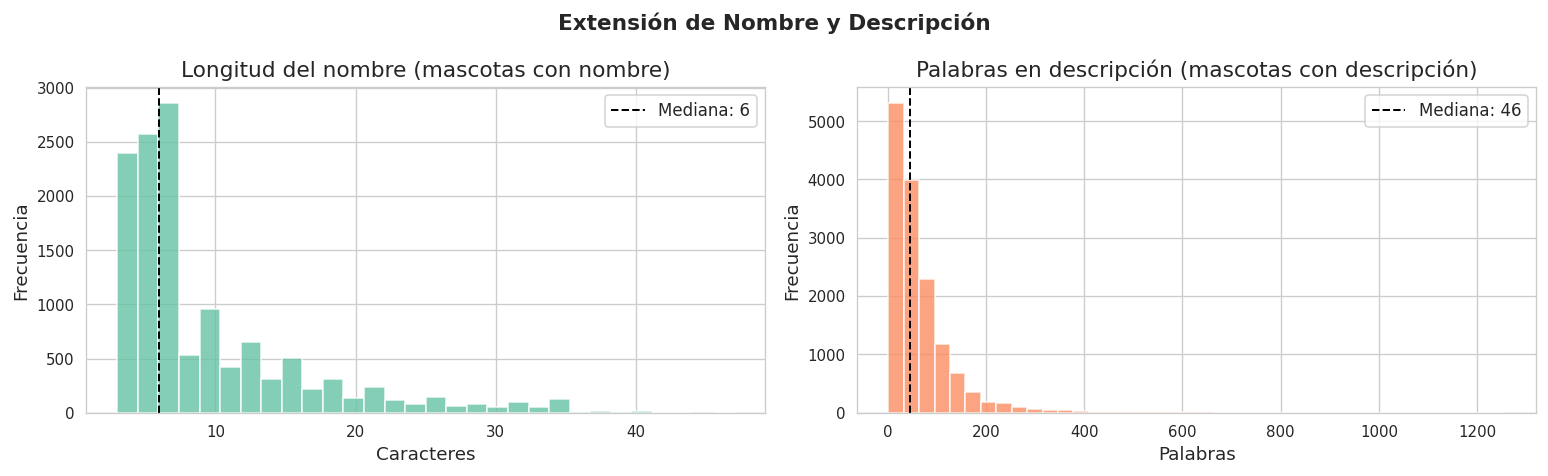

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribución de largo de nombre (solo con nombre)
df_named = df[df['HasName'] == 1]
axes[0].hist(df_named['NameLength'], bins=30, color=PALETTE[0], alpha=0.8, edgecolor='white')
axes[0].set_title('Longitud del nombre (mascotas con nombre)')
axes[0].set_xlabel('Caracteres')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(df_named['NameLength'].median(), color='black', linestyle='--', linewidth=1.2,
                label=f'Mediana: {df_named["NameLength"].median():.0f}')
axes[0].legend()

# Distribución de palabras en descripción
df_desc = df[df['HasDesc'] == 1]
axes[1].hist(df_desc['DescWordCount'], bins=40, color=PALETTE[1], alpha=0.8, edgecolor='white')
axes[1].set_title('Palabras en descripción (mascotas con descripción)')
axes[1].set_xlabel('Palabras')
axes[1].set_ylabel('Frecuencia')
axes[1].axvline(df_desc['DescWordCount'].median(), color='black', linestyle='--', linewidth=1.2,
                label=f'Mediana: {df_desc["DescWordCount"].median():.0f}')
axes[1].legend()

plt.suptitle('Extensión de Nombre y Descripción', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 3.7 Colores

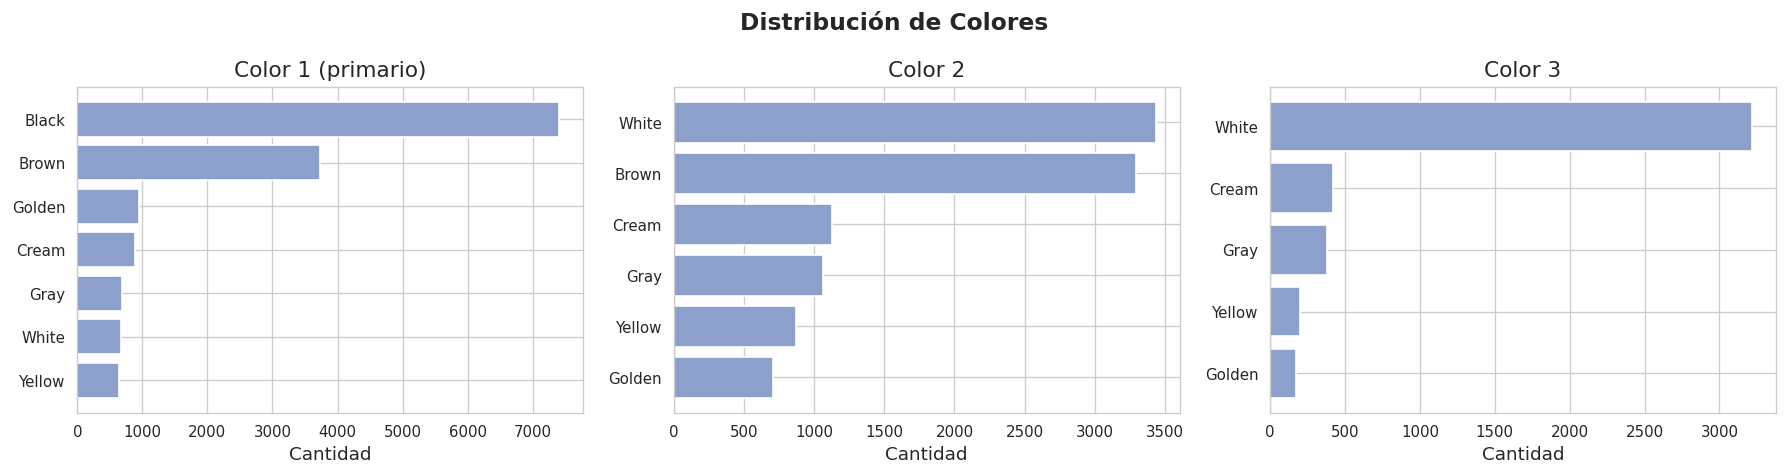

In [24]:
# ── Colores ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, title in zip(axes,
                           ['Color1Label', 'Color2Label', 'Color3Label'],
                           ['Color 1 (primario)', 'Color 2', 'Color 3']):
    counts = df[col].value_counts().dropna().head(10)
    ax.barh(counts.index[::-1], counts.values[::-1], color=PALETTE[2])
    ax.set_title(title)
    ax.set_xlabel('Cantidad')

plt.suptitle('Distribución de Colores', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.8 Razas — distribución univariada

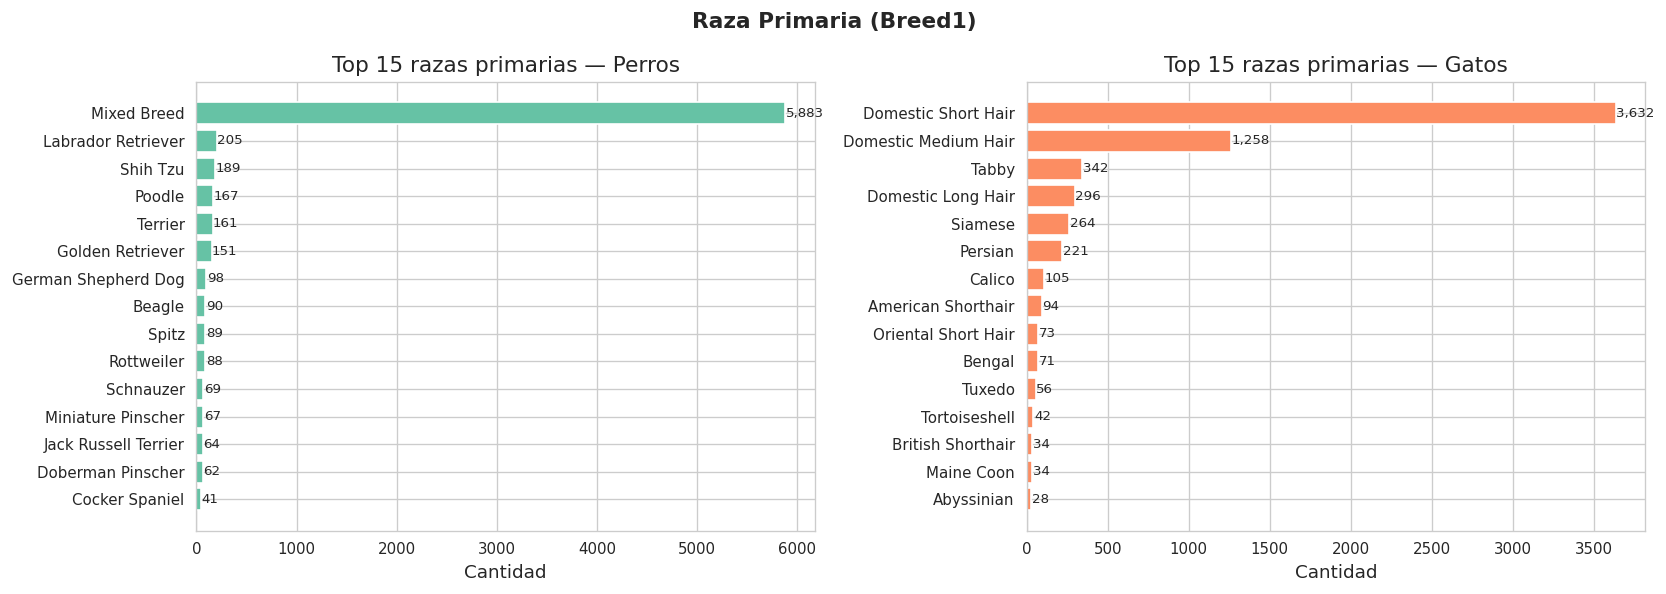

Razas únicas (perros): 116
Razas únicas (gatos):  68
Mascotas de raza mixta: 54.9%


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, type_val, label, color in zip(axes, [1, 2], ['Perros', 'Gatos'], [PALETTE[0], PALETTE[1]]):
    subset = df[df['Type'] == type_val]
    top = subset['Breed1Name'].value_counts().head(15)
    ax.barh(top.index[::-1], top.values[::-1], color=color, edgecolor='white')
    ax.set_title(f'Top 15 razas primarias — {label}')
    ax.set_xlabel('Cantidad')
    for j, val in enumerate(top.values[::-1]):
        ax.text(val + 5, j, f'{val:,}', va='center', fontsize=8)

plt.suptitle('Raza Primaria (Breed1)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Razas únicas (perros): {df[df["Type"]==1]["Breed1"].nunique()}')
print(f'Razas únicas (gatos):  {df[df["Type"]==2]["Breed1"].nunique()}')
print(f'Mascotas de raza mixta: {df["MixedBreed"].mean()*100:.1f}%')


### 3.9 RescuerID — distribución de frecuencia

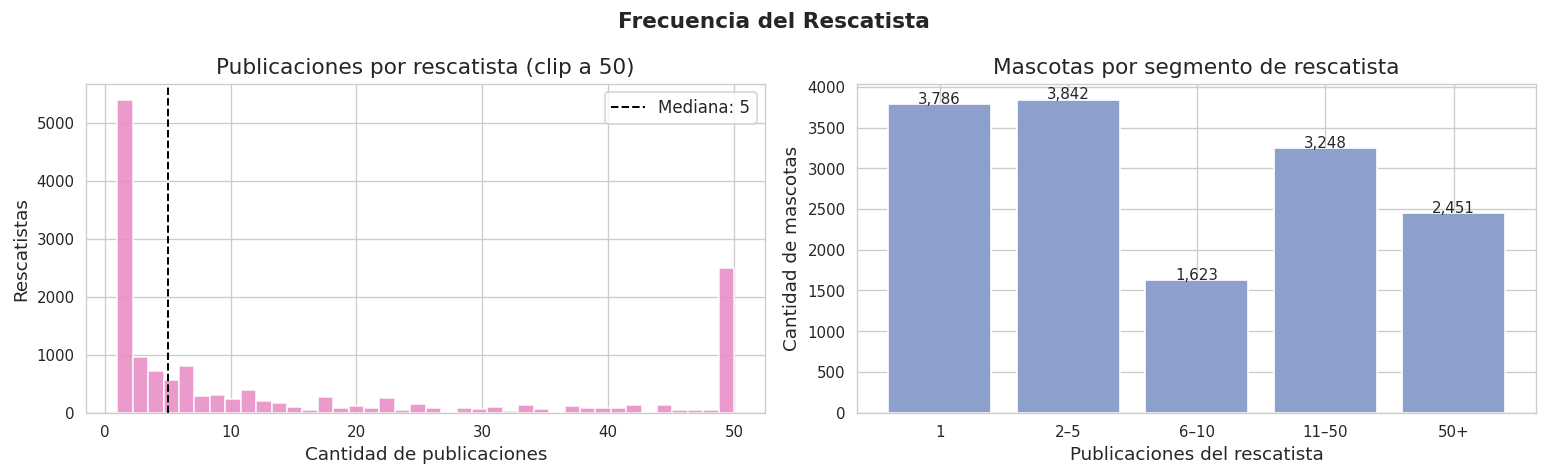

In [26]:
rescuer_freq = df['RescuerFrequency'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histograma de publicaciones por rescatista
axes[0].hist(df['RescuerFrequency'].clip(upper=50), bins=40, 
             color=PALETTE[3], edgecolor='white', alpha=0.85)
axes[0].set_title('Publicaciones por rescatista (clip a 50)')
axes[0].set_xlabel('Cantidad de publicaciones')
axes[0].set_ylabel('Rescatistas')
axes[0].axvline(df['RescuerFrequency'].median(), color='black', linestyle='--', linewidth=1.2,
                label=f'Mediana: {df["RescuerFrequency"].median():.0f}')
axes[0].legend()

# Segmentación de rescatistas
bins_r = [0, 1, 5, 10, 50, df['RescuerFrequency'].max()+1]
labels_r = ['1', '2–5', '6–10', '11–50', '50+']
rescuer_seg = pd.cut(df['RescuerFrequency'], bins=bins_r, labels=labels_r)
seg_counts = rescuer_seg.value_counts().sort_index()
axes[1].bar(seg_counts.index, seg_counts.values, color=PALETTE[2], edgecolor='white')
axes[1].set_title('Mascotas por segmento de rescatista')
axes[1].set_xlabel('Publicaciones del rescatista')
axes[1].set_ylabel('Cantidad de mascotas')
for i, v in enumerate(seg_counts.values):
    axes[1].text(i, v + 10, f'{v:,}', ha='center', fontsize=9)

plt.suptitle('Frecuencia del Rescatista', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 4. Análisis Bivariado (relación con AdoptionSpeed)

In [27]:
# Función auxiliar: tasa de adopción rápida (clases 0+1) por categoría
def adoption_rate_by(col, df=df, fast_classes=(0, 1)):
    """Calcula % de adopción rápida por categoría."""
    result = df.groupby(col)['AdoptionSpeed'].apply(
        lambda x: (x.isin(fast_classes)).mean() * 100
    ).sort_values(ascending=False)
    return result

### 4.1 AdoptionSpeed según tipo de animal

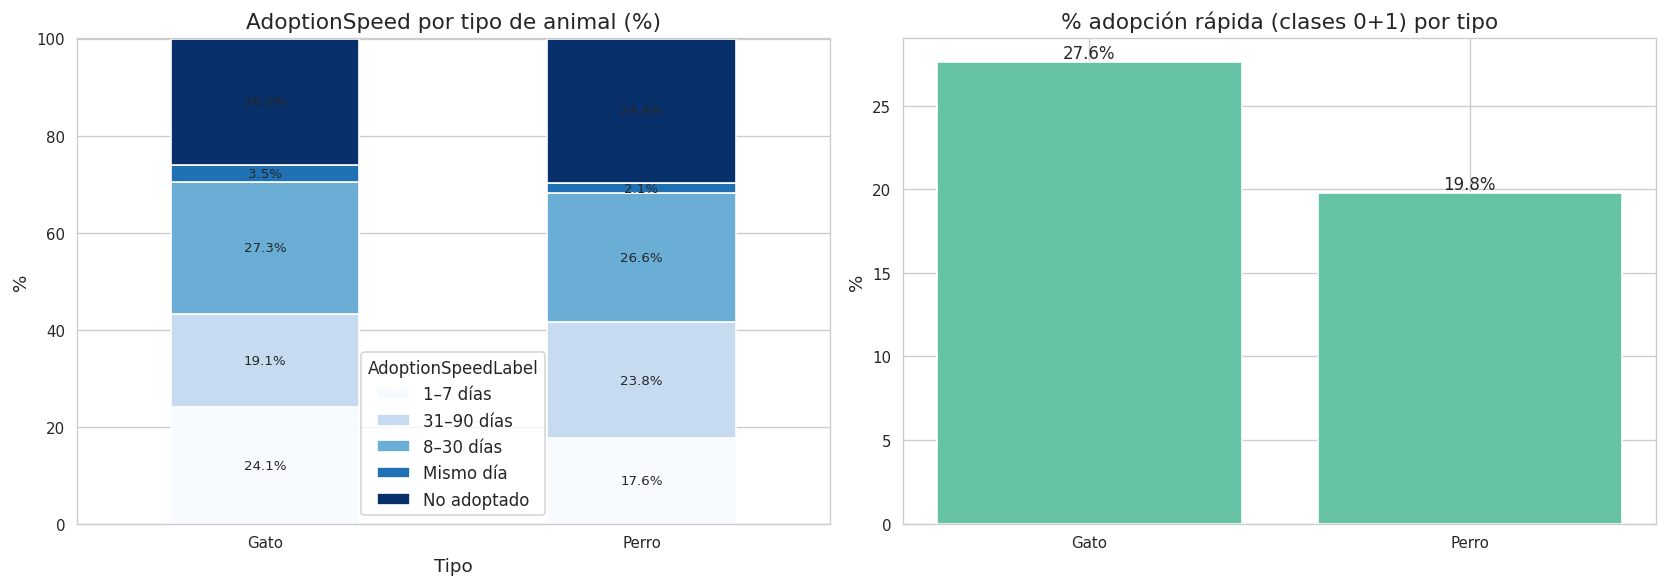

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# izquierda
cross = df.groupby(['TypeLabel', 'AdoptionSpeedLabel']).size().unstack(fill_value=0)
cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100

cross_pct.plot(kind='bar', stacked=True, ax=axes[0], colormap='Blues', edgecolor='white')

axes[0].set_title('AdoptionSpeed por tipo de animal (%)')
axes[0].set_xlabel('Tipo')
axes[0].set_ylabel('%')
axes[0].set_ylim(0, 100)
axes[0].tick_params(axis='x', rotation=0)

for i, tipo in enumerate(cross_pct.index):
    cumulative = 0
    for speed in cross_pct.columns:
        pct = cross_pct.loc[tipo, speed]

        if pct > 0:
            axes[0].text(
                i,
                cumulative + pct / 2,
                f'{pct:.1f}%',
                ha='center',
                va='center',
                fontsize=8
            )
        cumulative += pct

# Derecha
rate = adoption_rate_by('TypeLabel')

bars = axes[1].bar(rate.index, rate.values)

axes[1].set_title('% adopción rápida (clases 0+1) por tipo')
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=0)

# 👉 etiquetas (%)
for i, v in enumerate(rate.values):
    axes[1].text(
        i,
        v,
        f'{v:.1f}%',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

El tipo de animal parece influir en la velocidad de adopción. Los gatos tienden a adoptarse más rápido que los perros, mientras que los perros tienen mayor peso en clases más lentas (especialmente 3 y 4), lo que sugiere más dificultad para ser adoptados.

### 4.2 Edad y AdoptionSpeed

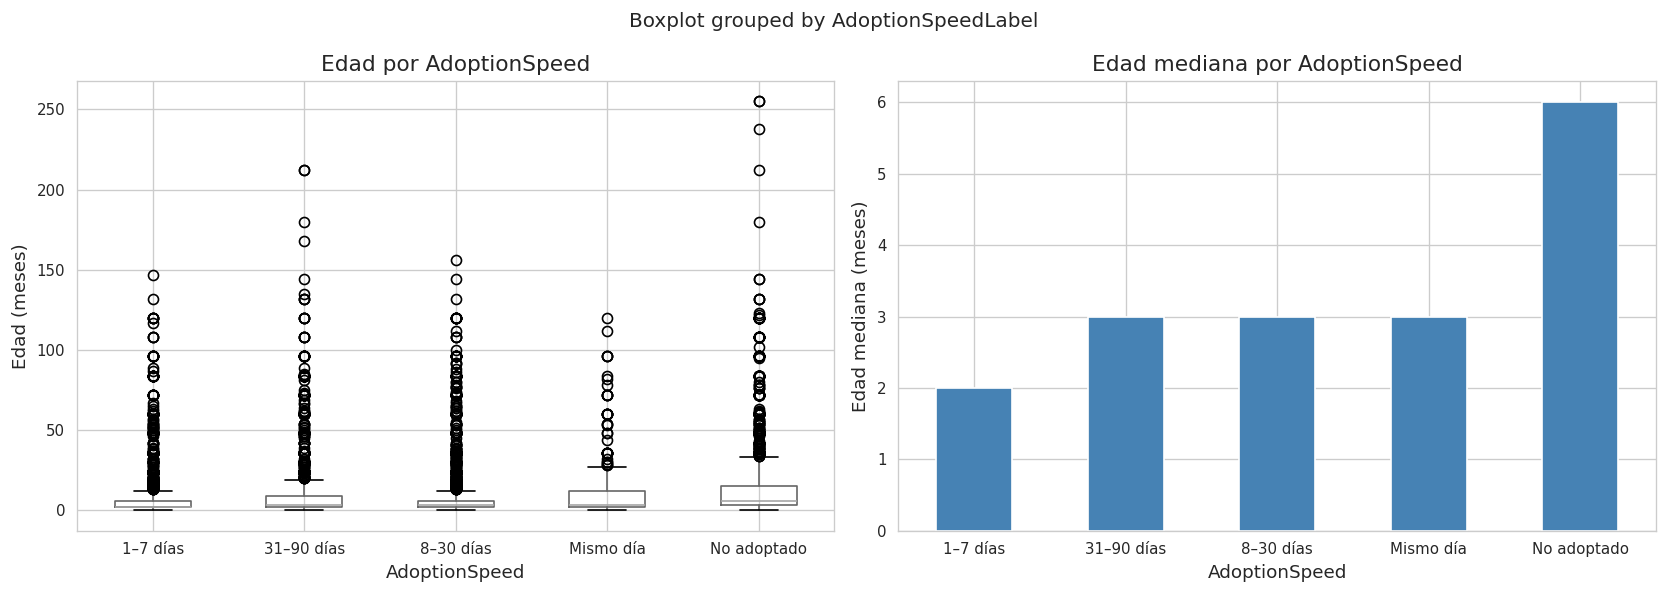

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot de edad por clase de adopción
df.boxplot(column='Age', by='AdoptionSpeedLabel', ax=axes[0])
axes[0].set_title('Edad por AdoptionSpeed')
axes[0].set_xlabel('AdoptionSpeed')
axes[0].set_ylabel('Edad (meses)')

# Edad promedio por clase
age_median = df.groupby('AdoptionSpeedLabel')['Age'].median()
age_median.plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Edad mediana por AdoptionSpeed')
axes[1].set_xlabel('AdoptionSpeed')
axes[1].set_ylabel('Edad mediana (meses)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

Edad y velocidad de adopción tiene una relacion positiva: las mascotas más jóvenes tienden a adoptarse más rápido, mientras que a mayor edad aumenta la probabilidad de una adopción lenta. En las adopciones más lentas (especialmente clase 4), la edad mediana aumenta notablemente (≈6 meses), indicando mayor dificultad para adoptar animales más mayores.

### 4.3 Variables de salud y AdoptionSpeed

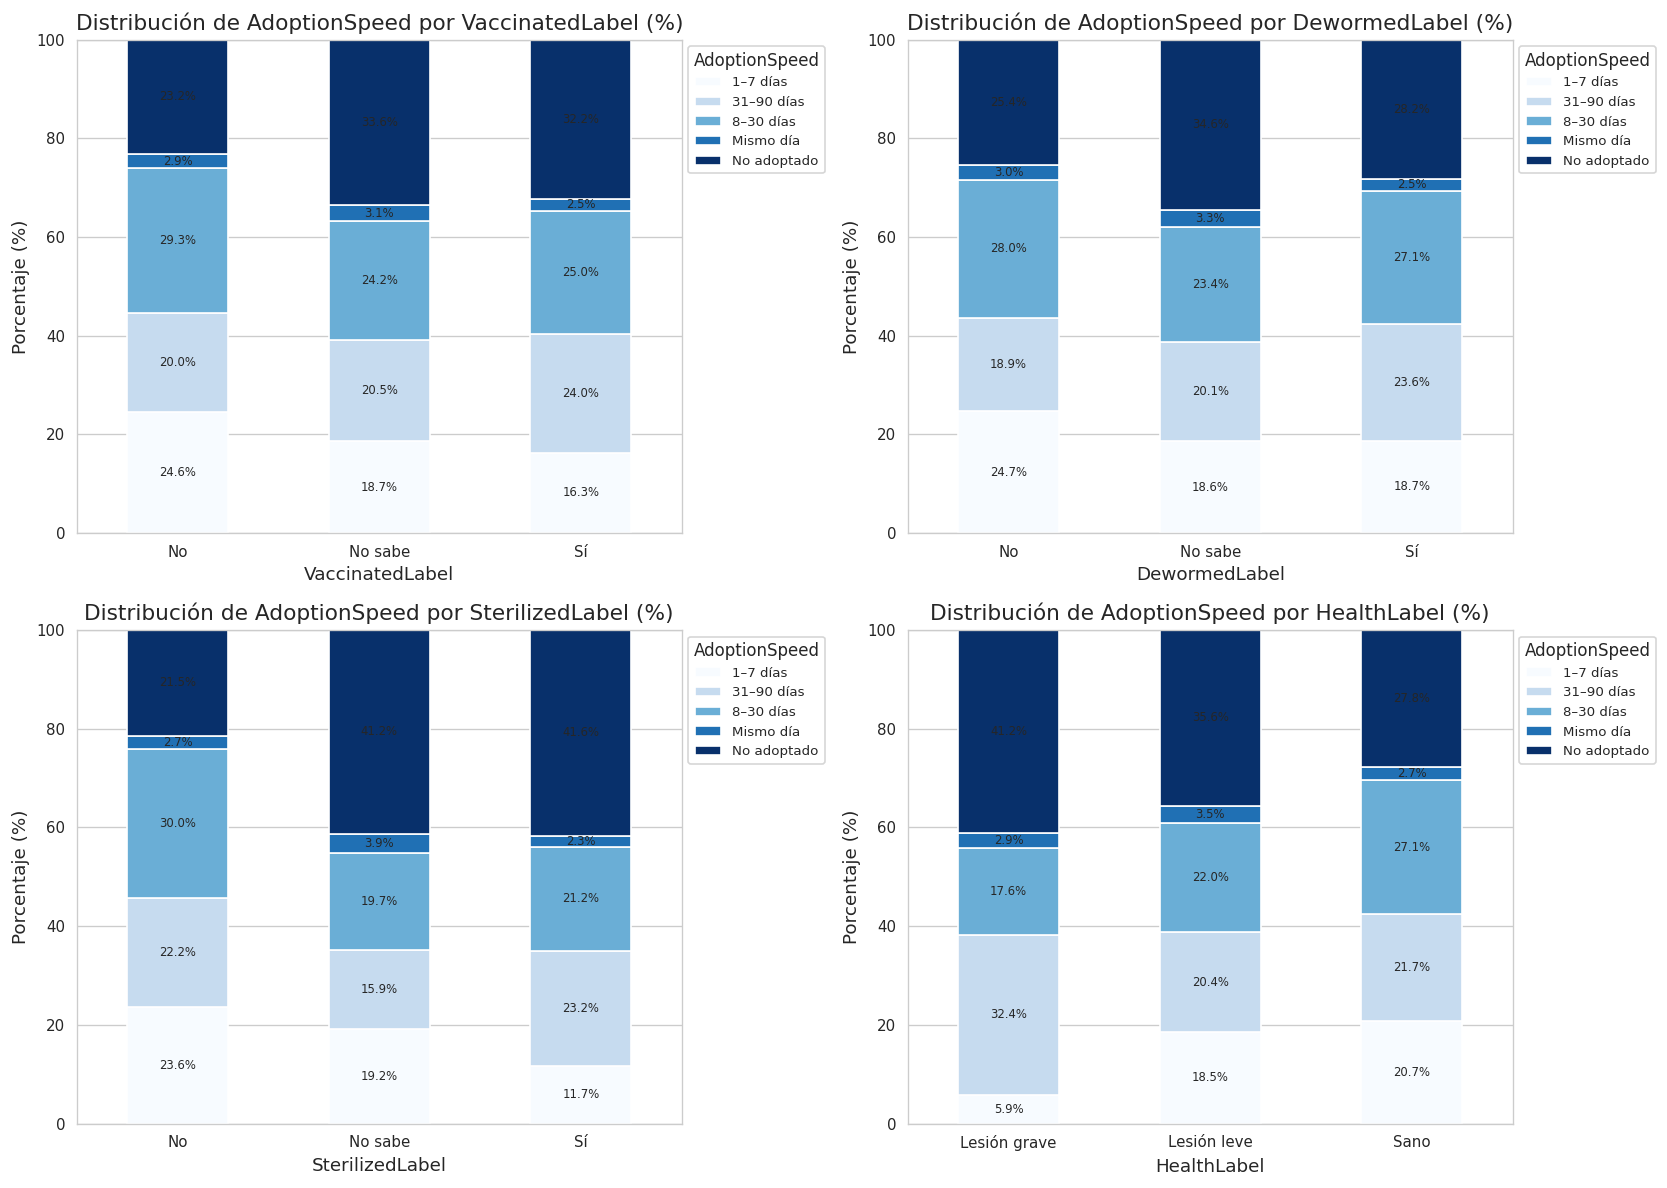

In [30]:
health_cols = ['VaccinatedLabel', 'DewormedLabel', 'SterilizedLabel', 'HealthLabel']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(health_cols):
    # Calcular proporciones
    cross = df.groupby([col, 'AdoptionSpeedLabel']).size().unstack(fill_value=0)
    cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100

    cross_pct.plot(kind='bar', stacked=True, ax=axes[i], colormap='Blues', edgecolor='white')

    axes[i].set_title(f'Distribución de AdoptionSpeed por {col} (%)')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Porcentaje (%)')
    axes[i].set_ylim(0, 100)
    axes[i].tick_params(axis='x', rotation=0)

    axes[i].legend(title='AdoptionSpeed', fontsize=8, loc='upper left', bbox_to_anchor=(1, 1))

    for j, category in enumerate(cross_pct.index):
        cumulative = 0
        for speed in cross_pct.columns:
            pct = cross_pct.loc[category, speed]

            if pct > 0:
                axes[i].text(
                    j,
                    cumulative + pct / 2,
                    f'{pct:.1f}%',
                    ha='center',
                    va='center',
                    fontsize=7
                )
            cumulative += pct

plt.tight_layout()
plt.show()

El estado de salud parcece ser la variable más influyente: los animales sanos tienen mayor proporción de adopciones rápidas, y los que presentan lesiones (especialmente graves) se concentran en clases más altas.

El hecho de que las adopciones rápidas parecieran presentarse con más frecuencias en animales no vacunados, desparacitados o esterilizados puede puede estar mediado por otras características, como la edad.

### 4.4 Fee (tarifa) y AdoptionSpeed

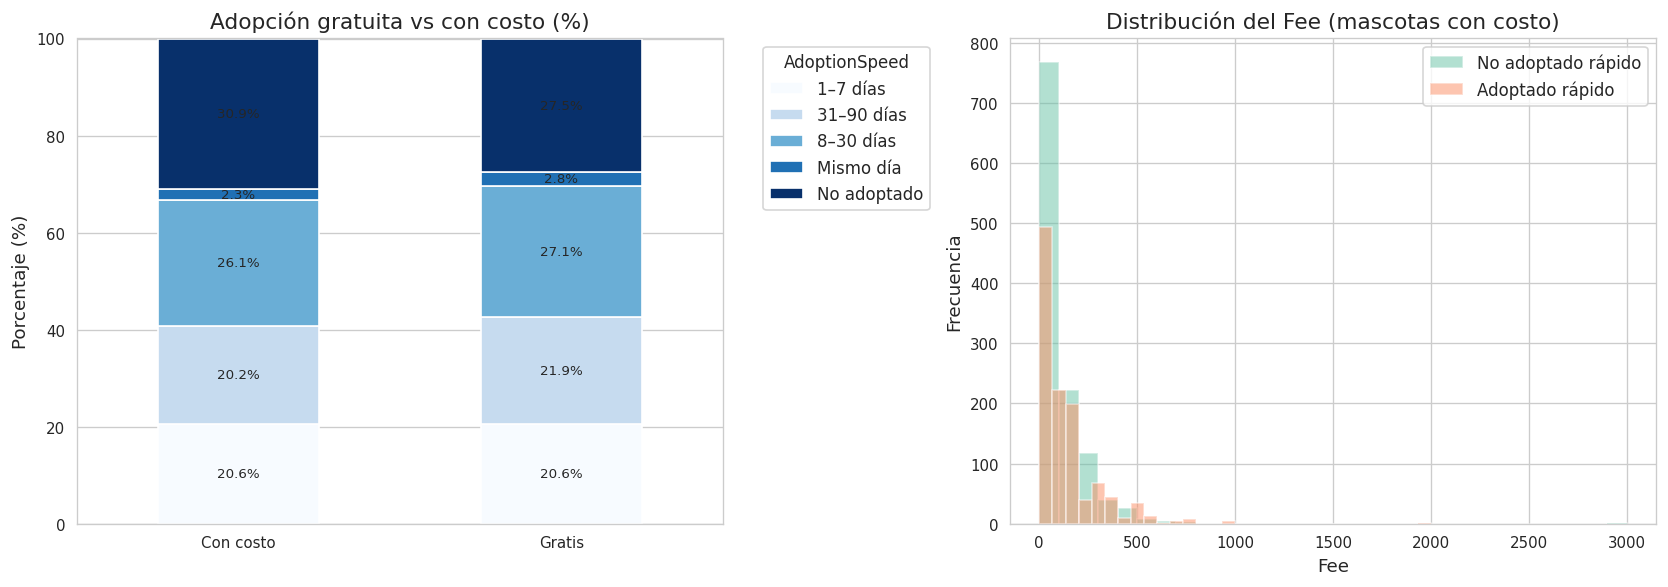

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Gratis vs pago (izquierda)
cross = df.groupby(['IsFree', 'AdoptionSpeedLabel']).size().unstack(fill_value=0)
cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100
# IsFree=0 → 'Con costo', IsFree=1 → 'Gratis' (orden preservado del groupby)
cross_pct.index = ['Con costo', 'Gratis']

cross_pct.plot(kind='bar', stacked=True, ax=axes[0], colormap='Blues', edgecolor='white')

axes[0].set_title('Adopción gratuita vs con costo (%)')
axes[0].set_ylabel('Porcentaje (%)')
axes[0].set_ylim(0, 100)
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='AdoptionSpeed', bbox_to_anchor=(1.05, 1), loc='upper left')

for i, category in enumerate(cross_pct.index):
    cumulative = 0
    for speed in cross_pct.columns:
        pct = cross_pct.loc[category, speed]

        if pct > 0:
            axes[0].text(
                i,
                cumulative + pct / 2,
                f'{pct:.1f}%',
                ha='center',
                va='center',
                fontsize=8
            )
        cumulative += pct

# 2. Distribución del fee para adoptados rápido vs lento (derecha)
df_fee = df[df['Fee'] > 0].copy()
# Definimos rápido como clases 0, 1 y 2
df_fee['Rapido'] = df_fee['AdoptionSpeed'].isin([0, 1, 2])

# Graficamos histogramas solapados
for status, group in df_fee.groupby('Rapido'):
    label = 'Adoptado rápido' if status else 'No adoptado rápido'
    axes[1].hist(group['Fee'], bins=30, alpha=0.5, label=label, edgecolor='white')

axes[1].set_title('Distribución del Fee (mascotas con costo)')
axes[1].set_xlabel('Fee')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

plt.tight_layout()
plt.show()

Las diferencias son pequeñas, pero las mascotas con costo concentran un poco más en adopciones lentas (especialmente clase 4). La distribución muestra que la mayoría de los precios están muy concentrados en valores bajos y que las mascotas adoptadas rápido tienden a tener fees más bajos.


### 4.5 Fotos, Videos y AdoptionSpeed

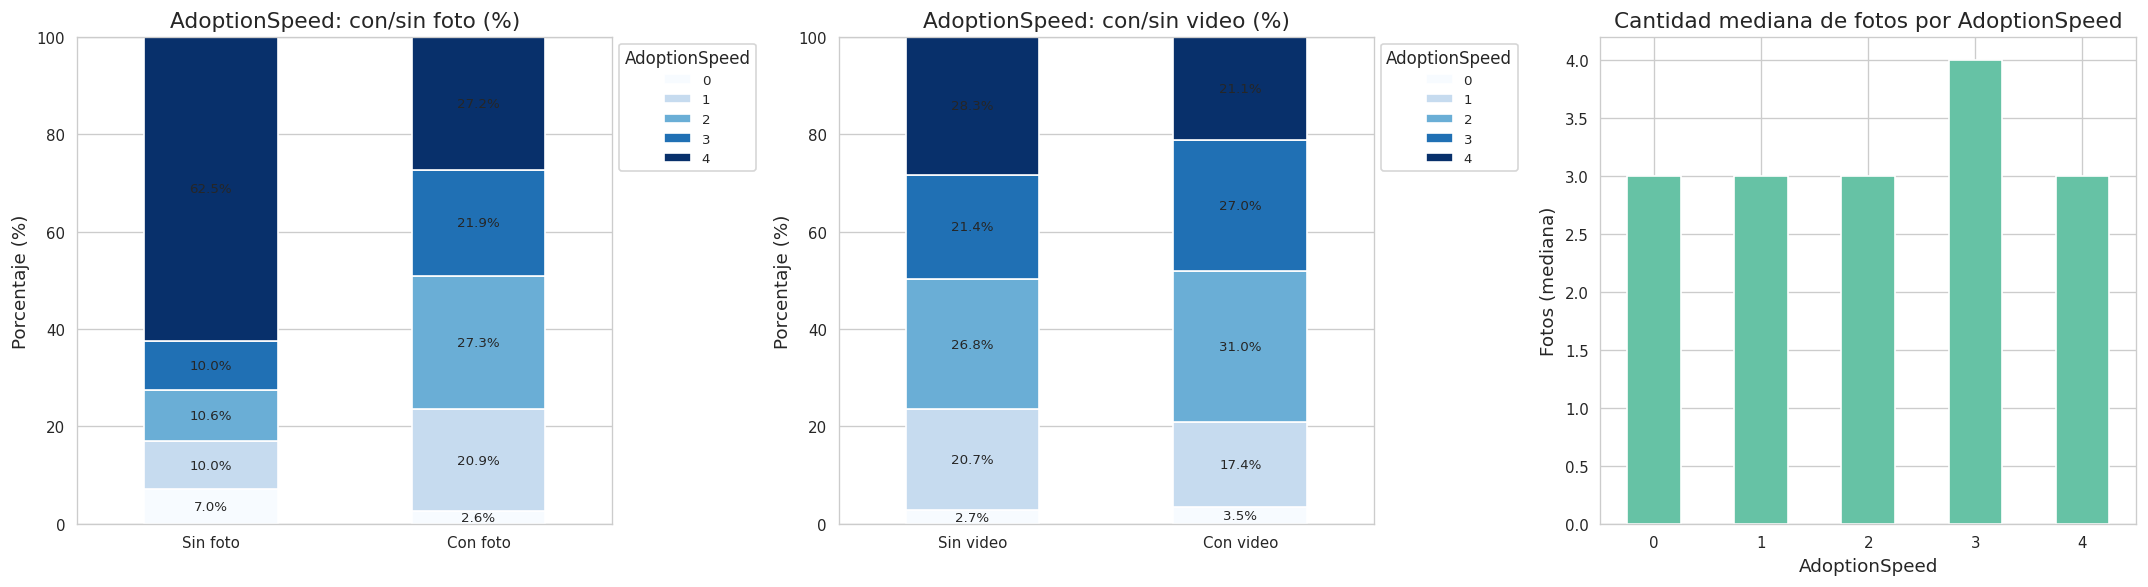

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Fotos (izquierda)
cross = df.groupby(['HasPhoto', 'AdoptionSpeed']).size().unstack(fill_value=0)
cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100
cross_pct.index = ['Sin foto', 'Con foto']

cross_pct.plot(kind='bar', stacked=True, ax=axes[0], colormap='Blues', edgecolor='white')

axes[0].set_title('AdoptionSpeed: con/sin foto (%)')
axes[0].set_ylabel('Porcentaje (%)')
axes[0].set_ylim(0, 100)
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='AdoptionSpeed', fontsize=8, loc='upper left', bbox_to_anchor=(1, 1))

for i, category in enumerate(cross_pct.index):
    cumulative = 0
    for speed in cross_pct.columns:
        pct = cross_pct.loc[category, speed]
        if pct > 0:
            axes[0].text(i, cumulative + pct/2, f'{pct:.1f}%', ha='center', va='center', fontsize=8)
        cumulative += pct

# Video (centro)
cross2 = df.groupby(['HasVideo', 'AdoptionSpeed']).size().unstack(fill_value=0)
cross2_pct = cross2.div(cross2.sum(axis=1), axis=0) * 100
cross2_pct.index = ['Sin video', 'Con video']

cross2_pct.plot(kind='bar', stacked=True, ax=axes[1], colormap='Blues', edgecolor='white')

axes[1].set_title('AdoptionSpeed: con/sin video (%)')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].set_ylim(0, 100)
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='AdoptionSpeed', fontsize=8, loc='upper left', bbox_to_anchor=(1, 1))

for i, category in enumerate(cross2_pct.index):
    cumulative = 0
    for speed in cross2_pct.columns:
        pct = cross2_pct.loc[category, speed]
        if pct > 0:
            axes[1].text(i, cumulative + pct/2, f'{pct:.1f}%', ha='center', va='center', fontsize=8)
        cumulative += pct

# Mediana fotos (derecha)
df.groupby('AdoptionSpeed')['PhotoAmt'].median().plot(
    kind='bar',
    ax=axes[2],
    edgecolor='white'
)

axes[2].set_title('Cantidad mediana de fotos por AdoptionSpeed')
axes[2].set_xlabel('AdoptionSpeed')
axes[2].set_ylabel('Fotos (mediana)')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

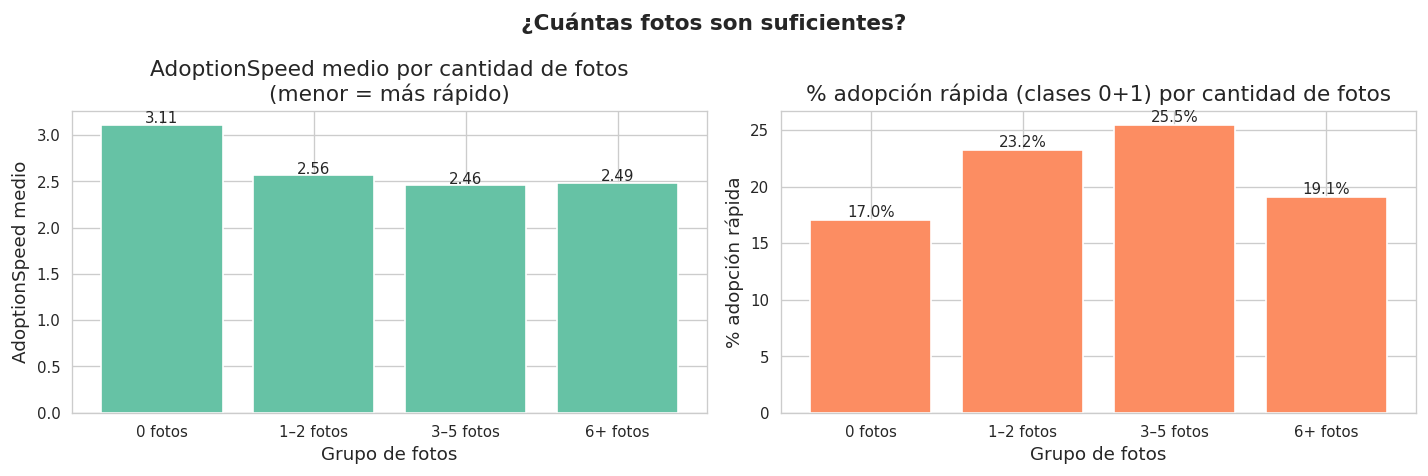

In [33]:
# ── Cuántas fotos son suficientes: PhotoAmt agrupada vs AdoptionSpeed ────────
photo_adoption = df.groupby('PhotoGroup', observed=True)['AdoptionSpeed'].mean()
photo_fast = df.groupby('PhotoGroup', observed=True)['AdoptFast'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(photo_adoption.index.astype(str), photo_adoption.values, color=PALETTE[0], edgecolor='white')
axes[0].set_title('AdoptionSpeed medio por cantidad de fotos\n(menor = más rápido)')
axes[0].set_xlabel('Grupo de fotos')
axes[0].set_ylabel('AdoptionSpeed medio')
for i, v in enumerate(photo_adoption.values):
    axes[0].text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=9)

axes[1].bar(photo_fast.index.astype(str), photo_fast.values, color=PALETTE[1], edgecolor='white')
axes[1].set_title('% adopción rápida (clases 0+1) por cantidad de fotos')
axes[1].set_xlabel('Grupo de fotos')
axes[1].set_ylabel('% adopción rápida')
for i, v in enumerate(photo_fast.values):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)

plt.suptitle('¿Cuántas fotos son suficientes?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


La ausencia de fotos se asocia fuertemente con una mayor proporción de no adopción. La presencia de video también se asocia con mejores resultados de adopción, pero número de casos es bajo.

### 4.6 Género y AdoptionSpeed

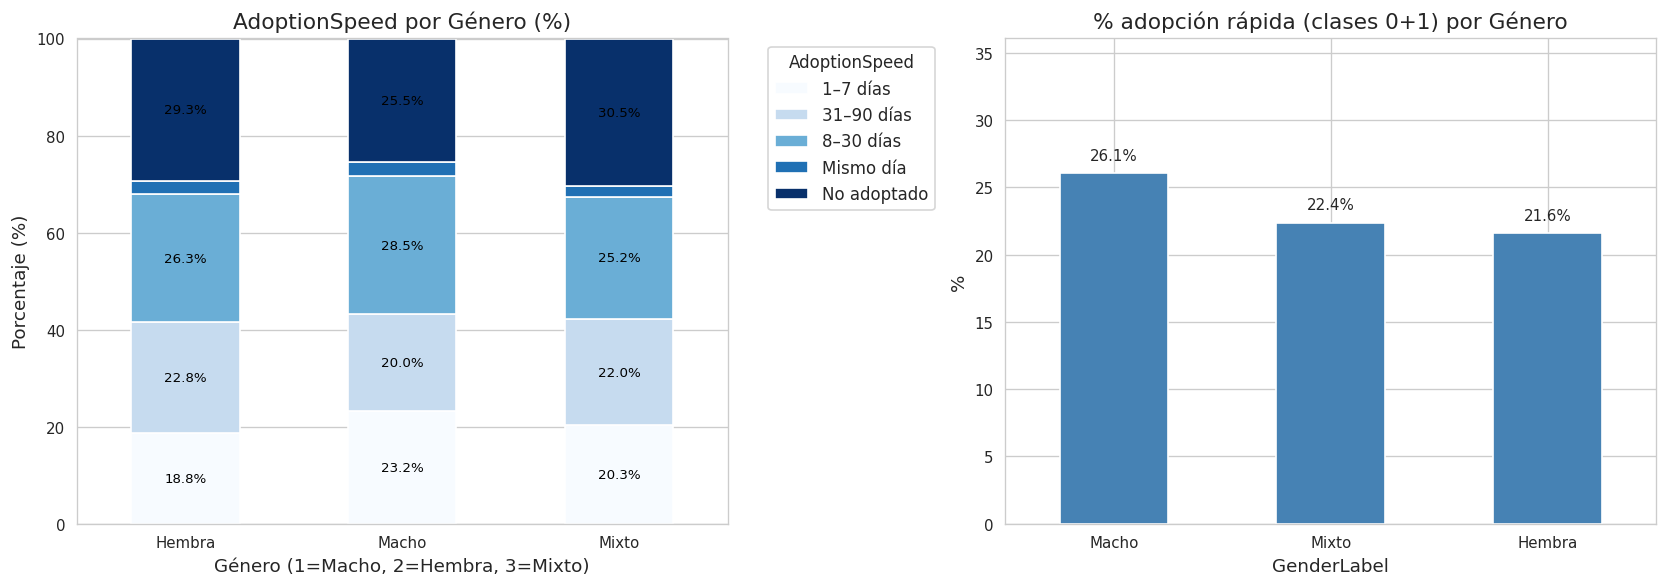

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. AdoptionSpeed por Género (izquierda)
cross = df.groupby(['GenderLabel', 'AdoptionSpeedLabel']).size().unstack(fill_value=0)
cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100

ax0 = cross_pct.plot(kind='bar', stacked=True, ax=axes[0], colormap='Blues', edgecolor='white')

for i, row in enumerate(cross_pct.values):
    acumulado = 0
    for j, val in enumerate(row):
        if val > 3:  # evitar etiquetas en segmentos muy chicos
            ax0.text(i, acumulado + val / 2, f'{val:.1f}%',
                     ha='center', va='center', fontsize=8, color='black')
        acumulado += val

axes[0].set_title('AdoptionSpeed por Género (%)')
axes[0].set_xlabel('Género (1=Macho, 2=Hembra, 3=Mixto)')
axes[0].set_ylabel('Porcentaje (%)')
axes[0].set_ylim(0, 100)
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='AdoptionSpeed', bbox_to_anchor=(1.05, 1), loc='upper left')

# Tasa de adopción rápida por Género (derecha)
rate = adoption_rate_by('GenderLabel')
ax1 = rate.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white')

for i, val in enumerate(rate.values):
    ax1.text(i, val + 1, f'{val:.1f}%', ha='center', fontsize=9)

axes[1].set_title('% adopción rápida (clases 0+1) por Género')
axes[1].set_ylabel('%')
axes[1].set_ylim(0, rate.max() + 10)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

Los machos muestran una tendencia a adoptarse más rápido.

### 4.7 Nombre, largo de nombre y AdoptionSpeed

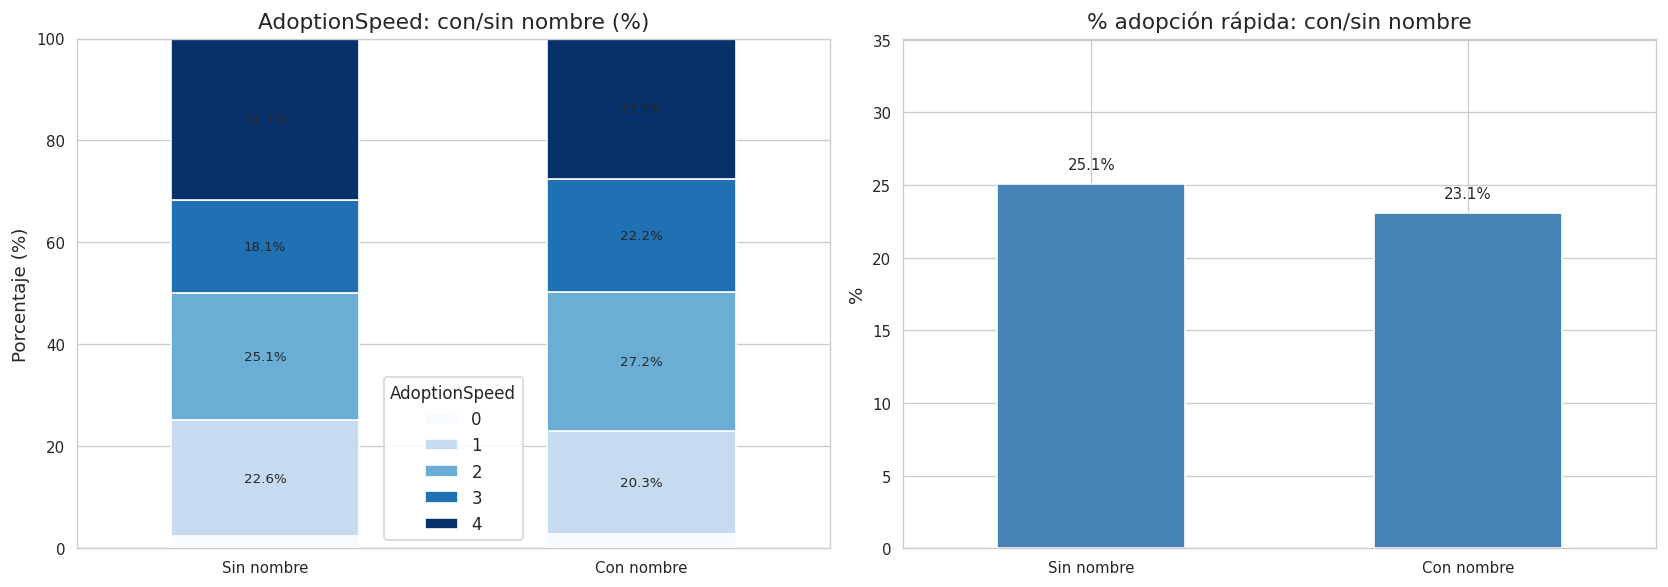

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cross = df.groupby(['HasName', 'AdoptionSpeed']).size().unstack(fill_value=0)
cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100
cross_pct.index = ['Sin nombre', 'Con nombre']

ax0 = cross_pct.plot(kind='bar', stacked=True, ax=axes[0],
                     colormap='Blues', edgecolor='white')

for i, row in enumerate(cross_pct.values):
    acumulado = 0
    for val in row:
        if val > 3:  # evita ruido visual
            ax0.text(i, acumulado + val/2, f'{val:.1f}%',
                     ha='center', va='center', fontsize=8)
        acumulado += val

axes[0].set_title('AdoptionSpeed: con/sin nombre (%)')
axes[0].set_ylabel('Porcentaje (%)')
axes[0].set_ylim(0, 100)
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='AdoptionSpeed')

rate = df.groupby('HasName')['AdoptionSpeed'].apply(
    lambda x: (x.isin([0, 1])).mean() * 100
)
rate.index = ['Sin nombre', 'Con nombre']

ax1 = rate.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white')

for i, val in enumerate(rate.values):
    ax1.text(i, val + 1, f'{val:.1f}%', ha='center', fontsize=9)

axes[1].set_title('% adopción rápida: con/sin nombre')
axes[1].set_ylabel('%')
axes[1].set_ylim(0, rate.max() + 10)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

No se observan diferencias relevantes en la velocidad de adopción entre animales con y sin nombre.

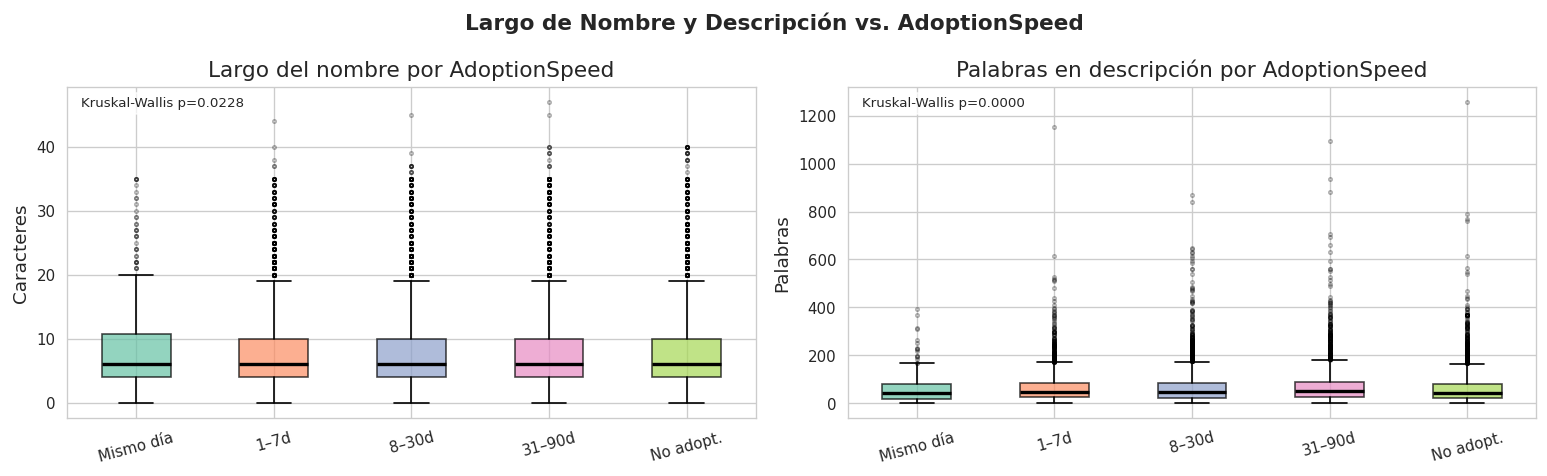

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# NameLength vs AdoptionSpeed
data_by_class_name = [df[df['AdoptionSpeed']==k]['NameLength'].dropna() for k in range(5)]
bp1 = axes[0].boxplot(data_by_class_name, patch_artist=True,
                       medianprops=dict(color='black', linewidth=2),
                       flierprops=dict(marker='o', markersize=2, alpha=0.3))
for patch, color in zip(bp1['boxes'], PALETTE):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[0].set_xticklabels(['Mismo día','1–7d','8–30d','31–90d','No adopt.'], rotation=15)
axes[0].set_title('Largo del nombre por AdoptionSpeed')
axes[0].set_ylabel('Caracteres')

# DescWordCount vs AdoptionSpeed
data_by_class_desc = [df[(df['AdoptionSpeed']==k) & (df['HasDesc']==1)]['DescWordCount'] for k in range(5)]
bp2 = axes[1].boxplot(data_by_class_desc, patch_artist=True,
                       medianprops=dict(color='black', linewidth=2),
                       flierprops=dict(marker='o', markersize=2, alpha=0.3))
for patch, color in zip(bp2['boxes'], PALETTE):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[1].set_xticklabels(['Mismo día','1–7d','8–30d','31–90d','No adopt.'], rotation=15)
axes[1].set_title('Palabras en descripción por AdoptionSpeed')
axes[1].set_ylabel('Palabras')

from scipy.stats import kruskal
stat1, p1 = kruskal(*[x for x in data_by_class_name if len(x) > 0])
stat2, p2 = kruskal(*[x for x in data_by_class_desc if len(x) > 0])
axes[0].text(0.02, 0.97, f'Kruskal-Wallis p={p1:.4f}', transform=axes[0].transAxes,
             va='top', fontsize=8, bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
axes[1].text(0.02, 0.97, f'Kruskal-Wallis p={p2:.4f}', transform=axes[1].transAxes,
             va='top', fontsize=8, bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.suptitle('Largo de Nombre y Descripción vs. AdoptionSpeed', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 4.8 Estado geográfico y AdoptionSpeed

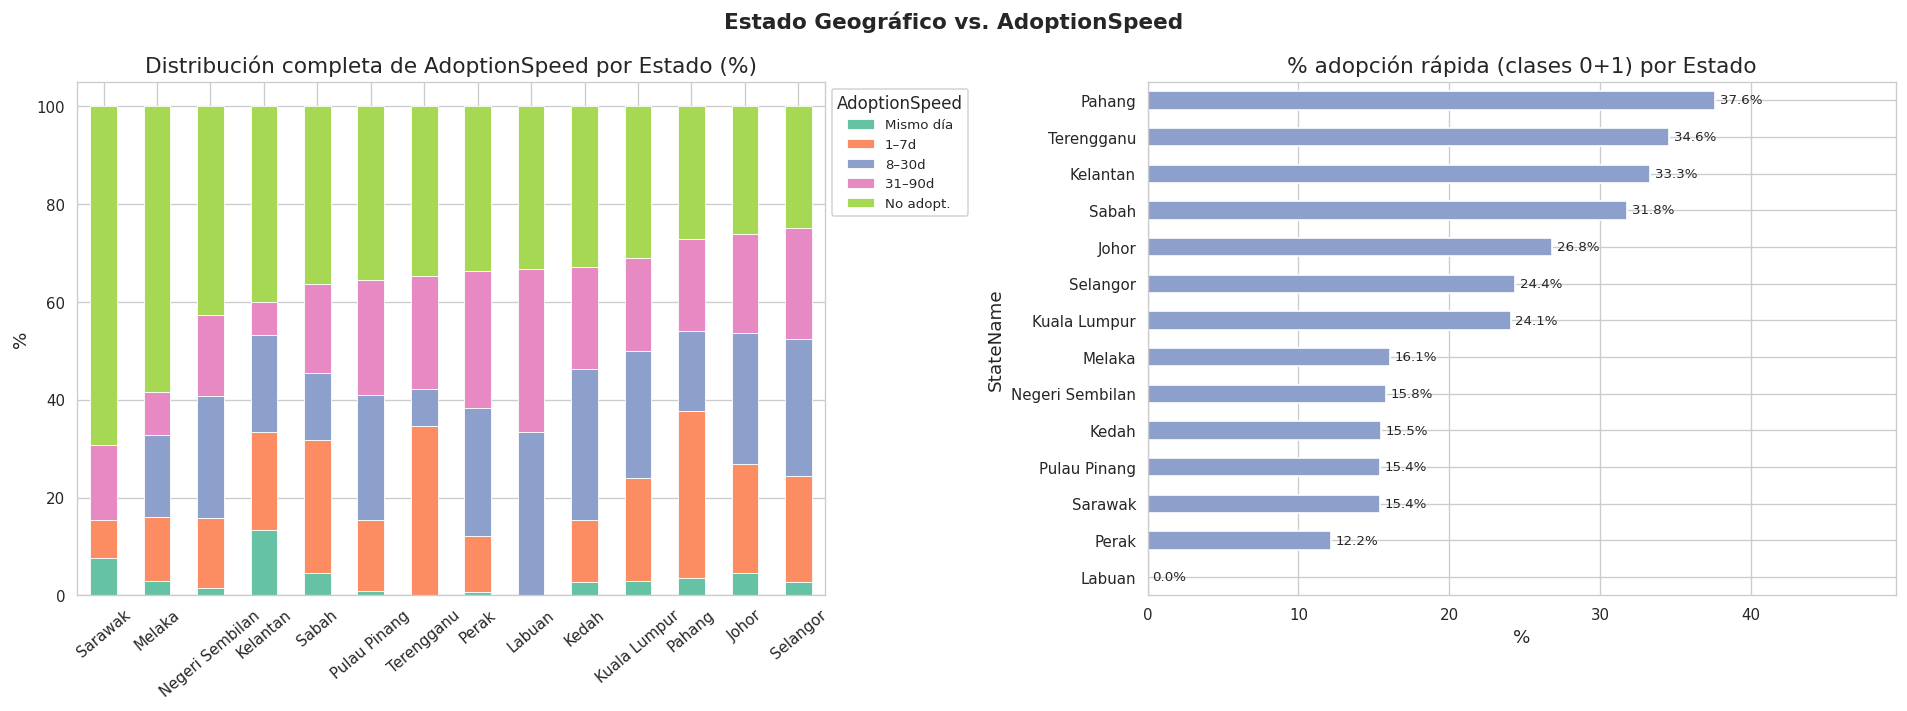

In [37]:
# Distribución completa de AdoptionSpeed por estado (stacked %)
cross_state = df.groupby(['StateName', 'AdoptionSpeed']).size().unstack(fill_value=0)
cross_state.columns = ['Mismo día','1–7d','8–30d','31–90d','No adopt.']
cross_state_pct = cross_state.div(cross_state.sum(axis=1), axis=0) * 100
# Ordenar por tasa de no adopción
cross_state_pct = cross_state_pct.sort_values('No adopt.', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cross_state_pct.plot(kind='bar', stacked=True, ax=axes[0], color=PALETTE, edgecolor='white', linewidth=0.5)
axes[0].set_title('Distribución completa de AdoptionSpeed por Estado (%)')
axes[0].set_ylabel('%')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=40)
axes[0].legend(title='AdoptionSpeed', bbox_to_anchor=(1, 1), fontsize=8)

# Tasa de adopción rápida
rate_state = adoption_rate_by('StateName').sort_values()
ax1 = rate_state.plot(kind='barh', ax=axes[1], color=PALETTE[2], edgecolor='white')
for i, val in enumerate(rate_state.values):
    axes[1].text(val + 0.3, i, f'{val:.1f}%', va='center', fontsize=8)
axes[1].set_title('% adopción rápida (clases 0+1) por Estado')
axes[1].set_xlabel('%')
axes[1].set_xlim(0, rate_state.max() + 12)

plt.suptitle('Estado Geográfico vs. AdoptionSpeed', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [38]:
# Agrupamos la población por cada categoría de velocidad
groups = [df[df['AdoptionSpeed'] == i]['StatePovertyPct'] for i in range(5)]

# Prueba de Kruskal-Wallis
stat, p_value = stats.kruskal(*groups)
print(f"Estadístico H: {stat:.4f}, p-valor: {p_value:.4e}")

if p_value < 0.05:
    print("State Poverty: Existe una diferencia estadísticamente significativa.")
else:
    print("State Poverty: No se encontró evidencia de relación significativa.")

# Agrupamos la población por cada categoría de velocidad
groups = [df[df['AdoptionSpeed'] == i]['StateIncomeAvg'] for i in range(5)]

# Prueba de Kruskal-Wallis
stat, p_value = stats.kruskal(*groups)
print(f"Estadístico H: {stat:.4f}, p-valor: {p_value:.4e}")

if p_value < 0.05:
    print("State Income: Existe una diferencia estadísticamente significativa.")
else:
    print("State Income: No se encontró evidencia de relación significativa.")


# Agrupamos la población por cada categoría de velocidad
groups = [df[df['AdoptionSpeed'] == i]['StatePop'] for i in range(5)]

# Prueba de Kruskal-Wallis
stat, p_value = stats.kruskal(*groups)
print(f"Estadístico H: {stat:.4f}, p-valor: {p_value:.4e}")

if p_value < 0.05:
    print("State Population: Existe una diferencia estadísticamente significativa.")
else:
    print("State Population: No se encontró evidencia de relación significativa.")

Estadístico H: 123.1034, p-valor: 1.1606e-25
State Poverty: Existe una diferencia estadísticamente significativa.
Estadístico H: 134.7107, p-valor: 3.8257e-28
State Income: Existe una diferencia estadísticamente significativa.
Estadístico H: 24.4801, p-valor: 6.3989e-05
State Population: Existe una diferencia estadísticamente significativa.


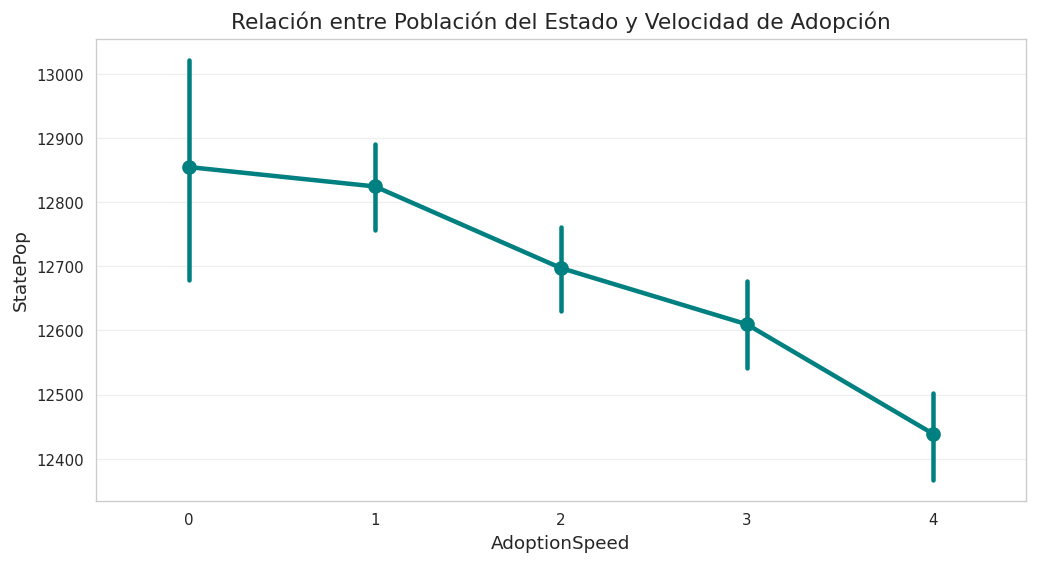

In [39]:
plt.figure(figsize=(10, 5))
sns.pointplot(x='AdoptionSpeed', y='StatePop', data=df, color='teal')
plt.title('Relación entre Población del Estado y Velocidad de Adopción')
plt.grid(axis='y', alpha=0.3)
plt.show()

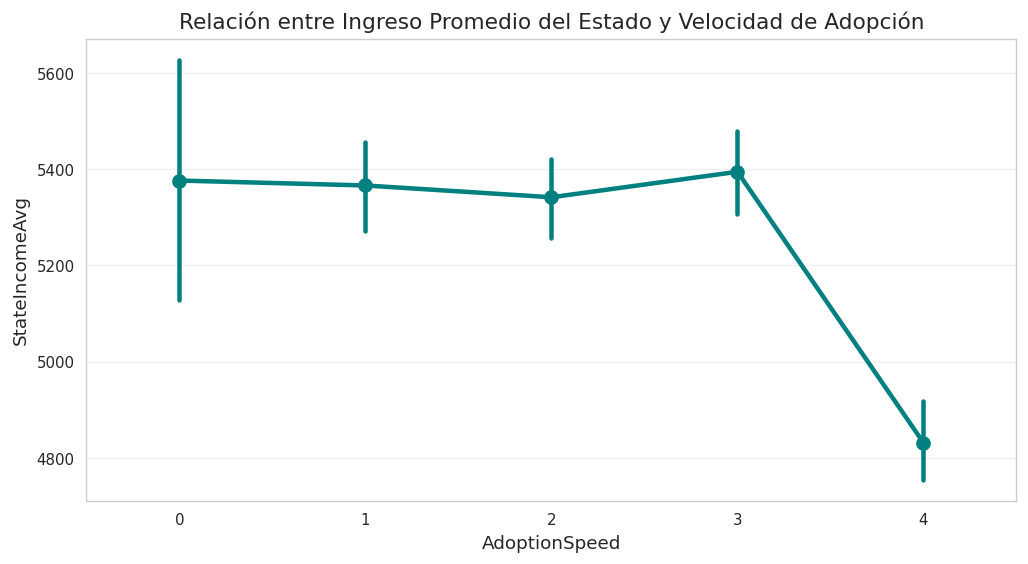

In [40]:
plt.figure(figsize=(10, 5))
sns.pointplot(x='AdoptionSpeed', y='StateIncomeAvg', data=df, color='teal')
plt.title('Relación entre Ingreso Promedio del Estado y Velocidad de Adopción')
plt.grid(axis='y', alpha=0.3)
plt.show()

Se encuentra una relación entre el ingreso promedio del Estado y la velocidad de adopción, de manera que Estados con ingresos más altos tienden a adoptar más rápido.

### 4.9 Cantidad de mascotas (Quantity) y AdoptionSpeed

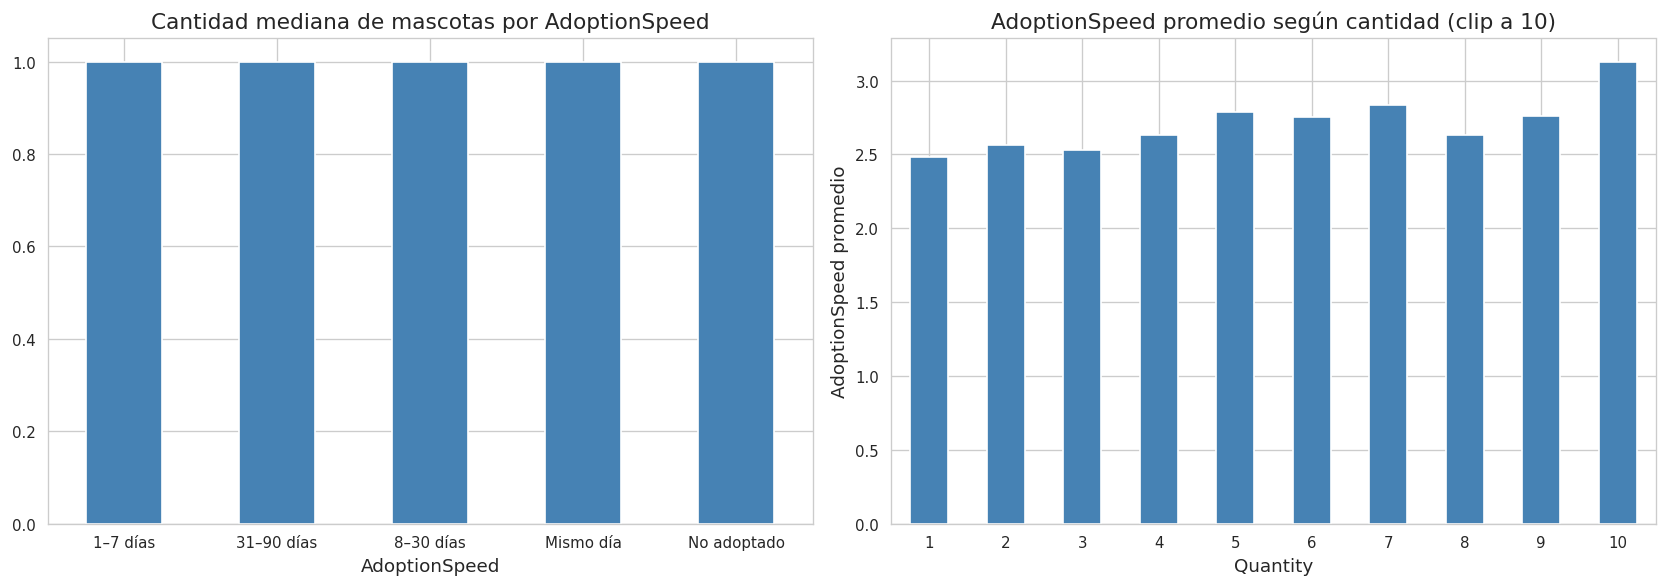

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.groupby('AdoptionSpeedLabel')['Quantity'].median().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Cantidad mediana de mascotas por AdoptionSpeed')
axes[0].set_xlabel('AdoptionSpeed')
axes[0].tick_params(axis='x', rotation=0)

# Distribución de quantity
q_clip = df['Quantity'].clip(upper=10)
q_cross = df.groupby(q_clip)['AdoptionSpeed'].mean()
q_cross.plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('AdoptionSpeed promedio según cantidad (clip a 10)')
axes[1].set_xlabel('Quantity')
axes[1].set_ylabel('AdoptionSpeed promedio')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

La mayoría de las publicaciones son de una sola mascota, independientemente del resultado de adopción. Se observa que a medida que aumenta la cantidad, la velocidad de adopción promedio también aumenta, es decir, emperora. Publicaciones con más animales tienden a tardar más en lograr adopciones rápidas.

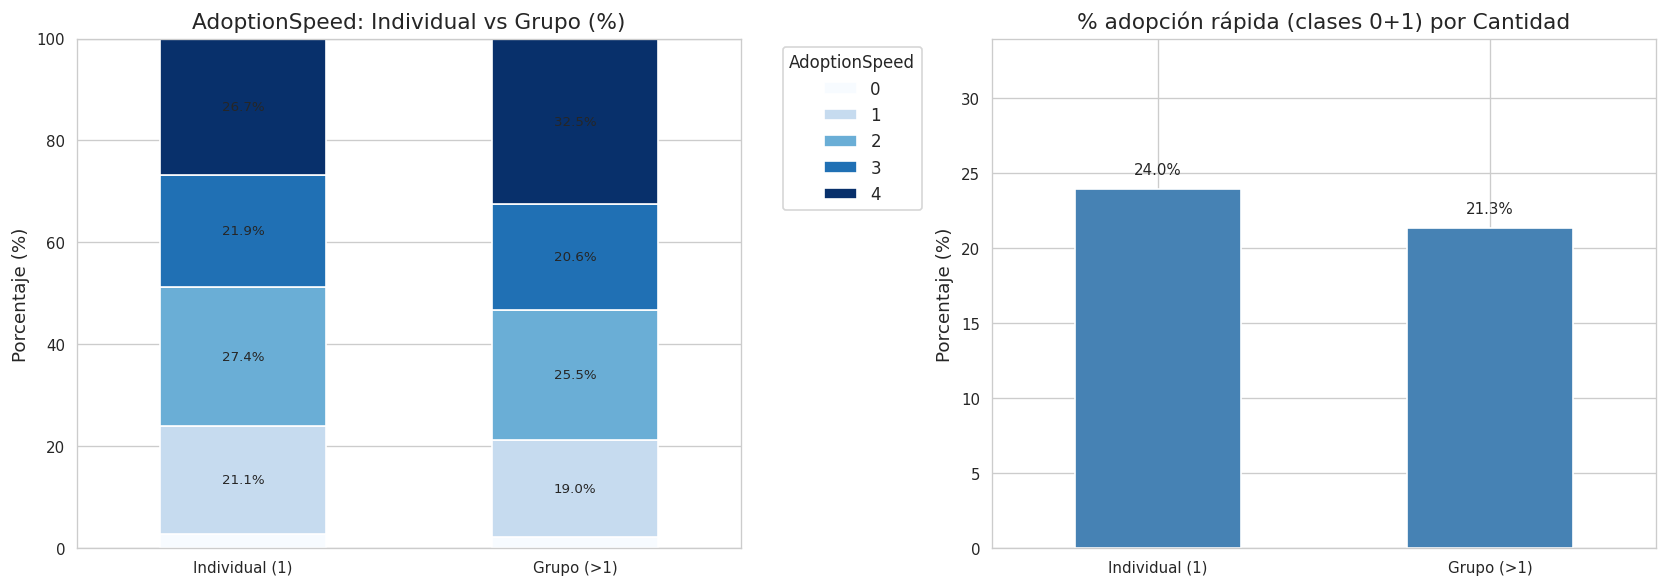

In [42]:
# 1. Crear variable dicotómica
df['IsGroup'] = (df['Quantity'] > 1).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cross = df.groupby(['IsGroup', 'AdoptionSpeed']).size().unstack(fill_value=0)
cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100
cross_pct.index = ['Individual (1)', 'Grupo (>1)']

ax0 = cross_pct.plot(kind='bar', stacked=True, ax=axes[0],
                     colormap='Blues', edgecolor='white')

for i, row in enumerate(cross_pct.values):
    acumulado = 0
    for val in row:
        if val > 3:
            ax0.text(i, acumulado + val/2, f'{val:.1f}%',
                     ha='center', va='center', fontsize=8)
        acumulado += val

axes[0].set_title('AdoptionSpeed: Individual vs Grupo (%)')
axes[0].set_ylabel('Porcentaje (%)')
axes[0].set_ylim(0, 100)
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='AdoptionSpeed', bbox_to_anchor=(1.05, 1), loc='upper left')

rate = df.groupby('IsGroup')['AdoptionSpeed'].apply(
    lambda x: (x.isin([0, 1])).mean() * 100
)
rate.index = ['Individual (1)', 'Grupo (>1)']

ax1 = rate.plot(kind='bar', ax=axes[1],
                color='steelblue', edgecolor='white')

for i, val in enumerate(rate.values):
    ax1.text(i, val + 1, f'{val:.1f}%', ha='center', fontsize=9)

axes[1].set_title('% adopción rápida (clases 0+1) por Cantidad')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].set_ylim(0, rate.max() + 10)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

Se observa una mayor proporción de adopción rápida en casos de un sólo animal, concentrándose más las adopciones lentas en las grupales.

### 4.10 Raza mixta y AdoptionSpeed

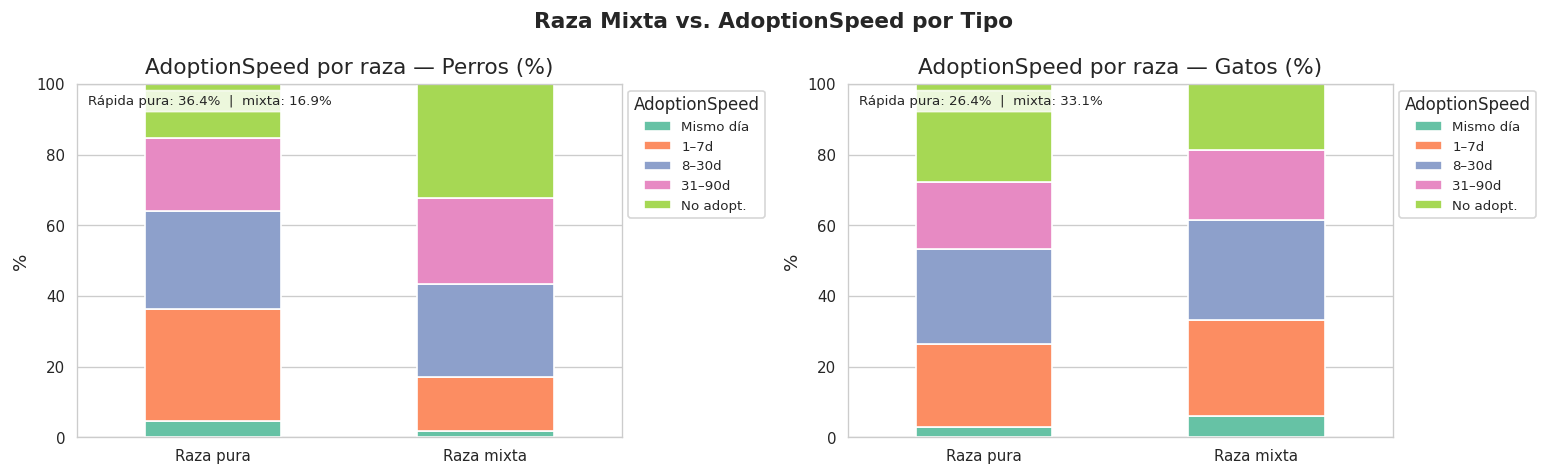

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax_idx, (type_val, label) in enumerate([(1,'Perros'), (2,'Gatos')]):
    ax = axes[ax_idx]
    subset = df[df['Type'] == type_val]
    cross = subset.groupby(['MixedBreed', 'AdoptionSpeed']).size().unstack(fill_value=0)
    cross.columns = ['Mismo día','1–7d','8–30d','31–90d','No adopt.']
    cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100
    cross_pct.index = ['Raza pura', 'Raza mixta']
    cross_pct.plot(kind='bar', stacked=True, ax=ax, color=PALETTE, edgecolor='white')
    ax.set_title(f'AdoptionSpeed por raza — {label} (%)')
    ax.set_ylabel('%')
    ax.set_ylim(0, 100)
    ax.tick_params(axis='x', rotation=0)
    ax.legend(title='AdoptionSpeed', bbox_to_anchor=(1, 1), fontsize=8)
    rate_pure = subset[subset['MixedBreed']==0]['AdoptFast'].mean()*100
    rate_mix  = subset[subset['MixedBreed']==1]['AdoptFast'].mean()*100
    ax.text(0.02, 0.97, f'Rápida pura: {rate_pure:.1f}%  |  mixta: {rate_mix:.1f}%',
            transform=ax.transAxes, va='top', fontsize=8,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Raza Mixta vs. AdoptionSpeed por Tipo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 4.11 Color mixto y AdoptionSpeed

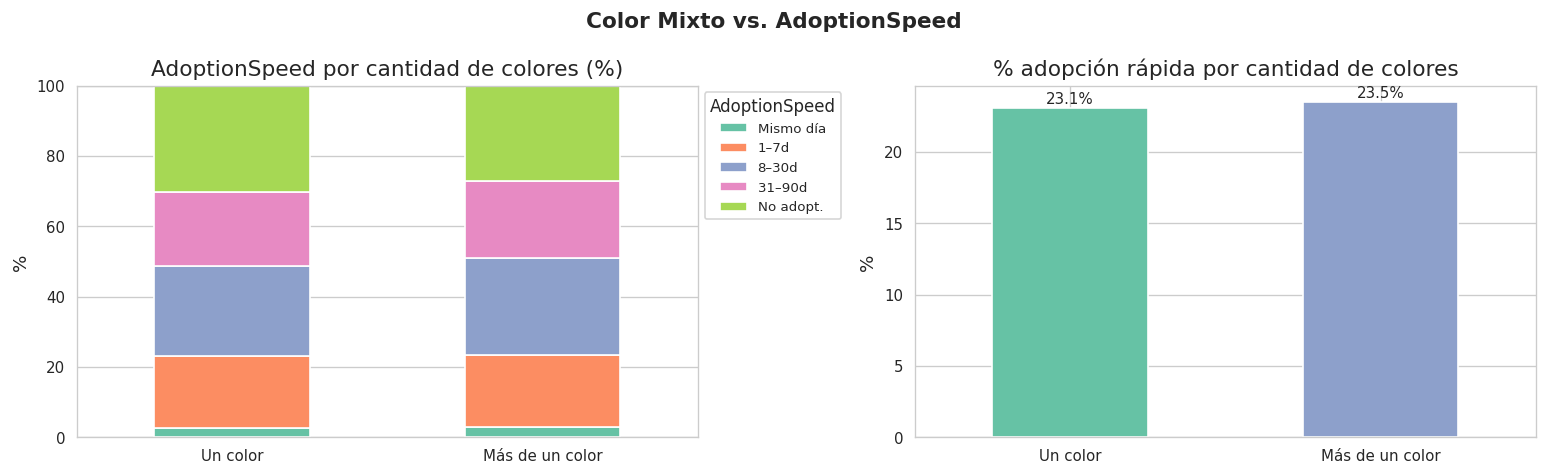

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

cross_col = df.groupby(['MixedColor', 'AdoptionSpeed']).size().unstack(fill_value=0)
cross_col.columns = ['Mismo día','1–7d','8–30d','31–90d','No adopt.']
cross_col_pct = cross_col.div(cross_col.sum(axis=1), axis=0) * 100
cross_col_pct.index = ['Un color', 'Más de un color']

cross_col_pct.plot(kind='bar', stacked=True, ax=axes[0], color=PALETTE, edgecolor='white')
axes[0].set_title('AdoptionSpeed por cantidad de colores (%)')
axes[0].set_ylabel('%'); axes[0].set_ylim(0, 100)
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='AdoptionSpeed', bbox_to_anchor=(1,1), fontsize=8)

rate_col = df.groupby('MixedColor')['AdoptFast'].mean() * 100
rate_col.index = ['Un color', 'Más de un color']
rate_col.plot(kind='bar', ax=axes[1], color=[PALETTE[0], PALETTE[2]], edgecolor='white')
axes[1].set_title('% adopción rápida por cantidad de colores')
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(rate_col.values):
    axes[1].text(i, v+0.3, f'{v:.1f}%', ha='center', fontsize=9)

plt.suptitle('Color Mixto vs. AdoptionSpeed', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 4.12 Razas más frecuentes vs. AdoptionSpeed

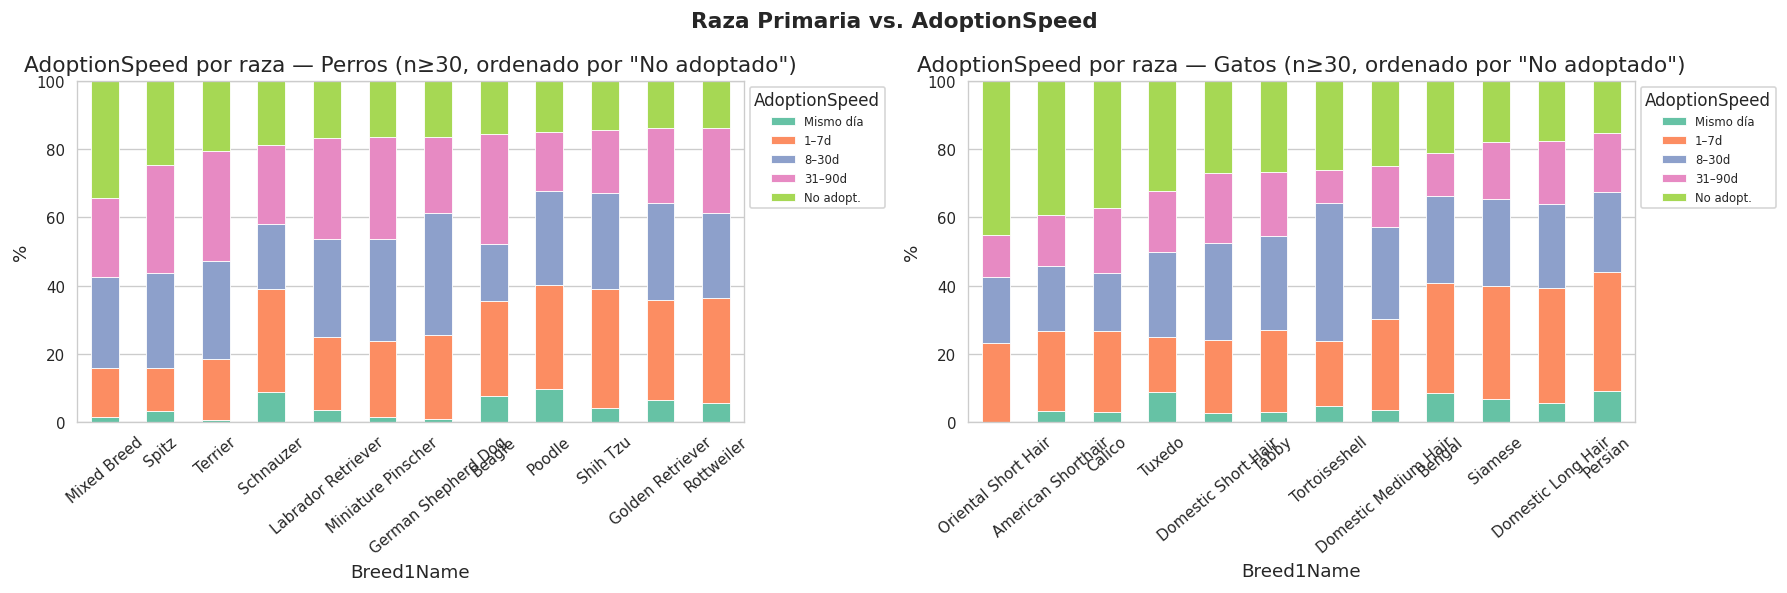

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, type_val, label in zip(axes, [1, 2], ['Perros', 'Gatos']):
    subset = df[df['Type'] == type_val]
    top_breeds = subset['Breed1Name'].value_counts()
    top_breeds = top_breeds[top_breeds >= 30].head(12).index
    sub = subset[subset['Breed1Name'].isin(top_breeds)]
    
    ct = pd.crosstab(sub['Breed1Name'], sub['AdoptionSpeed'])
    ct.columns = ['Mismo día','1–7d','8–30d','31–90d','No adopt.']
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct = ct_pct.sort_values('No adopt.', ascending=False)
    
    ct_pct.plot(kind='bar', stacked=True, ax=ax, color=PALETTE, edgecolor='white', linewidth=0.5)
    ax.set_title(f'AdoptionSpeed por raza — {label} (n≥30, ordenado por "No adoptado")')
    ax.set_ylabel('%'); ax.set_ylim(0, 100)
    ax.tick_params(axis='x', rotation=40)
    ax.legend(title='AdoptionSpeed', bbox_to_anchor=(1, 1), fontsize=7)

plt.suptitle('Raza Primaria vs. AdoptionSpeed', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 4.13 RescuerFrequency y AdoptionSpeed

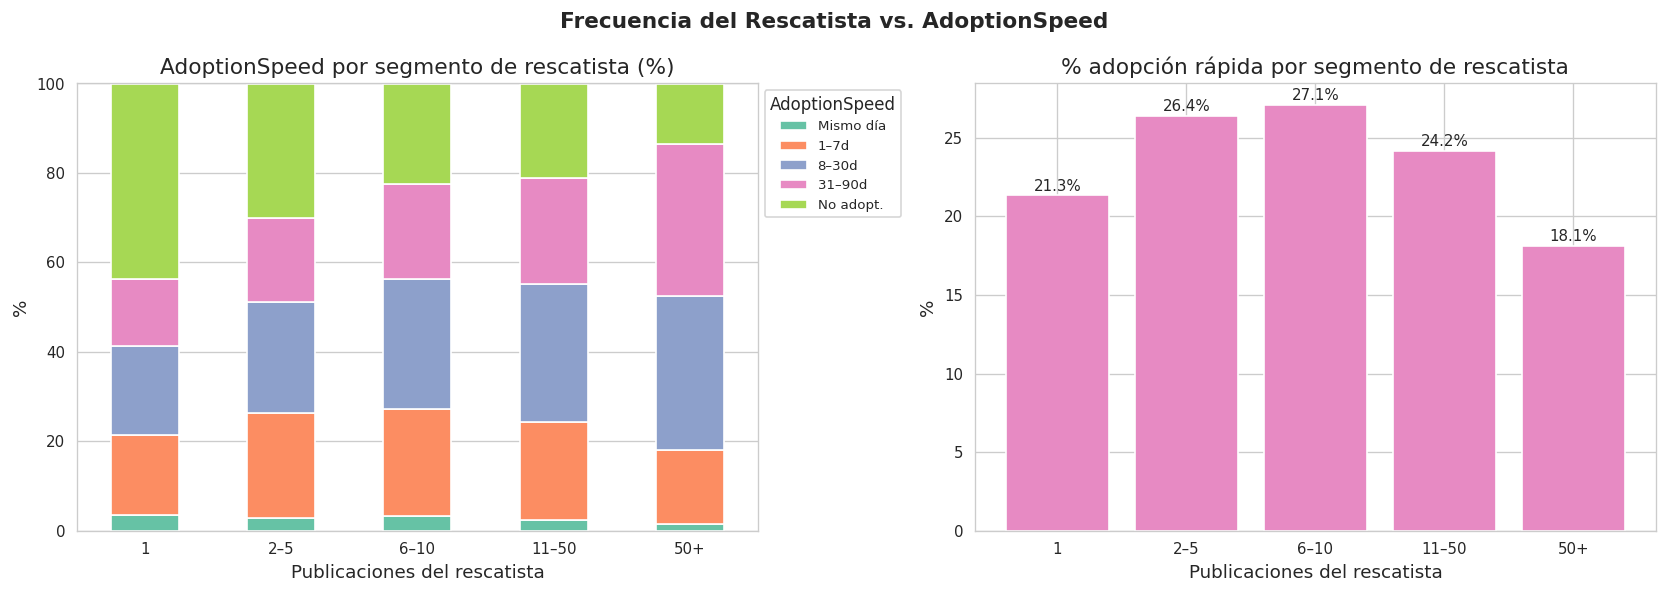

In [46]:
# Segmentar rescatistas por volumen
bins_r  = [0, 1, 5, 10, 50, df['RescuerFrequency'].max()+1]
labels_r = ['1', '2–5', '6–10', '11–50', '50+']
df['RescuerSegment'] = pd.cut(df['RescuerFrequency'], bins=bins_r, labels=labels_r)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar: AdoptionSpeed por segmento
cross_r = df.groupby(['RescuerSegment', 'AdoptionSpeed'], observed=True).size().unstack(fill_value=0)
cross_r.columns = ['Mismo día','1–7d','8–30d','31–90d','No adopt.']
cross_r_pct = cross_r.div(cross_r.sum(axis=1), axis=0) * 100
cross_r_pct.plot(kind='bar', stacked=True, ax=axes[0], color=PALETTE, edgecolor='white')
axes[0].set_title('AdoptionSpeed por segmento de rescatista (%)')
axes[0].set_xlabel('Publicaciones del rescatista'); axes[0].set_ylabel('%')
axes[0].set_ylim(0, 100); axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='AdoptionSpeed', bbox_to_anchor=(1,1), fontsize=8)

# Tasa de adopción rápida por segmento
rate_r = df.groupby('RescuerSegment', observed=True)['AdoptFast'].mean() * 100
axes[1].bar(rate_r.index.astype(str), rate_r.values, color=PALETTE[3], edgecolor='white')
axes[1].set_title('% adopción rápida por segmento de rescatista')
axes[1].set_xlabel('Publicaciones del rescatista'); axes[1].set_ylabel('%')
for i, v in enumerate(rate_r.values):
    axes[1].text(i, v+0.3, f'{v:.1f}%', ha='center', fontsize=9)

plt.suptitle('Frecuencia del Rescatista vs. AdoptionSpeed', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


Rescatistas con ≥10 publicaciones: 200
Tasa media de adopción rápida: 25.0%
Desv. estándar: 19.9% → varianza real entre rescatistas


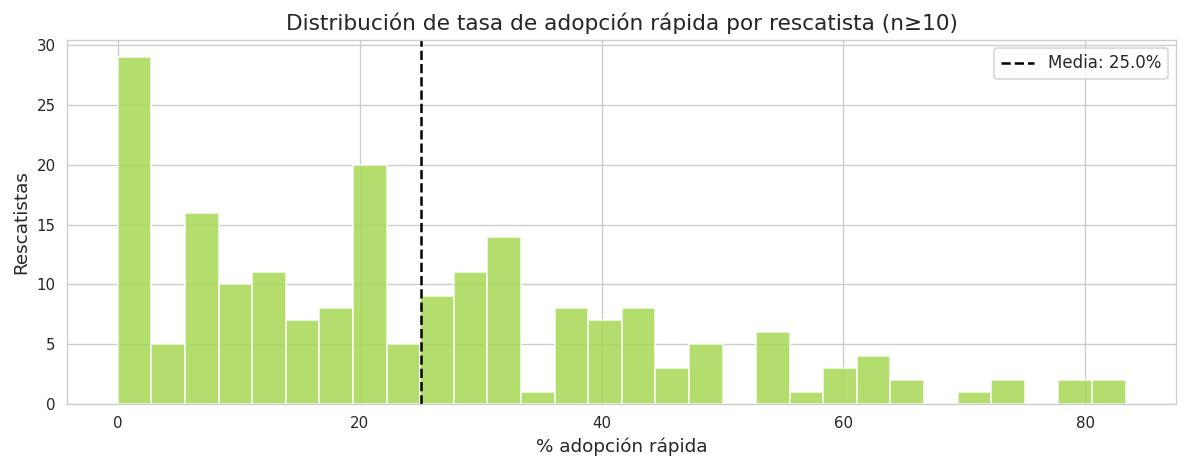

In [47]:
# ¿Hay rescatistas con track record sistemáticamente mejor?
rescuer_stats = (df[df['RescuerFrequency'] >= 10]
                 .groupby('RescuerID')
                 .agg(
                     n_pets       = ('PetID', 'count'),
                     fast_rate    = ('AdoptFast', 'mean'),
                     avg_speed    = ('AdoptionSpeed', 'mean')
                 )
                 .sort_values('fast_rate', ascending=False))

rescuer_stats['fast_rate_pct'] = rescuer_stats['fast_rate'] * 100

print(f'Rescatistas con ≥10 publicaciones: {len(rescuer_stats)}')
print(f'Tasa media de adopción rápida: {rescuer_stats["fast_rate_pct"].mean():.1f}%')
print(f'Desv. estándar: {rescuer_stats["fast_rate_pct"].std():.1f}% → varianza real entre rescatistas')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(rescuer_stats['fast_rate_pct'], bins=30, color=PALETTE[4], edgecolor='white', alpha=0.85)
ax.axvline(rescuer_stats['fast_rate_pct'].mean(), color='black', linestyle='--', linewidth=1.5,
           label=f'Media: {rescuer_stats["fast_rate_pct"].mean():.1f}%')
ax.set_title('Distribución de tasa de adopción rápida por rescatista (n≥10)')
ax.set_xlabel('% adopción rápida'); ax.set_ylabel('Rescatistas')
ax.legend()
plt.tight_layout()
plt.show()


La varianza entre rescatistas justifica el uso de **target encoding de `RescuerID`** en la etapa de Feature Engineering.

### 4.14 Texto: palabras clave y lenguaje en Description

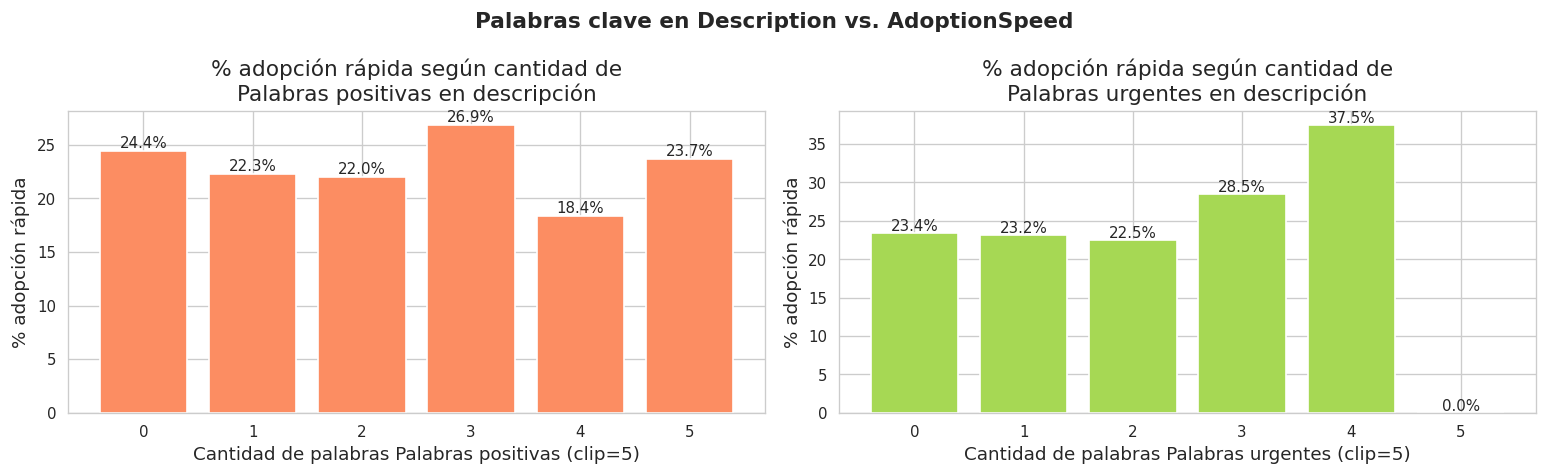

In [48]:
# ── Palabras clave en Description ─────────────────────────────────────────────
keywords_positive = ['playful', 'friendly', 'loves', 'gentle', 'sweet', 'healthy',
                     'vaccinated', 'trained', 'house', 'good']
keywords_urgent   = ['urgent', 'please', 'help', 'desperate', 'danger', 'kill',
                     'euthanasia', 'last', 'deadline', 'dying']

desc_lower = df['Description'].fillna('').str.lower()

for kw_list, label, color in [
    (keywords_positive, 'positivas', PALETTE[1]),
    (keywords_urgent,   'urgentes',  PALETTE[4])
]:
    df[f'kw_{label}'] = desc_lower.apply(
        lambda x: sum(kw in x for kw in kw_list)
    )

# Tasa de adopción rápida según presencia de palabras positivas/urgentes
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col, label, color in [
    (axes[0], 'kw_positivas', 'Palabras positivas', PALETTE[1]),
    (axes[1], 'kw_urgentes',  'Palabras urgentes',  PALETTE[4])
]:
    clip_val = df[col].clip(upper=5)
    rate = df.groupby(clip_val)['AdoptFast'].mean() * 100
    ax.bar(rate.index.astype(str), rate.values, color=color, edgecolor='white')
    ax.set_title(f'% adopción rápida según cantidad de\n{label} en descripción')
    ax.set_xlabel(f'Cantidad de palabras {label} (clip=5)')
    ax.set_ylabel('% adopción rápida')
    for i, v in enumerate(rate.values):
        ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)

plt.suptitle('Palabras clave en Description vs. AdoptionSpeed', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


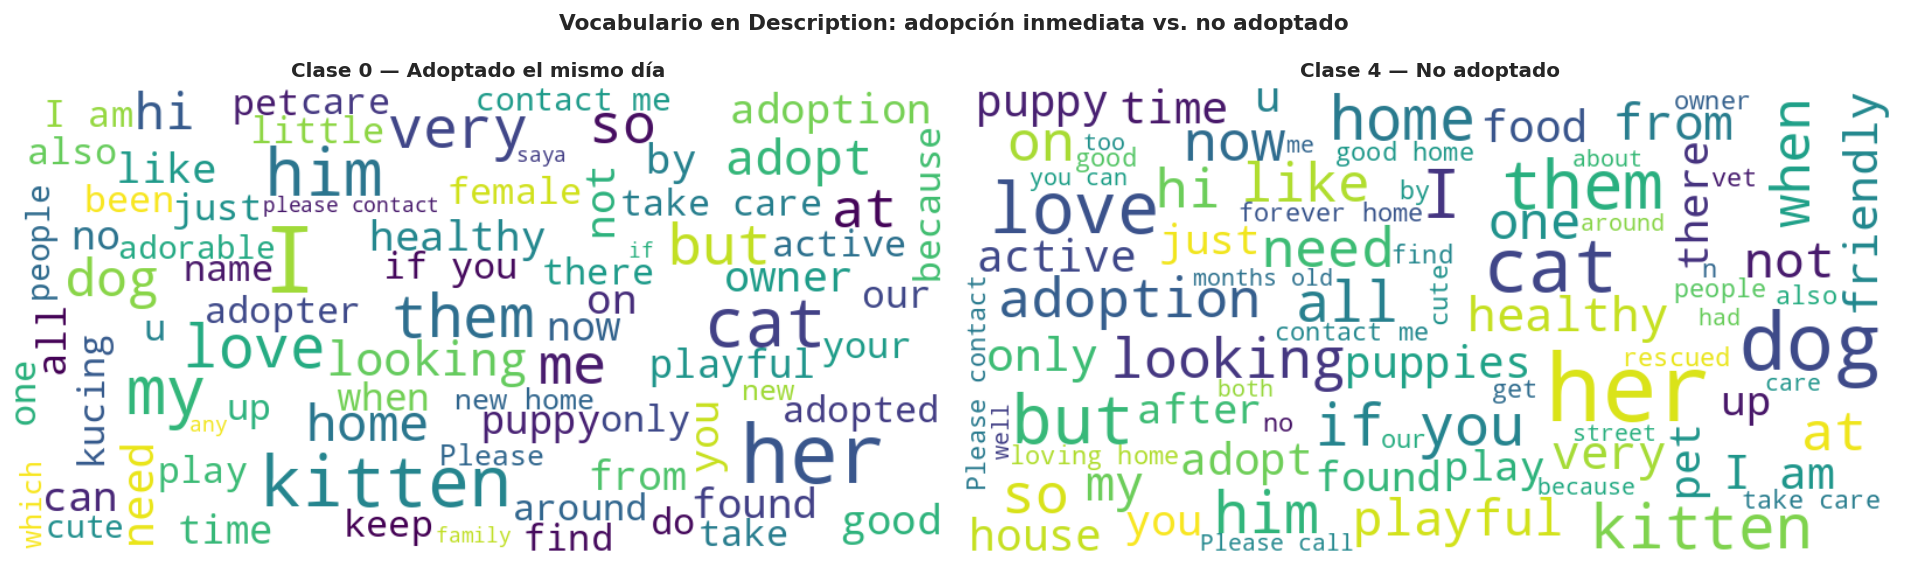

In [49]:
# ── Wordcloud: clase 0 (adoptados el mismo día) vs clase 4 (no adoptados) ──────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, clase, titulo in [(axes[0], 0, 'Clase 0 — Adoptado el mismo día'),
                           (axes[1], 4, 'Clase 4 — No adoptado')]:
    text = ' '.join(df[df['AdoptionSpeed'] == clase]['Description'].dropna().values)
    if text.strip():
        wc = WordCloud(max_font_size=80, background_color='white',
                       width=800, height=400, max_words=80,
                       stopwords={'the','a','and','is','in','of','to','for','this',
                                  'with','that','it','will','be','are','was','an',
                                  'has','have','she','he','they','we','or','as',
                                  'yang','di','dan','is','nya','ini'}).generate(text)
        ax.imshow(wc, interpolation='bilinear')
        ax.set_title(titulo, fontsize=12, fontweight='bold')
        ax.axis('off')

plt.suptitle('Vocabulario en Description: adopción inmediata vs. no adoptado', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 4.15 Resumen de asociación categórica con target (Chi-cuadrado + V de Cramér)

In [50]:
from scipy.stats import chi2_contingency

chi_results = []
cat_cols = ['TypeLabel', 
       'GenderLabel', 'MaturitySizeLabel', 'FurLengthLabel', 'VaccinatedLabel',
       'DewormedLabel', 'SterilizedLabel', 'HealthLabel', 
       'HasName', 'HasDesc', 'HasPhoto', 'HasVideo', 
       'IsFree', 'MixedColor', 'MixedBreed','IsGroup']

for col in cat_cols:
    
    tmp = df[[col, "AdoptionSpeedLabel"]].dropna()
    
    # Evitar variables con un solo nivel
    if tmp[col].nunique() < 2:
        continue
    
    table = pd.crosstab(tmp[col], tmp["AdoptionSpeedLabel"])
    
    # Evitar tablas muy chicas o problemáticas
    if table.shape[0] < 2 or table.shape[1] < 2:
        continue
    
    chi2, pval, dof, expected = chi2_contingency(table)
    
    # Calcular V de Cramér (tamaño de efecto)
    n = table.sum().sum()
    r, k = table.shape
    cramers_v = np.sqrt(chi2 / (n * (min(r-1, k-1))))
    
    chi_results.append({
        "variable": col,
        "chi2": chi2,
        "p_value": pval,
        "cramers_v": cramers_v,
        "degrees_freedom": dof,
        "levels": tmp[col].nunique(),
        "n": n
    })

chi_df = pd.DataFrame(chi_results).sort_values("p_value")

chi_df

,variable,chi2,p_value,cramers_v,degrees_freedom,levels,n
6,SterilizedLabel,788.126439,7.453755e-165,0.162354,8,3,14950
4,VaccinatedLabel,286.678973,2.808789e-57,0.097918,8,3,14950
10,HasPhoto,246.914479,3.007615e-52,0.128515,4,2,14950
14,MixedBreed,180.370166,6.209261e-38,0.109840,4,2,14950
3,FurLengthLabel,177.299470,3.798117e-34,0.077005,8,3,14950
0,TypeLabel,160.208205,1.319086e-33,0.103519,4,2,14950
5,DewormedLabel,147.675832,5.984790e-28,0.070278,8,3,14950
2,MaturitySizeLabel,152.132698,2.092653e-26,0.058241,12,4,14950
1,GenderLabel,75.137049,4.630576e-13,0.050129,8,3,14950
15,IsGroup,46.296277,2.136854e-09,0.055648,4,2,14950


Todas las variables muestran asociación significativa (p < 0.05), explicada probablemente por el tamaño muestral. Los valores de V de Cramér indican que las asociaciones son en general débiles, siendo las más relevantes si el animal está esterilizado (Sterilized), tiene foto (HasPhoto) y está vacunado (Vaccinated).

---
## 5. Análisis Multivariado

### 5.1 Matriz de correlación de Spearman (variables numéricas)

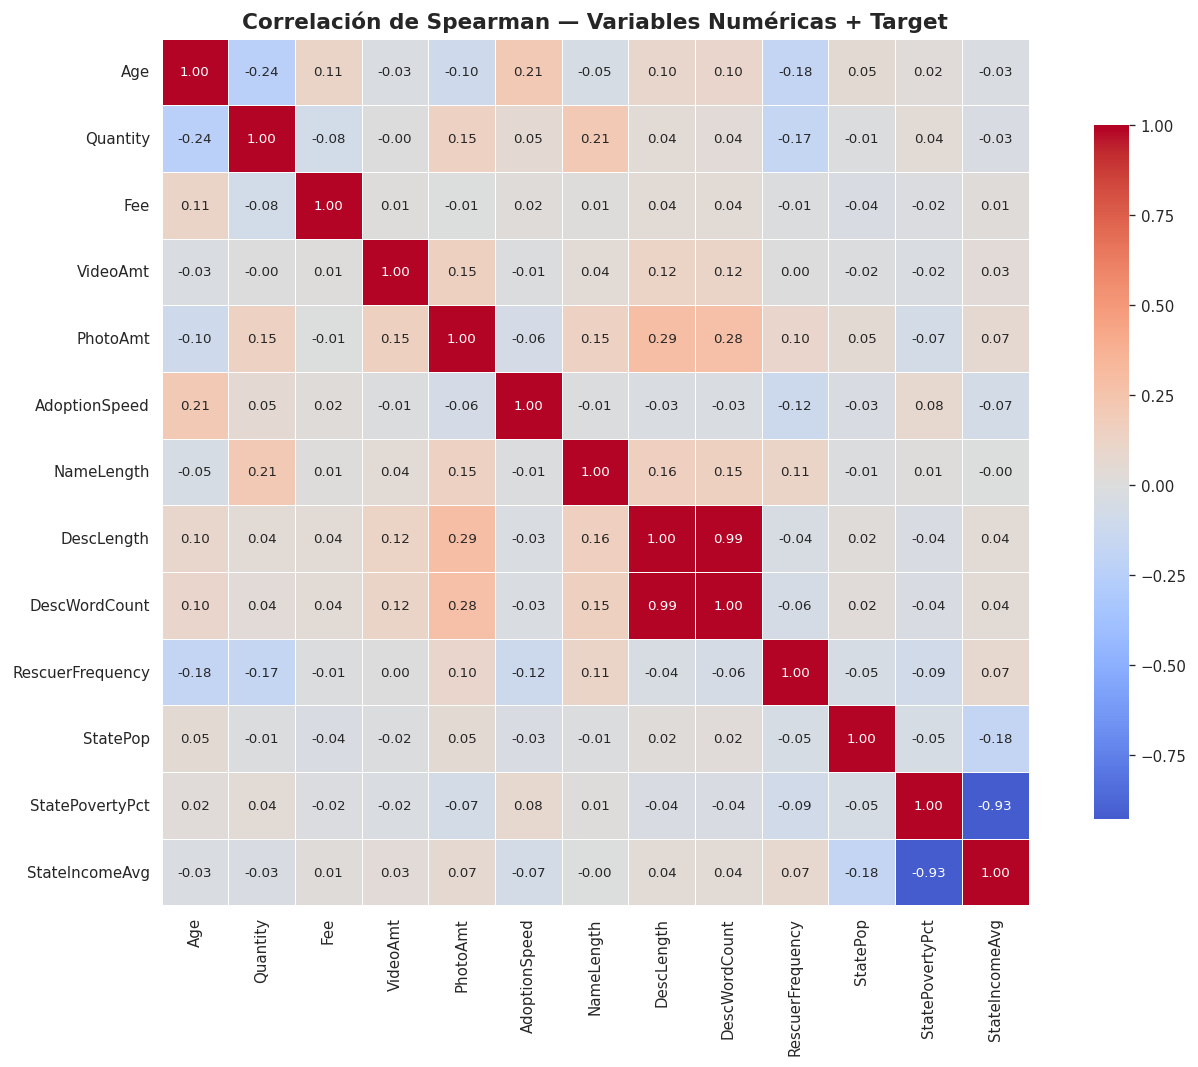


Correlación con AdoptionSpeed (ordenada):
RescuerFrequency   -0.118
StateIncomeAvg     -0.074
PhotoAmt           -0.062
StatePop           -0.032
DescLength         -0.030
DescWordCount      -0.028
VideoAmt           -0.011
NameLength         -0.009
Fee                 0.019
Quantity            0.053
StatePovertyPct     0.076
Age                 0.210


In [51]:
df['AdoptionSpeed'] = pd.to_numeric(df['AdoptionSpeed'], errors='coerce')

num_cols = ['Age', 'Quantity', 'Fee', 'VideoAmt', 'PhotoAmt', 'AdoptionSpeed',
            'NameLength', 'DescLength', 'DescWordCount', 'RescuerFrequency',
            'StatePop', 'StatePovertyPct', 'StateIncomeAvg']

corr = df[num_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 8})
ax.set_title('Correlación de Spearman — Variables Numéricas + Target', fontweight='bold')
plt.tight_layout()
plt.show()

print('\nCorrelación con AdoptionSpeed (ordenada):')
print(corr['AdoptionSpeed'].drop('AdoptionSpeed').sort_values().round(3).to_string())


*  La variable que presenta mayor asociación con la velocidad de adopción es la edad, indicando que los animales más grandes tienden a ser adoptados más lentamente.
* La edad también está relacionada con la cantidad de animales por publicación: los animales más jóvenes suelen aparecer en publicaciones con mayor número de individuos. 
* El resto de las variables analizadas muestran asociaciones débiles.

### 5.2 Tipo de animal × Edad × AdoptionSpeed

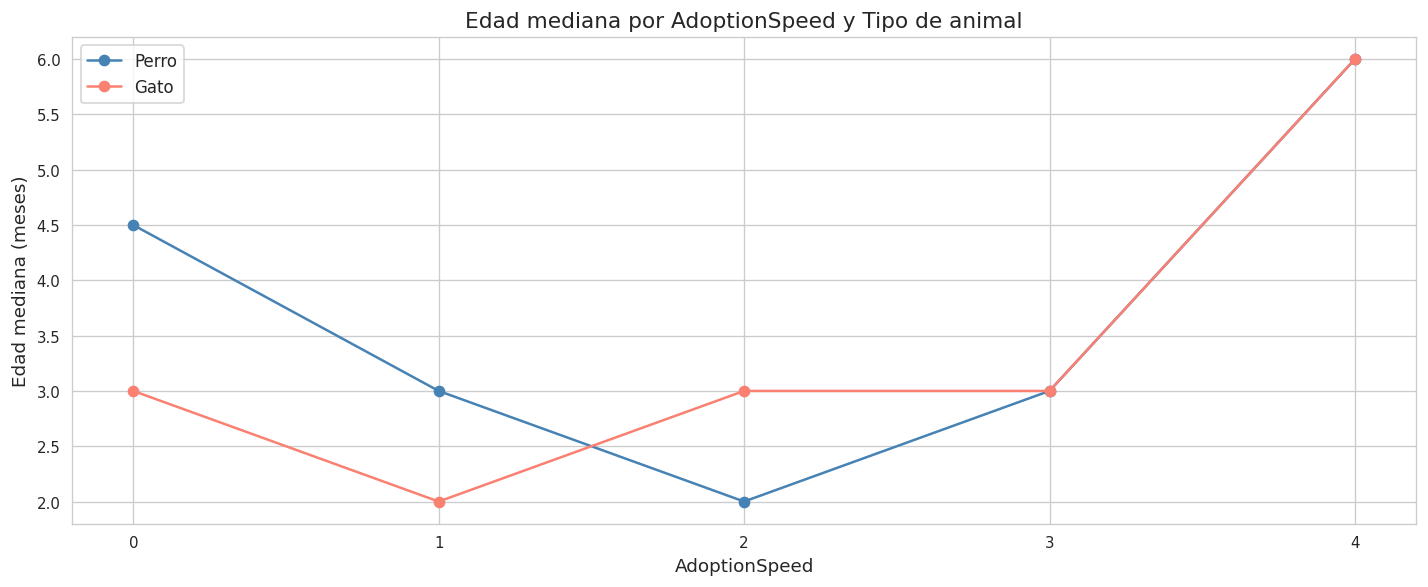

In [52]:
plt.figure(figsize=(12, 5))
for tipo, color in [('Perro', 'steelblue'), ('Gato', 'salmon')]:
    subset = df[df['TypeLabel'] == tipo]
    mean_age = subset.groupby('AdoptionSpeed')['Age'].median()
    plt.plot(mean_age.index, mean_age.values, marker='o', label=tipo, color=color)

plt.title('Edad mediana por AdoptionSpeed y Tipo de animal')
plt.xlabel('AdoptionSpeed')
plt.ylabel('Edad mediana (meses)')
plt.xticks([0, 1, 2, 3, 4])
plt.legend()
plt.tight_layout()
plt.show()

La edad impacta en la adopción en ambos tipos de animales, pero el efecto es más pronunciado en gatos, donde los de mayor edad presentan una mayor probabilidad de no ser adoptados.

### 5.3 Tipo × Variables de salud × AdoptionSpeed

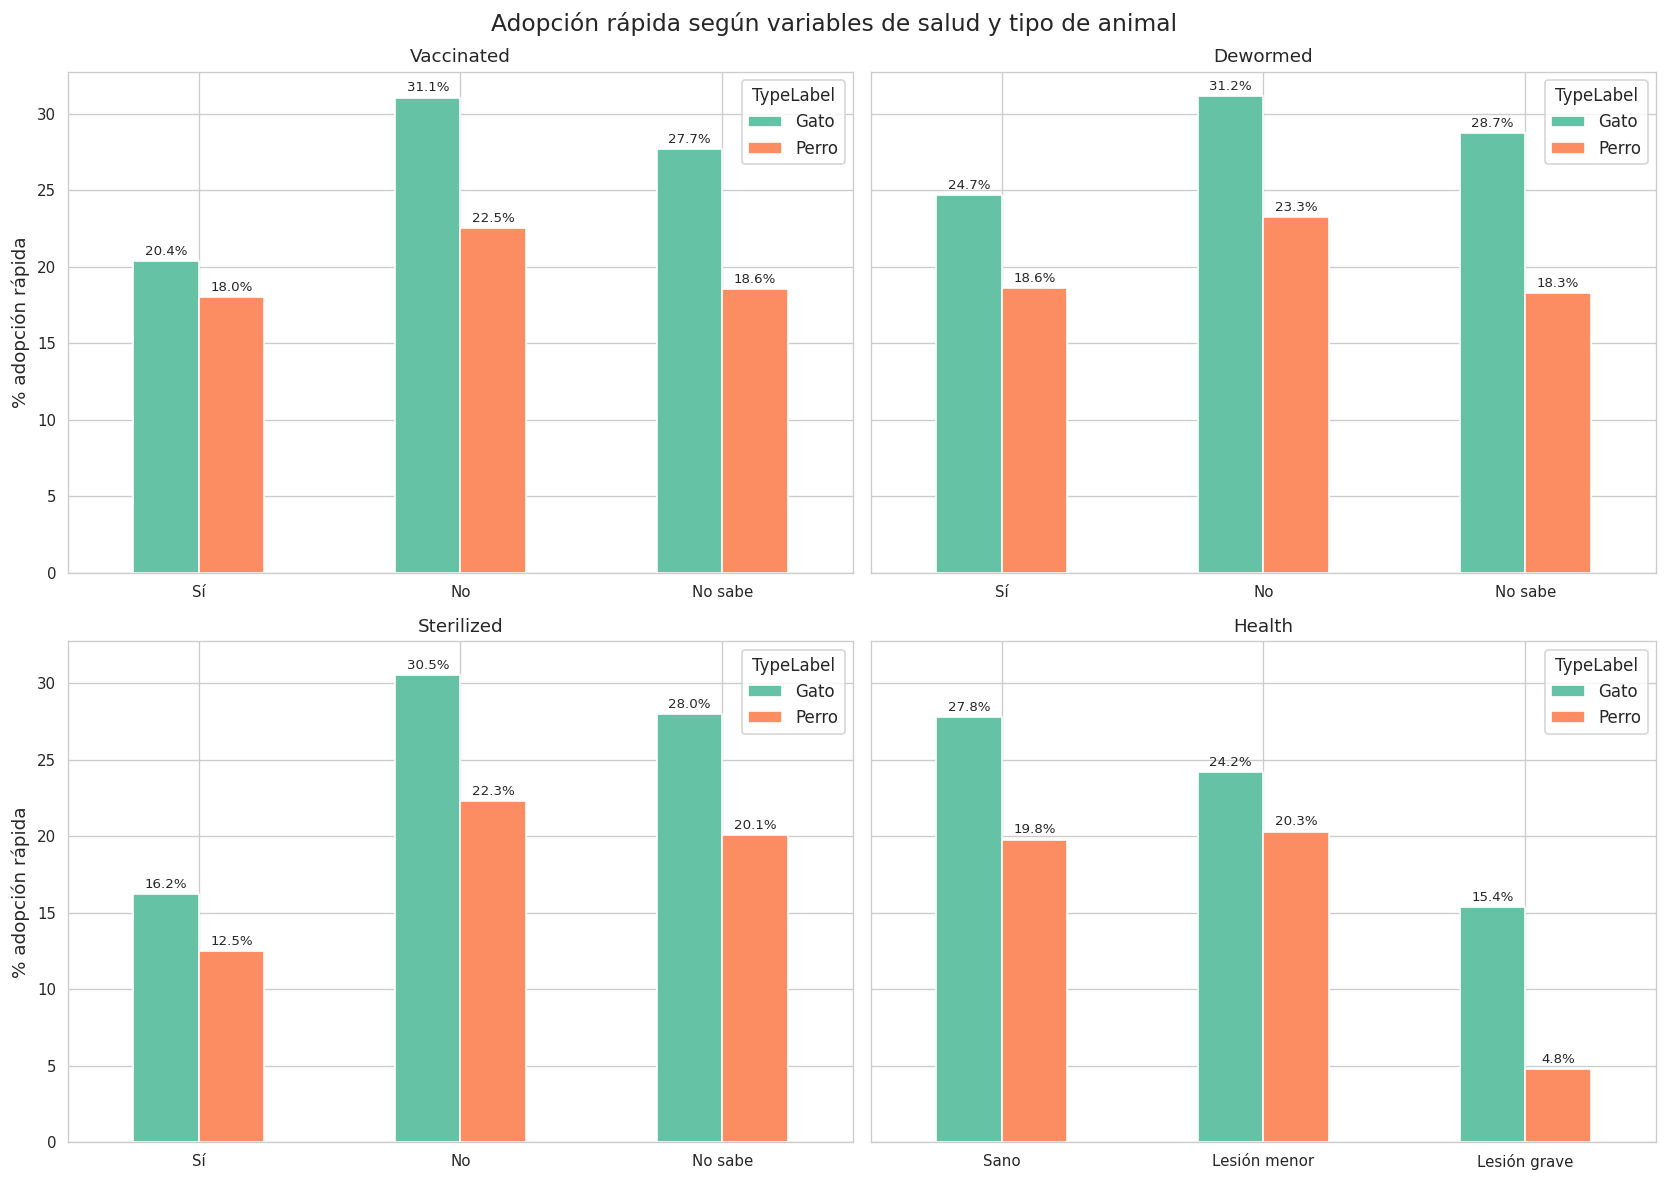

In [53]:
import matplotlib.pyplot as plt

# Variable binaria
df['AdoptFast'] = df['AdoptionSpeed'].isin([0, 1]).astype(int)

# Recodificación
health_vars = {
    'Vaccinated': {1: 'Sí', 2: 'No', 3: 'No sabe'},  # 1=Yes, 2=No, 3=Not Sure
    'Dewormed':   {1: 'Sí', 2: 'No', 3: 'No sabe'},
    'Sterilized': {1: 'Sí', 2: 'No', 3: 'No sabe'},
    'Health':     {1: 'Sano', 2: 'Lesión menor', 3: 'Lesión grave'}
}

# 👉 Grid 2x2
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
axes = axes.flatten()  # para iterar fácil

for i, (var, mapping) in enumerate(health_vars.items()):
    
    label_col = var + 'Label'
    
    if pd.api.types.is_numeric_dtype(df[var]):
        df[label_col] = df[var].map(mapping)
    else:
        df[label_col] = df[var].astype(str).str.strip()
    
    plot_df = (
        df[['TypeLabel', label_col, 'AdoptFast']]
        .dropna()
        .groupby([label_col, 'TypeLabel'], as_index=False)['AdoptFast']
        .mean()
    )
    
    plot_df['AdoptFast'] *= 100
    
    pivot_df = plot_df.pivot(index=label_col, columns='TypeLabel', values='AdoptFast')
    
    # Orden lógico
    if var in ['Vaccinated', 'Dewormed', 'Sterilized']:
        pivot_df = pivot_df.reindex(['Sí', 'No', 'No sabe'])
    else:
        pivot_df = pivot_df.reindex(['Sano', 'Lesión menor', 'Lesión grave'])
    
    ax = axes[i]
    pivot_df.plot(kind='bar', ax=ax, edgecolor='white')
    
    ax.set_title(var, fontsize=11)
    ax.set_xlabel('')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    
    # Solo primera columna con eje Y
    if i % 2 == 0:
        ax.set_ylabel('% adopción rápida')
    else:
        ax.set_ylabel('')
    
    # Etiquetas
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', padding=2, fontsize=8)

# 👉 Título general
plt.suptitle('Adopción rápida según variables de salud y tipo de animal', fontsize=14)

plt.tight_layout()
plt.show()

Si bien los patrones generales se mantienen (por ejemplo, menor adopción en animales con peor salud), la magnitud del efecto varía entre gatos y perros, siendo más pronunciada en estos últimos. Por ejemplo, el impacto de lesión grave es mucho más fuerte en perros.

### 5.4 Tipo × Fee × AdoptionSpeed

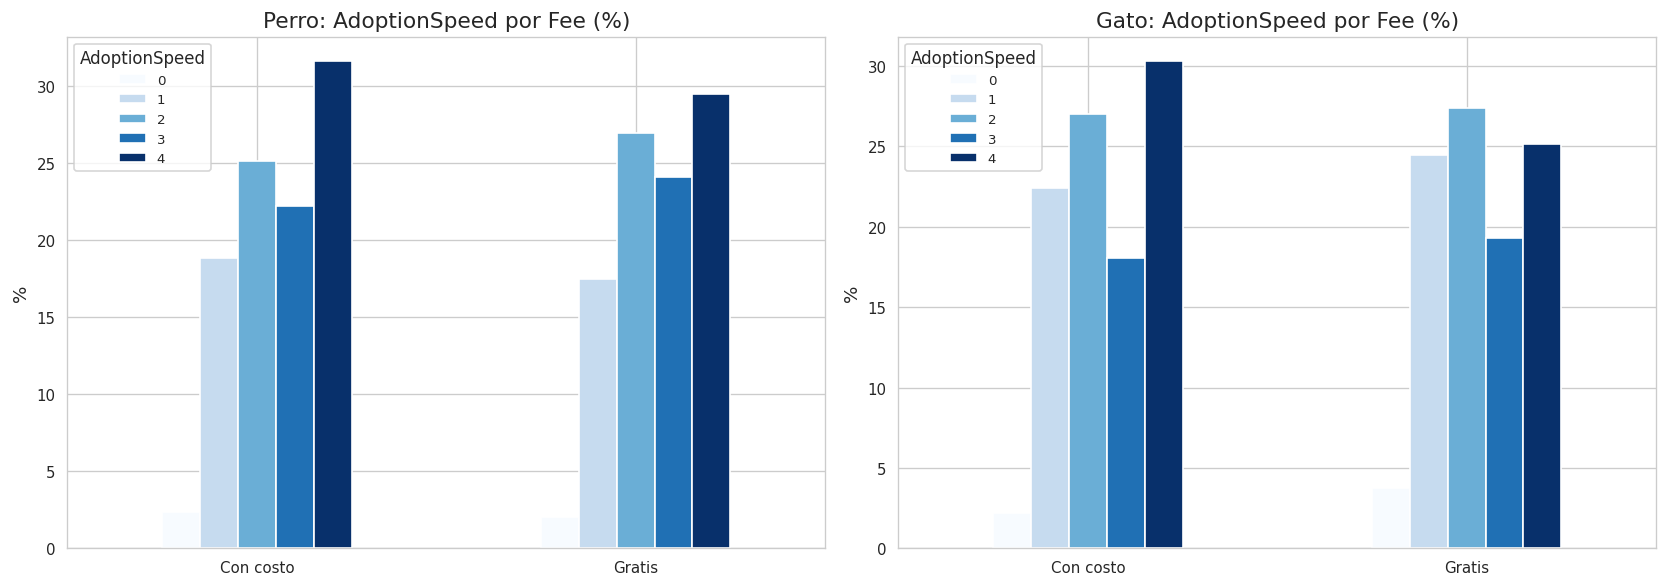

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, tipo in zip(axes, ['Perro', 'Gato']):
    subset = df[df['TypeLabel'] == tipo]
    cross = subset.groupby(['IsFree', 'AdoptionSpeed']).size().unstack(fill_value=0)
    cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100
    cross_pct.index = ['Con costo', 'Gratis']
    cross_pct.plot(kind='bar', ax=ax, colormap='Blues', edgecolor='white')
    ax.set_title(f'{tipo}: AdoptionSpeed por Fee (%)')
    ax.tick_params(axis='x', rotation=0)
    ax.set_ylabel('%')
    ax.legend(title='AdoptionSpeed', fontsize=8)

plt.tight_layout()
plt.show()

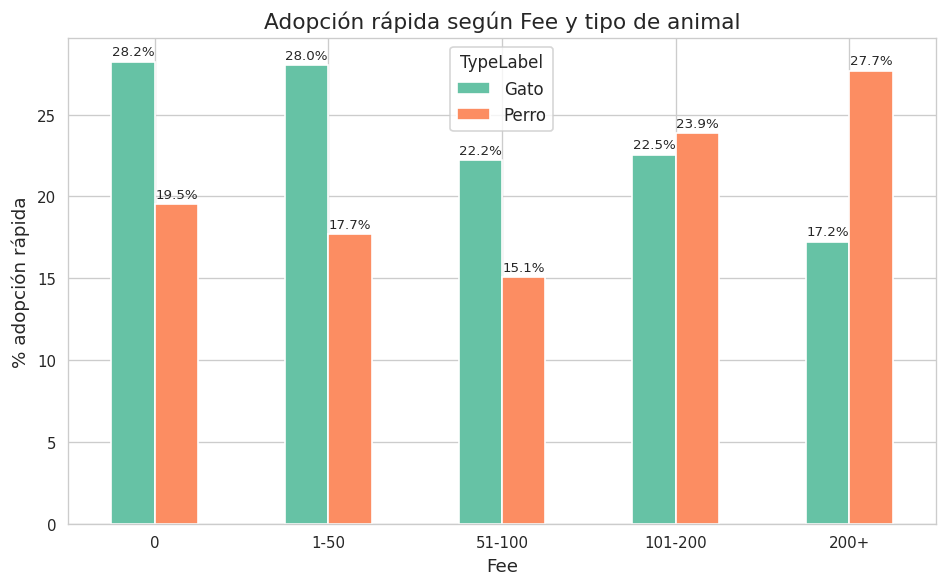

In [55]:
# Variable binaria
df['AdoptFast'] = df['AdoptionSpeed'].isin([0, 1]).astype(int)

# Crear categorías de Fee
df['FeeGroup'] = pd.cut(
    df['Fee'],
    bins=[-1, 0, 50, 100, 200, df['Fee'].max()],
    labels=['0', '1-50', '51-100', '101-200', '200+']
)

# Calcular % de adopción rápida
plot_df = (
    df[['FeeGroup', 'TypeLabel', 'AdoptFast']]
    .dropna()
    .groupby(['FeeGroup', 'TypeLabel'], as_index=False)['AdoptFast']
    .mean()
)

plot_df['AdoptFast'] *= 100

pivot_df = plot_df.pivot(index='FeeGroup', columns='TypeLabel', values='AdoptFast')

# Gráfico
ax = pivot_df.plot(kind='bar', figsize=(8, 5), edgecolor='white')

ax.set_title('Adopción rápida según Fee y tipo de animal')
ax.set_xlabel('Fee')
ax.set_ylabel('% adopción rápida')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=2, fontsize=8)

plt.tight_layout()
plt.show()

En el caso de los gatos, sucede que a medida que aumenta el valor de la adopción, disminuyen las adopciones. Sin embargos, en los perros se observa incluso mayores niveles de adopción rápida en los rangos de fee más altos. Esto podría estar relacionado con otras características del animal, como la raza. 

### 5.5 Fotos × Tipo × AdoptionSpeed

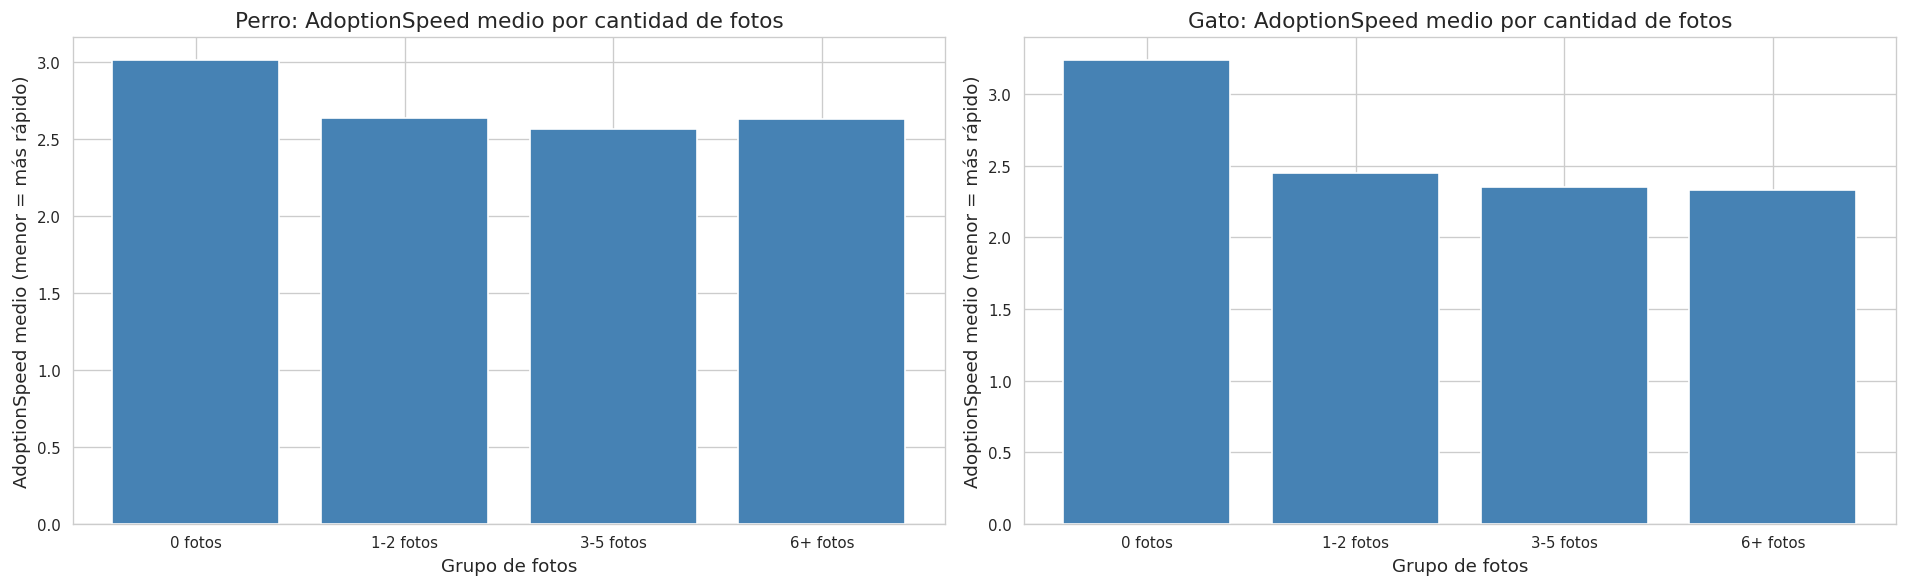

In [56]:
# Categorizar cantidad de fotos
df['PhotoGroup'] = pd.cut(df['PhotoAmt'].fillna(0),
                           bins=[-1, 0, 2, 5, 100],
                           labels=['0 fotos', '1-2 fotos', '3-5 fotos', '6+ fotos'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, tipo in zip(axes, ['Perro', 'Gato']):
    subset = df[df['TypeLabel'] == tipo]
    pivot = subset.groupby('PhotoGroup')['AdoptionSpeed'].mean().reset_index()
    ax.bar(pivot['PhotoGroup'].astype(str), pivot['AdoptionSpeed'], color='steelblue')
    ax.set_title(f'{tipo}: AdoptionSpeed medio por cantidad de fotos')
    ax.set_xlabel('Grupo de fotos')
    ax.set_ylabel('AdoptionSpeed medio (menor = más rápido)')

plt.tight_layout()
plt.show()

### 5.6 Pairplot: variables numéricas clave

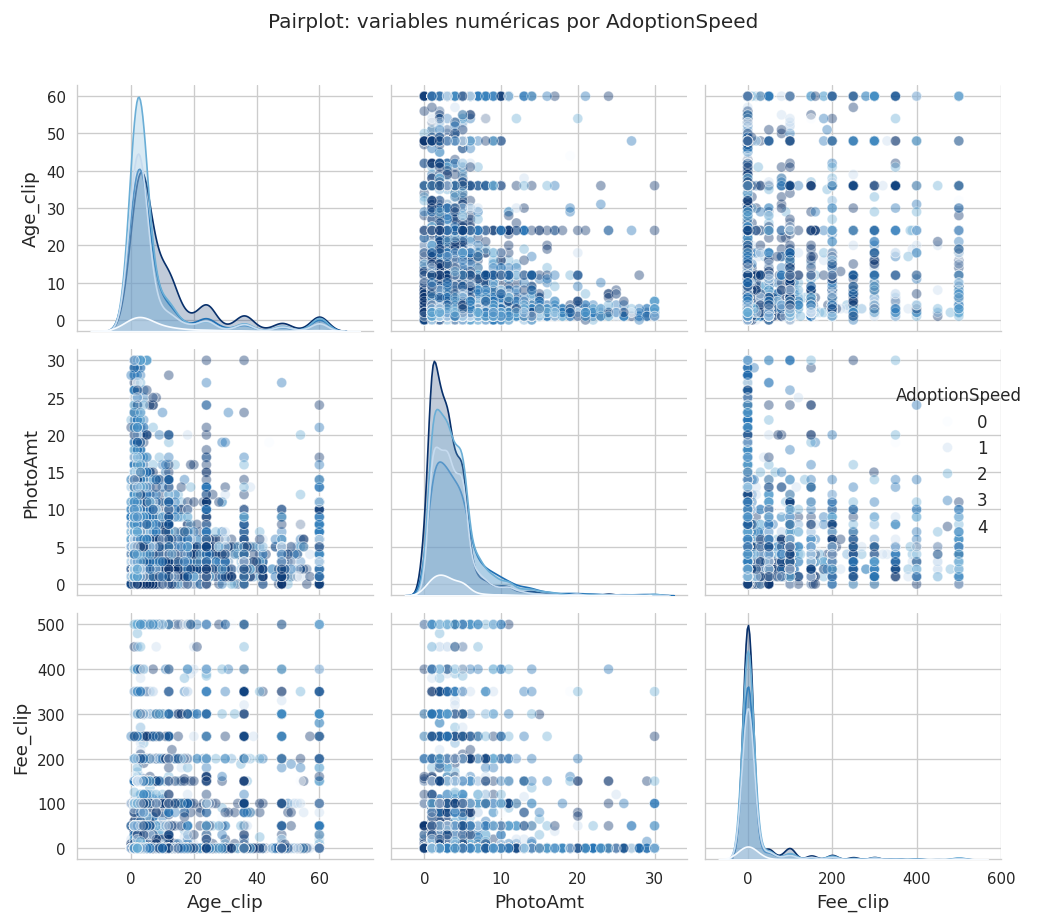

In [57]:
pair_cols = ['Age', 'PhotoAmt', 'Fee', 'AdoptionSpeed']
pair_df = df[pair_cols].copy()
pair_df['PhotoAmt'] = pair_df['PhotoAmt'].fillna(0)
pair_df['Fee_clip'] = pair_df['Fee'].clip(upper=500)
pair_df['Age_clip'] = pair_df['Age'].clip(upper=60)

g = sns.pairplot(pair_df[['Age_clip', 'PhotoAmt', 'Fee_clip', 'AdoptionSpeed']],
                 hue='AdoptionSpeed', palette='Blues', plot_kws={'alpha': 0.4},
                 diag_kind='kde')
g.fig.suptitle('Pairplot: variables numéricas por AdoptionSpeed', y=1.02)
plt.tight_layout()
plt.show()

### 5.7 Heatmap: tasa de adopción rápida por Estado y Tipo

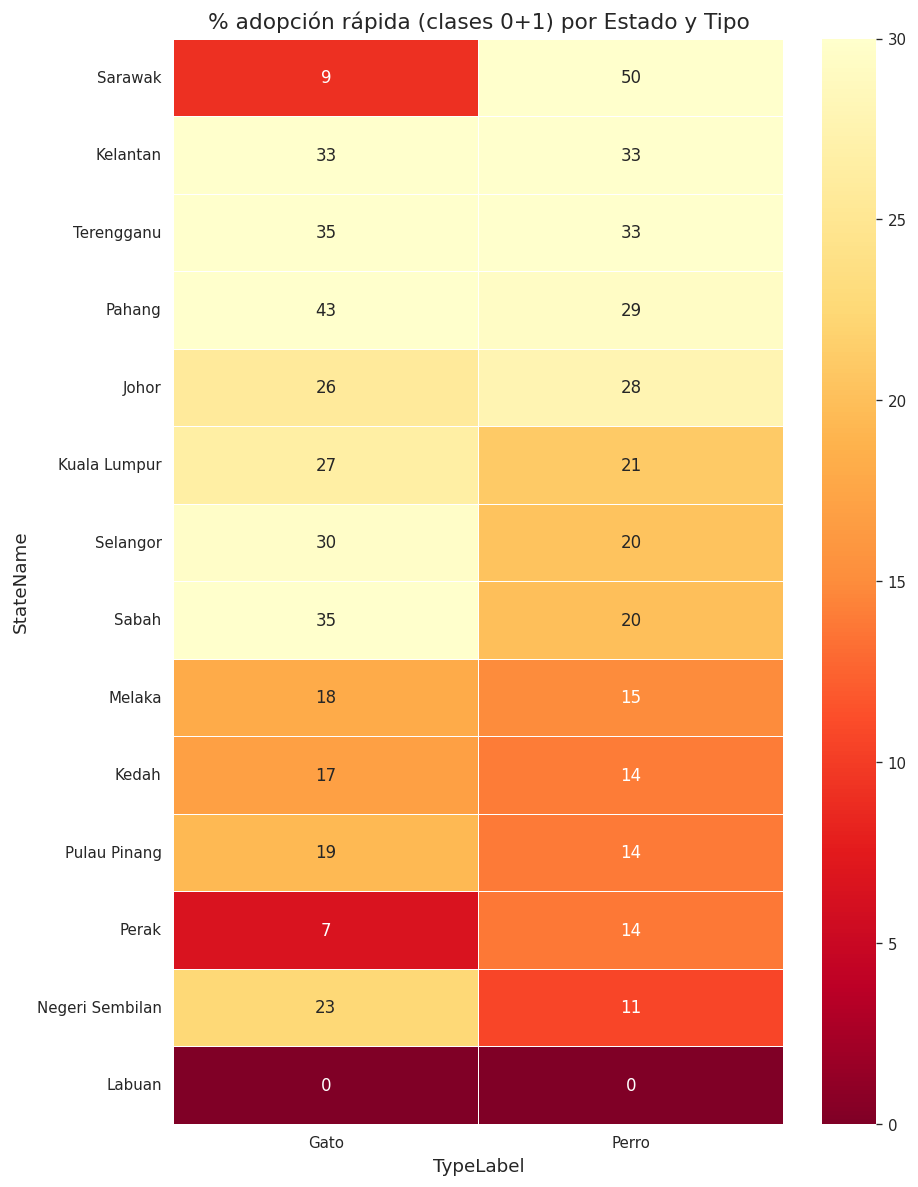

In [58]:
pivot_state = df.groupby(['StateName', 'TypeLabel'])['AdoptionSpeed'].apply(
    lambda x: (x.isin([0, 1])).mean() * 100
).unstack()

plt.figure(figsize=(8, 10))
sns.heatmap(pivot_state.sort_values('Perro', ascending=False),
            annot=True, fmt='.0f', cmap='YlOrRd_r',
            linewidths=0.5, vmin=0, vmax=30)
plt.title('% adopción rápida (clases 0+1) por Estado y Tipo')
plt.tight_layout()
plt.show()

### 5.8 Estado de salud × Edad × Adopción rápida

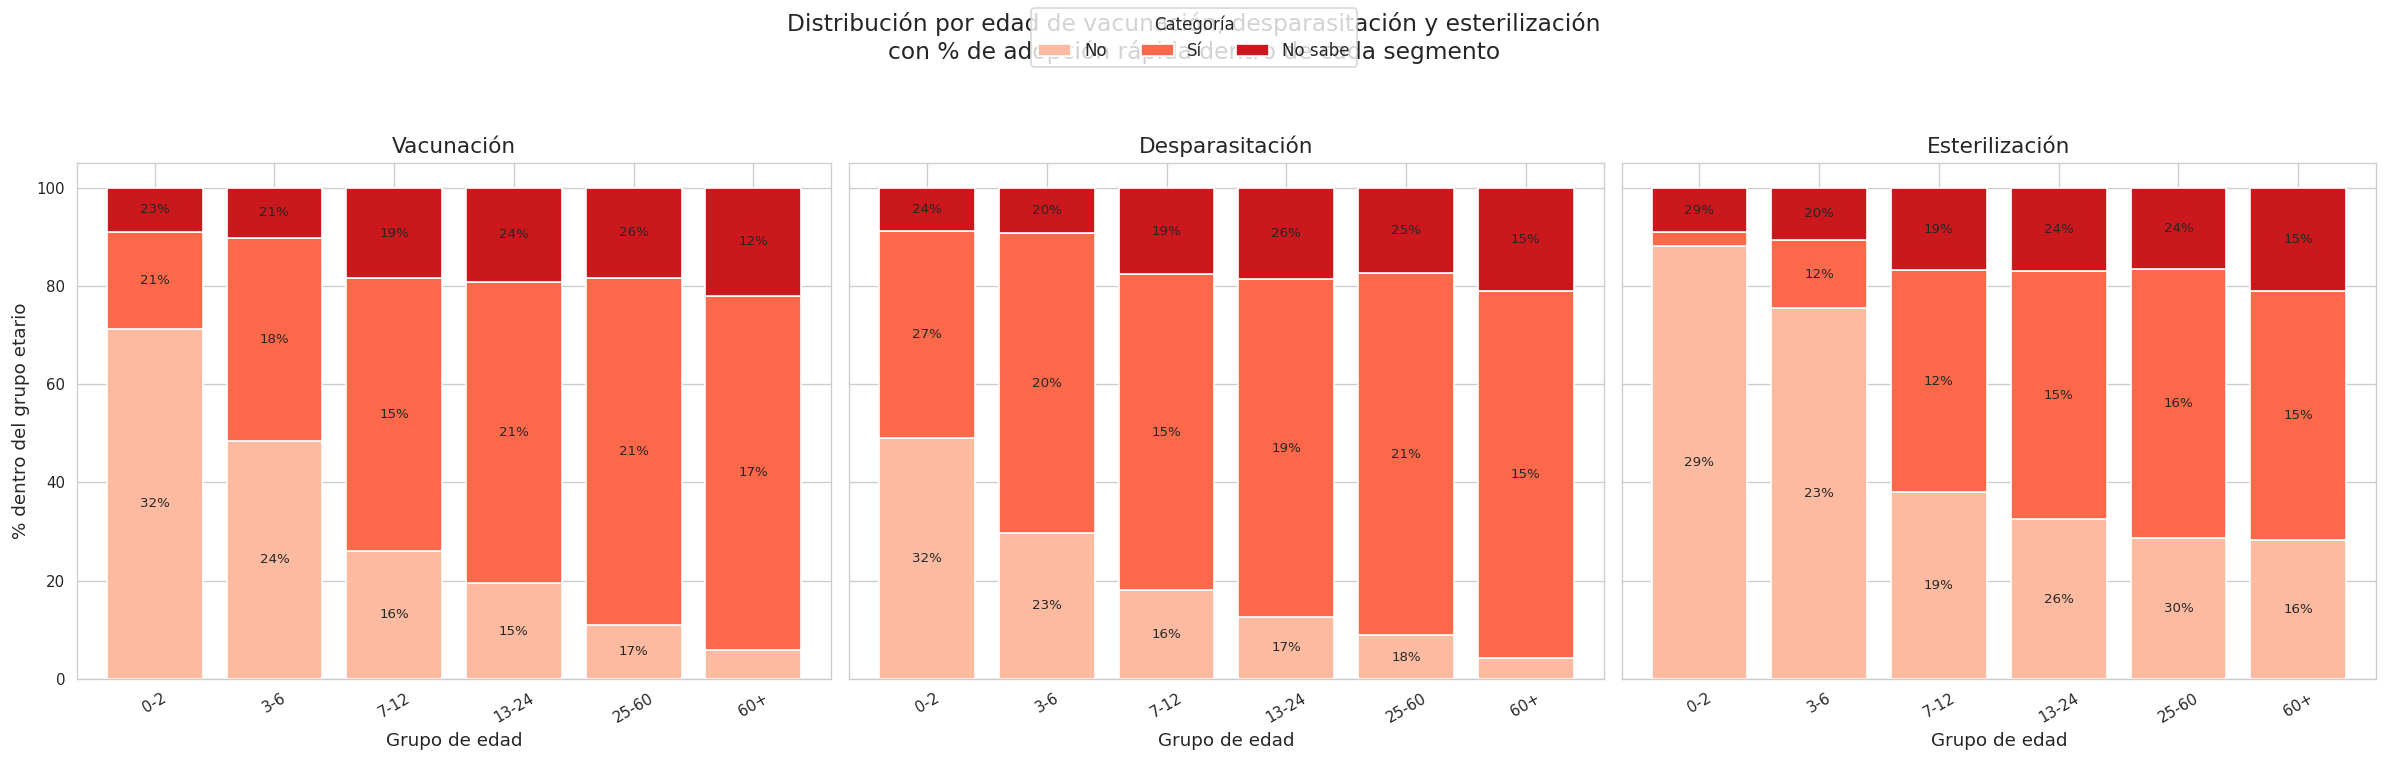

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_plot = df.copy()

# adopción rápida
df_plot["AdoptFast"] = df_plot["AdoptionSpeed"].isin([0, 1]).astype(int)

# grupos de edad
bins = [-1, 2, 6, 12, 24, 60, 300]
labels = ["0-2", "3-6", "7-12", "13-24", "25-60", "60+"]
df_plot["AgeGroup"] = pd.cut(df_plot["Age"], bins=bins, labels=labels)

# usar columnas originales
vars_plot = {
    "VaccinatedLabel": "Vacunación",
    "DewormedLabel": "Desparasitación",
    "SterilizedLabel": "Esterilización"
}

order_cat = ["No", "Sí", "No sabe"]
palette = sns.color_palette("Reds", n_colors=3)

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

for ax, (var, title) in zip(axes, vars_plot.items()):

    # quedarnos solo con categorías válidas
    subset = df_plot[df_plot[var].isin(order_cat)].copy()

    # composición dentro de cada grupo etario
    tab = pd.crosstab(
        subset["AgeGroup"],
        subset[var],
        normalize="index"
    ) * 100

    tab = tab.reindex(index=labels, columns=order_cat)

    # eliminar grupos vacíos para evitar el error
    tab = tab.dropna(how="all")

    if tab.empty:
        ax.set_title(title)
        ax.text(0.5, 0.5, "Sin datos", ha="center", va="center")
        ax.axis("off")
        continue

    tab.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        color=palette,
        edgecolor="white",
        width=0.8
    )

    # % adopción rápida por grupo etario y categoría
    adopt_tab = (
        subset.groupby(["AgeGroup", var], observed=False)["AdoptFast"]
        .mean()
        .mul(100)
        .reset_index()
    )

    # etiquetas dentro de cada segmento
    cumulative = pd.Series(0, index=tab.index)

    for cat in order_cat:
        if cat not in tab.columns:
            continue

        vals = tab[cat].fillna(0)

        for i, age_group in enumerate(tab.index):
            height = vals.loc[age_group]
            if height < 8:
                continue

            rate_row = adopt_tab[
                (adopt_tab["AgeGroup"] == age_group) &
                (adopt_tab[var] == cat)
            ]

            if not rate_row.empty:
                rate = rate_row["AdoptFast"].values[0]
                y = cumulative.loc[age_group] + height / 2
                ax.text(
                    i, y,
                    f"{rate:.0f}%",
                    ha="center", va="center",
                    fontsize=8
                )

        cumulative += vals

    ax.set_title(title)
    ax.set_xlabel("Grupo de edad")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30)

    if ax == axes[0]:
        ax.set_ylabel("% dentro del grupo etario")
    else:
        ax.set_ylabel("")

    if ax.legend_ is not None:
        ax.legend_.remove()

handles, labels_leg = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_leg, title="Categoría", loc="upper center", ncol=3)

plt.suptitle(
    "Distribución por edad de vacunación, desparasitación y esterilización\ncon % de adopción rápida dentro de cada segmento",
    fontsize=14,
    y=1.05
)

plt.tight_layout()
plt.show()

Se observa que la proporción de animales vacunados, desparasitados y esterilizados aumenta sistemáticamente con la edad. Dado que la edad también se asocia con la probabilidad de adopción rápida, estas variables podrían estar funcionando como indicadores indirectos de la edad, actuando como variables de confusión en el análisis de adopción.

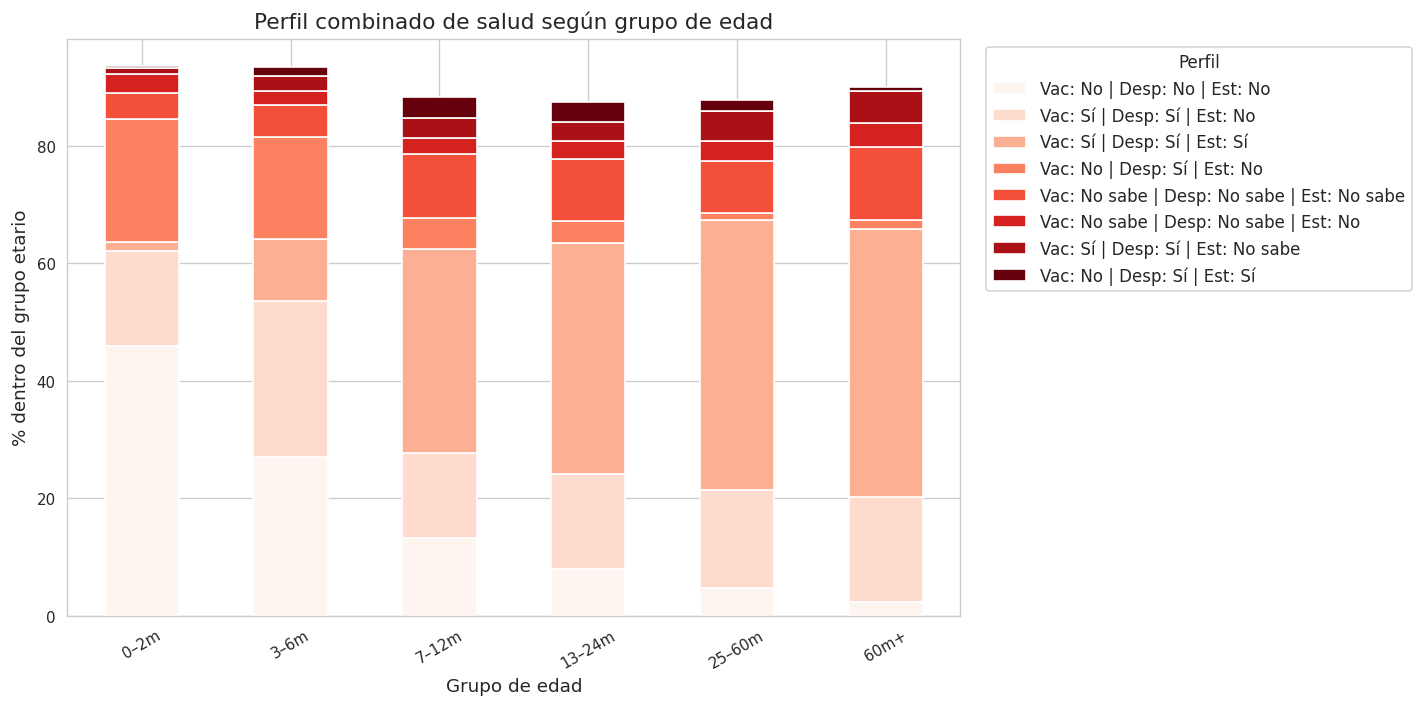

In [60]:
df_plot = df.copy()

# adopción rápida
df_plot["AdoptFast"] = df_plot["AdoptionSpeed"].isin([0, 1]).astype(int)

# asegurarnos de trabajar solo con categorías interpretables
order_cat = ["No", "Sí", "No sabe"]

subset = df_plot[
    df_plot["VaccinatedLabel"].isin(order_cat) &
    df_plot["DewormedLabel"].isin(order_cat) &
    df_plot["SterilizedLabel"].isin(order_cat)
].copy()

# variable combinada
subset["HealthProfile"] = (
    "Vac: " + subset["VaccinatedLabel"] +
    " | Desp: " + subset["DewormedLabel"] +
    " | Est: " + subset["SterilizedLabel"]
)

tab = pd.crosstab(
    subset["AgeGroup"],
    subset["HealthProfile"],
    normalize="index"
) * 100

# quedarnos con los perfiles más frecuentes para no saturar
top_profiles = subset["HealthProfile"].value_counts().head(8).index
tab = tab[top_profiles]

fig, ax = plt.subplots(figsize=(12, 6))
tab.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    colormap="Reds",
    edgecolor="white"
)

ax.set_title("Perfil combinado de salud según grupo de edad")
ax.set_xlabel("Grupo de edad")
ax.set_ylabel("% dentro del grupo etario")
ax.tick_params(axis="x", rotation=30)
ax.legend(title="Perfil", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

Se observa una asociación entre el grupo etario y el estado sanitario de los animales. 
* En los grupos más jóvenes predominan perfiles con ausencia de cualquier intervenciones (> 40) o de una o dos de ellas.
* A medida que aumenta la edad crece la proporción de animales vacunados, desparasitados y esterilizados.

In [61]:
from scipy.stats import chi2_contingency

samples = []

for _, group in subset.groupby("AgeGroup", observed=False):
    samples.append(group.sample(n=min(len(group), 1000), random_state=42))

sample = pd.concat(samples).reset_index(drop=True)

table = pd.crosstab(sample["AgeGroup"], sample["HealthProfile"])
chi2, p, dof, expected = chi2_contingency(table)

n = table.to_numpy().sum()
cramer_v = np.sqrt(chi2 / (n * (min(table.shape) - 1)))

print(f"Chi2 = {chi2:.2f}")
print(f"p-value = {p:.4e}")
print(f"Cramér's V = {cramer_v:.3f}")

Chi2 = 2057.06
p-value = 0.0000e+00
Cramér's V = 0.276


Existe una asociación estadísticamente significativa entre el grupo etario y el perfil combinado de salud.

### 5.9 Edad × Fee × AdoptionSpeed

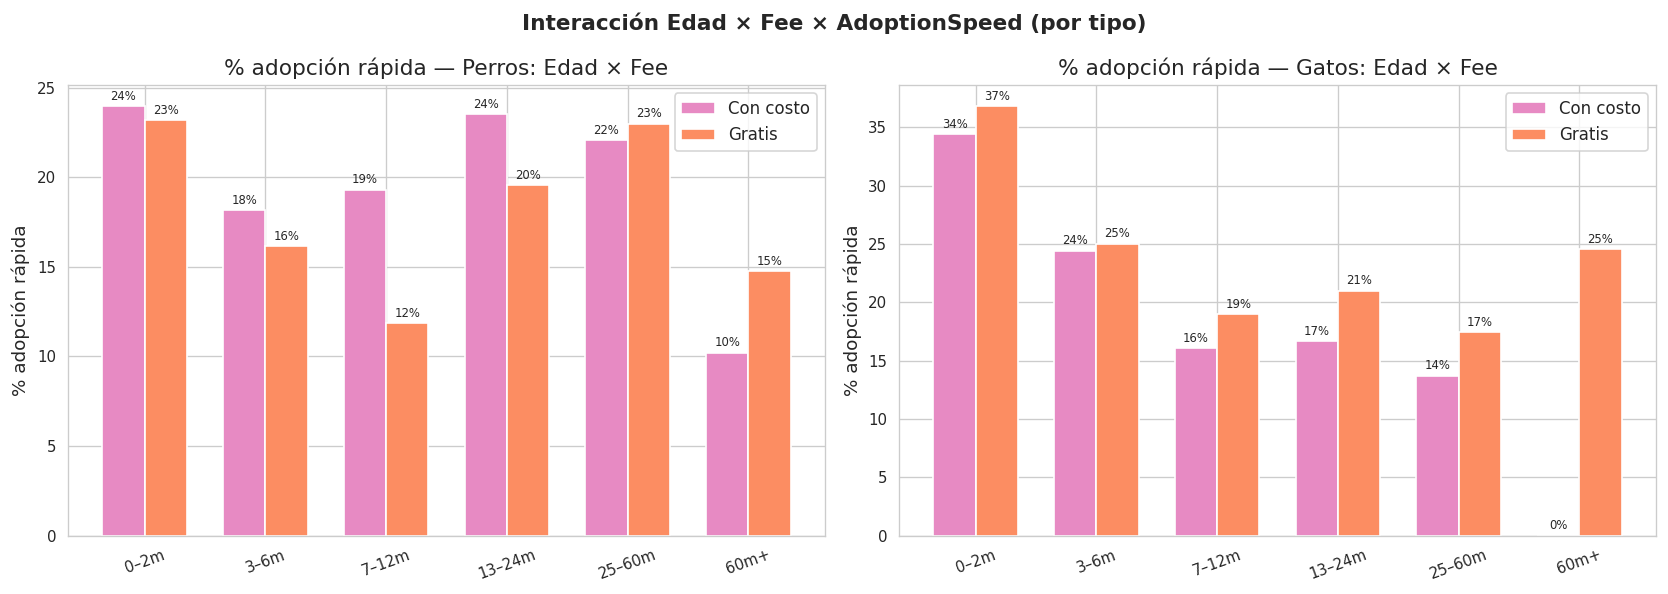

In [62]:
# ¿Los cachorros gratuitos se adoptan casi instantáneamente?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, type_val, label in zip(axes, [1, 2], ['Perros', 'Gatos']):
    subset = df[df['Type'] == type_val].copy()
    pivot = (subset.groupby(['AgeGroup', 'IsFree'], observed=True)['AdoptFast']
             .mean() * 100).unstack()
    pivot.columns = ['Con costo', 'Gratis']
    
    x = np.arange(len(pivot.index))
    width = 0.35
    bars1 = ax.bar(x - width/2, pivot['Con costo'], width, label='Con costo', 
                   color=PALETTE[3], edgecolor='white')
    bars2 = ax.bar(x + width/2, pivot['Gratis'], width, label='Gratis', 
                   color=PALETTE[1], edgecolor='white')
    
    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index.astype(str), rotation=20)
    ax.set_title(f'% adopción rápida — {label}: Edad × Fee')
    ax.set_ylabel('% adopción rápida')
    ax.legend()
    ax.bar_label(bars1, fmt='%.0f%%', padding=2, fontsize=7)
    ax.bar_label(bars2, fmt='%.0f%%', padding=2, fontsize=7)

plt.suptitle('Interacción Edad × Fee × AdoptionSpeed (por tipo)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 6. Ranking de variables por asociación con AdoptionSpeed

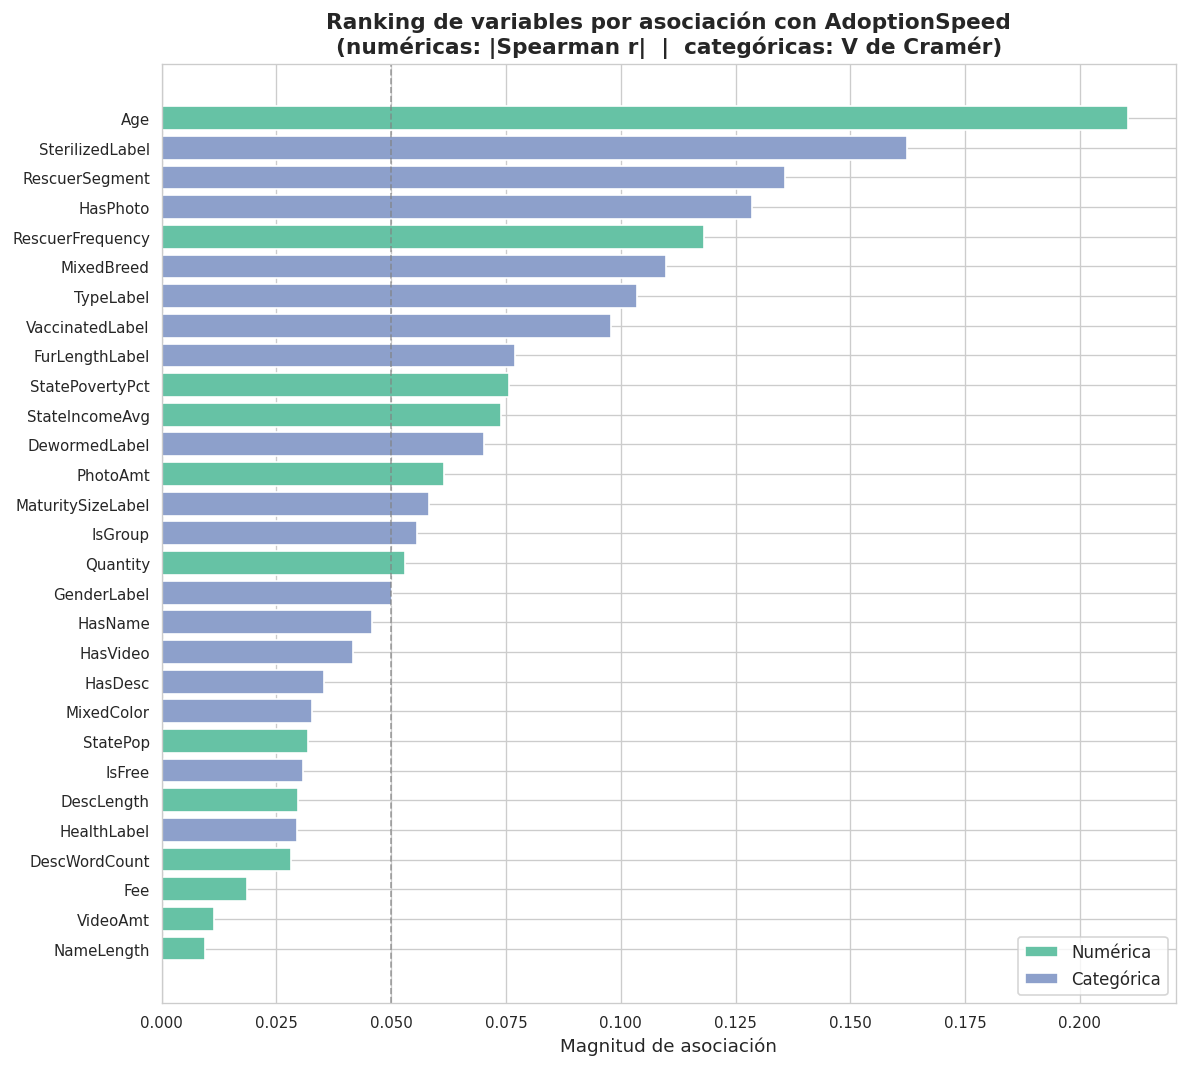

         Variable       Tipo      Métrica  Valor   p-value
              Age   Numérica Spearman |r| 0.2104 3.19e-149
  SterilizedLabel Categórica  V de Cramér 0.1624 7.45e-165
   RescuerSegment Categórica  V de Cramér 0.1357 2.49e-224
         HasPhoto Categórica  V de Cramér 0.1285  3.01e-52
 RescuerFrequency   Numérica Spearman |r| 0.1182  1.24e-47
       MixedBreed Categórica  V de Cramér 0.1098  6.21e-38
        TypeLabel Categórica  V de Cramér 0.1035  1.32e-33
  VaccinatedLabel Categórica  V de Cramér 0.0979  2.81e-57
   FurLengthLabel Categórica  V de Cramér 0.0770  3.80e-34
  StatePovertyPct   Numérica Spearman |r| 0.0756  2.12e-20
   StateIncomeAvg   Numérica Spearman |r| 0.0739  1.39e-19
    DewormedLabel Categórica  V de Cramér 0.0703  5.98e-28
         PhotoAmt   Numérica Spearman |r| 0.0616  4.55e-14
MaturitySizeLabel Categórica  V de Cramér 0.0582  2.09e-26
          IsGroup Categórica  V de Cramér 0.0556  2.14e-09
         Quantity   Numérica Spearman |r| 0.0530  9.03e-

In [63]:
from scipy.stats import spearmanr, chi2_contingency
import warnings
warnings.filterwarnings('ignore')

ranking = []

# ── Numéricas: correlación de Spearman ────────────────────────────────────────
num_vars = ['Age', 'Quantity', 'Fee', 'VideoAmt', 'PhotoAmt',
            'NameLength', 'DescLength', 'DescWordCount', 'RescuerFrequency',
            'StatePop', 'StatePovertyPct', 'StateIncomeAvg']

for col in num_vars:
    sub = df[[col, 'AdoptionSpeed']].dropna()
    r, p = spearmanr(sub[col], sub['AdoptionSpeed'])
    ranking.append({
        'Variable': col,
        'Tipo': 'Numérica',
        'Métrica': 'Spearman |r|',
        'Valor': abs(r),
        'p-value': p
    })

# ── Categóricas: V de Cramér ──────────────────────────────────────────────────
cat_vars = ['TypeLabel', 'GenderLabel', 'MaturitySizeLabel', 'FurLengthLabel',
            'VaccinatedLabel', 'DewormedLabel', 'SterilizedLabel', 'HealthLabel',
            'HasName', 'HasDesc', 'HasPhoto', 'HasVideo', 'IsFree',
            'MixedColor', 'MixedBreed', 'IsGroup', 'RescuerSegment']

for col in cat_vars:
    if col not in df.columns:
        continue
    tmp = df[[col, 'AdoptionSpeed']].dropna()
    if tmp[col].nunique() < 2:
        continue
    table = pd.crosstab(tmp[col], tmp['AdoptionSpeed'])
    chi2, p, dof, _ = chi2_contingency(table)
    n = table.sum().sum()
    r, k = table.shape
    v = np.sqrt(chi2 / (n * (min(r-1, k-1))))
    ranking.append({
        'Variable': col,
        'Tipo': 'Categórica',
        'Métrica': "V de Cramér",
        'Valor': v,
        'p-value': p
    })

rank_df = pd.DataFrame(ranking).sort_values('Valor', ascending=False).reset_index(drop=True)
rank_df['Valor'] = rank_df['Valor'].round(4)
rank_df['p-value'] = rank_df['p-value'].apply(lambda x: f'{x:.2e}')

# ── Gráfico ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 9))
colors_bar = [PALETTE[0] if t == 'Numérica' else PALETTE[2] for t in rank_df['Tipo']]
bars = ax.barh(rank_df['Variable'][::-1], rank_df['Valor'][::-1],
               color=colors_bar[::-1], edgecolor='white')
ax.set_title('Ranking de variables por asociación con AdoptionSpeed\n'
             '(numéricas: |Spearman r|  |  categóricas: V de Cramér)',
             fontweight='bold')
ax.set_xlabel('Magnitud de asociación')
ax.axvline(0.05, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='ref: 0.05')
ax.legend()

# Leyenda de color
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=PALETTE[0], label='Numérica'),
                   Patch(facecolor=PALETTE[2], label='Categórica')]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

print(rank_df.to_string(index=False))


**Lectura del ranking:** Las métricas no son directamente comparables entre sí (|r| de Spearman vs. V de Cramér), pero permiten priorizar variables dentro de cada tipo. Las variables con V de Cramér o |r| > 0.10 son las más candidatas a feature engineering activo.

---
## 5. Conclusiones preliminares

### Hallazgos principales

**Sobre el target:**
- Las clases 2 y 3 (adopción en 1er mes o en 2do-3er mes) son las más frecuentes. La distribución no es uniforme.
- Solo una pequeña proporción se adopta el mismo día (clase 0).

**Variables más relevantes para el modelo:**
- **Tipo**: introduce diferencias en la adopción. Los gatos tienden a adoptarse más rápido que los perros. Pueden evaluarse interacciones (especialmente con Fee y Edad).
- **Edad**: es una de las variables influyentes en la adopción: los animales más jóvenes presentan mayor probabilidad de adopción rápida. Puede modelarse como continua, aunque su distribución sesgada sugiere evaluar transformaciones o discretización.
- **Fotos**: la presencia y cantidad de fotos se asocia positivamente con la adopción rápida, posiblemente reflejando mayor visibilidad o calidad de publicación. Puede capturar comportamiento del rescatista más que del animal.
- **Fee**: el efecto del costo no es homogéneo. En gatos, a mayor costo, menor adopción. En perros, fees altos pueden asociarse a mayor adopción. Esto sugiere que el fee actúa como proxy de características del animal (raza, edad).
- **Vacunación / Esterilización / Desparasitación**: variables están fuertemente asociadas con la edad (los animales más jóvenes tienden a no haber recibido estos cuidados). Su relación con la adopción puede ser espuria si no se ajusta por edad. 
- **Estado de salud**: presenta una relación consistente con la adopción: animales con problemas graves muestran menor probabilidad de adopción rápida.
- **Nombre**: se observa una asociación leve con la adopción, posiblemente vinculada a una mayor “humanización” del animal o mejor presentación.
- **Estado geográfico**: existen diferencias regionales relevantes en la velocidad de adopción, lo que sugiere heterogeneidad en la oferta/demanda o en las dinámicas locales.